<a href="https://colab.research.google.com/github/Masiania-bit/Maria-palander/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV о вулканах

**Что делаем:**

- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `data/volcano.csv` (2388 записей о вулканах)
- Переименовываем технические столбцы с URL Wikidata (volcano, country, mountainRange) в `*_url` (сохраняем для отладки)
- Переименовываем читаемые столбцы с постфиксом `Label` (volcanoLabel → volcano, countryLabel → country, mountainRangeLabel → mountainRange)
- Приводим числовое поле `elevation` к целочисленному типу `int`, заменяя пропуски на 0

**Результат:** чистая таблица `df` с полями:

- `volcano_url` — ссылка на объект Wikidata (для отладки)
- `country_url` — ссылка на страну в Wikidata
- `mountainRange_url` — ссылка на горную цепь в Wikidata
- `volcano` — название вулкана
- `elevation` — высота вулкана (метры)
- `country` — страна (если указана)
- `mountainRange` — горная цепь (если указана)
- `coord` — координаты в формате Wikidata (требует дополнительной обработки)

In [35]:
# 📥 [0] Клонирование репозитория и загрузка данных о вулканах

import os
import pandas as pd
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "MAsiania-bit"
repo = "Maria-palander"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с вулканами
df = pd.read_csv("data/volcano.csv")
print(f"📊 Загружено строк в датасете: {len(df)}\n")

# Шаг 3: Очистка данных
# Технические столбцы с URL переименовываем, добавляя суффикс "_url"
rename_dict = {}
if "volcano" in df.columns:
    rename_dict["volcano"] = "volcano_url"
if "country" in df.columns:
    rename_dict["country"] = "country_url"
if "mountainRange" in df.columns:
    rename_dict["mountainRange"] = "mountainRange_url"
df = df.rename(columns=rename_dict)

# Столбцы с читаемыми названиями (Label) переименовываем в основные имена
rename_dict_label = {}
if "volcanoLabel" in df.columns:
    rename_dict_label["volcanoLabel"] = "volcano"
if "countryLabel" in df.columns:
    rename_dict_label["countryLabel"] = "country"
if "mountainRangeLabel" in df.columns:
    rename_dict_label["mountainRangeLabel"] = "mountainRange"
df = df.rename(columns=rename_dict_label)

# Приводим высоту к целочисленному типу (заменяем некорректные значения на 0)
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce").fillna(0).astype(int)

print("✅ Данные очищены\n")

# Шаг 4: Краткий обзор датасета
print("📋 Структура данных о вулканах:")
print(f"   Столбцы: {', '.join(df.columns)}")
if "volcano" in df.columns:
    print(f"   Количество вулканов: {df['volcano'].nunique()}")
if "country" in df.columns:
    print(f"   Уникальных стран: {df['country'].nunique()}")
if "mountainRange" in df.columns:
    print(f"   Уникальных горных цепей: {df['mountainRange'].nunique()}")
print(f"   Диапазон высот: {df['elevation'].min()} — {df['elevation'].max()} м")
print(f"   Средняя высота: {df['elevation'].mean():.1f} м\n")

# Дополнительная информация о подводных вулканах и аномалиях
submarine = df[df["elevation"] < 0]
if len(submarine) > 0:
    print(f"🌊 Подводных вулканов (высота < 0): {len(submarine)}")
    print(f"   Самая глубокая точка: {submarine['elevation'].min()} м\n")

extreme = df[df["elevation"] > 8000]
if len(extreme) > 0:
    print(f"🌋 Вулканов выше 8000 м (возможно, марсианские): {len(extreme)}")
    print(extreme[["volcano", "elevation", "country", "mountainRange"]].head())

print(f"\n🔍 Первые 5 строк:\n{df.head()}")

✅ Репозиторий готов

📊 Загружено строк в датасете: 2388

✅ Данные очищены

📋 Структура данных о вулканах:
   Столбцы: volcano_url, volcano, elevation, country_url, country, coord, mountainRange_url, mountainRange
   Количество вулканов: 2134
   Уникальных стран: 86
   Уникальных горных цепей: 135
   Диапазон высот: -1400 — 18225 м
   Средняя высота: 1089.1 м

🌊 Подводных вулканов (высота < 0): 5
   Самая глубокая точка: -1400 м

🌋 Вулканов выше 8000 м (возможно, марсианские): 5
           volcano  elevation country        mountainRange
0  Гора Аскрийская      18225     NaN                  NaN
1     Mount Tehama       9239     США  California Cascades
2    Hayes Volcano       9147     США  Tordrillo Mountains
3  Cerro Nicholson       8282    Перу                  NaN
4  Isanotski Peaks       8106     США     Алеутский хребет

🔍 Первые 5 строк:
                                volcano_url          volcano  elevation  \
0    http://www.wikidata.org/entity/Q499164  Гора Аскрийская      182

In [36]:
# 📥 [0] Клонирование репозитория и загрузка данных о вулканах

import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Шаг 1: Клонируем ваш репозиторий
github_user = "MAsiania-bit"
repo = "Maria-palander"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# ============================================
# ЧАСТЬ 1: ЗАГРУЗКА И ОЧИСТКА ВУЛКАНОВ
# ============================================

# Шаг 2: Загружаем CSV-файл с вулканами
df_volcano_raw = pd.read_csv("data/volcano.csv")
print(f"📊 Загружено строк в датасете вулканов: {len(df_volcano_raw)}")

# Шаг 3: Очистка данных о вулканах
# Переименовываем технические столбцы с URL
rename_dict = {}
if "volcano" in df_volcano_raw.columns:
    rename_dict["volcano"] = "volcano_url"
if "country" in df_volcano_raw.columns:
    rename_dict["country"] = "country_url"
if "mountainRange" in df_volcano_raw.columns:
    rename_dict["mountainRange"] = "mountainRange_url"
df_volcano_raw = df_volcano_raw.rename(columns=rename_dict)

# Переименовываем Label-столбцы в читаемые названия
rename_dict_label = {}
if "volcanoLabel" in df_volcano_raw.columns:
    rename_dict_label["volcanoLabel"] = "volcano"
if "countryLabel" in df_volcano_raw.columns:
    rename_dict_label["countryLabel"] = "country"
if "mountainRangeLabel" in df_volcano_raw.columns:
    rename_dict_label["mountainRangeLabel"] = "mountainRange"
df_volcano_raw = df_volcano_raw.rename(columns=rename_dict_label)

# Приводим высоту к числовому типу (оставляем NaN для пропусков)
df_volcano_raw["elevation"] = pd.to_numeric(df_volcano_raw["elevation"], errors="coerce")

# Извлечение координат
if "coord" in df_volcano_raw.columns:
    coords = df_volcano_raw["coord"].str.extract(r"Point\(([-\d.]+)\s+([-\d.]+)\)")
    df_volcano_raw["lon"] = pd.to_numeric(coords[0], errors="coerce")
    df_volcano_raw["lat"] = pd.to_numeric(coords[1], errors="coerce")

# Фильтрация марсианских объектов
df_volcano_raw["is_mars"] = (
    df_volcano_raw["coord"].str.contains("Q111", na=False) |
    (df_volcano_raw["lon"] > 180) |
    (df_volcano_raw["elevation"] > 7000)
)

# Создаём датафреймы для анализа
df_earth = df_volcano_raw[~df_volcano_raw["is_mars"]].copy()
df_earth_with_elev = df_earth[df_earth["elevation"].notna()].copy()

# Классификация высотных поясов
def classify_elevation(height):
    if pd.isna(height):
        return "нет данных"
    elif height < 0:
        return "подводные (< 0 м)"
    elif height < 1000:
        return "низкие (0–1000 м)"
    elif height < 3000:
        return "средние (1000–3000 м)"
    elif height < 6000:
        return "высокие (3000–6000 м)"
    else:
        return "экстремальные (> 6000 м)"

df_earth_with_elev["height_belt"] = df_earth_with_elev["elevation"].apply(classify_elevation)

print(f"\n🌍 Результат фильтрации вулканов:")
print(f"   • Всего объектов: {len(df_volcano_raw)}")
print(f"   • Марсианских объектов: {df_volcano_raw['is_mars'].sum()}")
print(f"   • Земных вулканов: {len(df_earth)}")
print(f"   • Земных вулканов с известной высотой: {len(df_earth_with_elev)}")

# ============================================
# ЧАСТЬ 2: ЗАГРУЗКА И ОЧИСТКА ГОРНЫХ СИСТЕМ
# ============================================

df_mr = pd.read_csv("data/mountain_range.csv")
print(f"\n📊 Загружено горных систем: {len(df_mr)}")

# Очистка столбцов горных систем
if "mrLabel" in df_mr.columns:
    df_mr = df_mr.rename(columns={"mrLabel": "mountainRange"})
if "countryLabel" in df_mr.columns:
    df_mr = df_mr.rename(columns={"countryLabel": "country"})
if "highPointLabel" in df_mr.columns:
    df_mr = df_mr.rename(columns={"highPointLabel": "highPoint"})

# БЕЗОПАСНАЯ работа с partOf (без ошибок)
part_of_col = None
for col in df_mr.columns:
    if 'part' in col.lower():
        part_of_col = col
        break

if part_of_col:
    print(f"   Столбец иерархии: '{part_of_col}'")
    # Преобразуем в строку и считаем заполненность безопасно
    part_of_series = df_mr[part_of_col].astype(str)
    pct_filled = (part_of_series != 'nan').sum() / len(df_mr) * 100
    print(f"   Заполненность поля иерархии: {pct_filled:.1f}%")
else:
    print("   ⚠️ Столбец иерархии (partOf) не найден")

# Извлечение координат высших точек
if "coord" in df_mr.columns:
    coords_mr = df_mr["coord"].str.extract(r"Point\(([-\d.]+)\s+([-\d.]+)\)")
    df_mr["highPoint_lon"] = pd.to_numeric(coords_mr[0], errors="coerce")
    df_mr["highPoint_lat"] = pd.to_numeric(coords_mr[1], errors="coerce")

# ============================================
# ЧАСТЬ 3: ИТОГОВАЯ СВОДКА
# ============================================

print("\n" + "="*70)
print("📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ")
print("="*70)

print(f"\n✅ df_earth (земные вулканы): {len(df_earth)} записей")
print(f"   Столбцы: {', '.join(df_earth.columns)}")

print(f"\n✅ df_earth_with_elev (с известной высотой): {len(df_earth_with_elev)} записей")
if len(df_earth_with_elev) > 0:
    print(f"   Диапазон высот: {df_earth_with_elev['elevation'].min():.0f} — {df_earth_with_elev['elevation'].max():.0f} м")
    print(f"   Средняя высота: {df_earth_with_elev['elevation'].mean():.1f} м")

print(f"\n✅ df_mr (горные системы): {len(df_mr)} записей")
print(f"   Столбцы: {', '.join(df_mr.columns)}")

print("\n🔍 Пример данных df_earth (первые 3 строки):")
display_cols = [c for c in ["volcano", "elevation", "country", "lon", "lat"] if c in df_earth.columns]
if display_cols:
    print(df_earth[display_cols].head(3).to_string(index=False))

print("\n✅ Все датафреймы готовы для визуализаций!")

✅ Репозиторий готов

📊 Загружено строк в датасете вулканов: 2388

🌍 Результат фильтрации вулканов:
   • Всего объектов: 2388
   • Марсианских объектов: 24
   • Земных вулканов: 2364
   • Земных вулканов с известной высотой: 1350

📊 Загружено горных систем: 25570
   Столбец иерархии: 'partOf'
   Заполненность поля иерархии: 4.4%

📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ

✅ df_earth (земные вулканы): 2364 записей
   Столбцы: volcano_url, volcano, elevation, country_url, country, coord, mountainRange_url, mountainRange, lon, lat, is_mars

✅ df_earth_with_elev (с известной высотой): 1350 записей
   Диапазон высот: -1400 — 6903 м
   Средняя высота: 1851.0 м

✅ df_mr (горные системы): 25570 записей
   Столбцы: mr, mountainRange, country, country, coord, highPoint, highPoint, elevation, length, partOf, partOfLabel, highPoint_lon, highPoint_lat

🔍 Пример данных df_earth (первые 3 строки):
     volcano  elevation country         lon        lat
      Фопикд     6903.0     США -153.671944  58.770000
     Dots

In [37]:
# ============================================
# БИБЛИОТЕКИ ДЛЯ ВИЗУАЛИЗАЦИЙ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

print("🎨 Библиотеки загружены. Начинаем визуализацию...\n")
print(f"📊 Данные для анализа:")
print(f"   • Земные вулканы: {len(df_earth):,}")
print(f"   • С известной высотой: {len(df_earth_with_elev):,}")
print(f"   • Горные системы: {len(df_mr):,}\n")

🎨 Библиотеки загружены. Начинаем визуализацию...

📊 Данные для анализа:
   • Земные вулканы: 2,364
   • С известной высотой: 1,350
   • Горные системы: 25,570



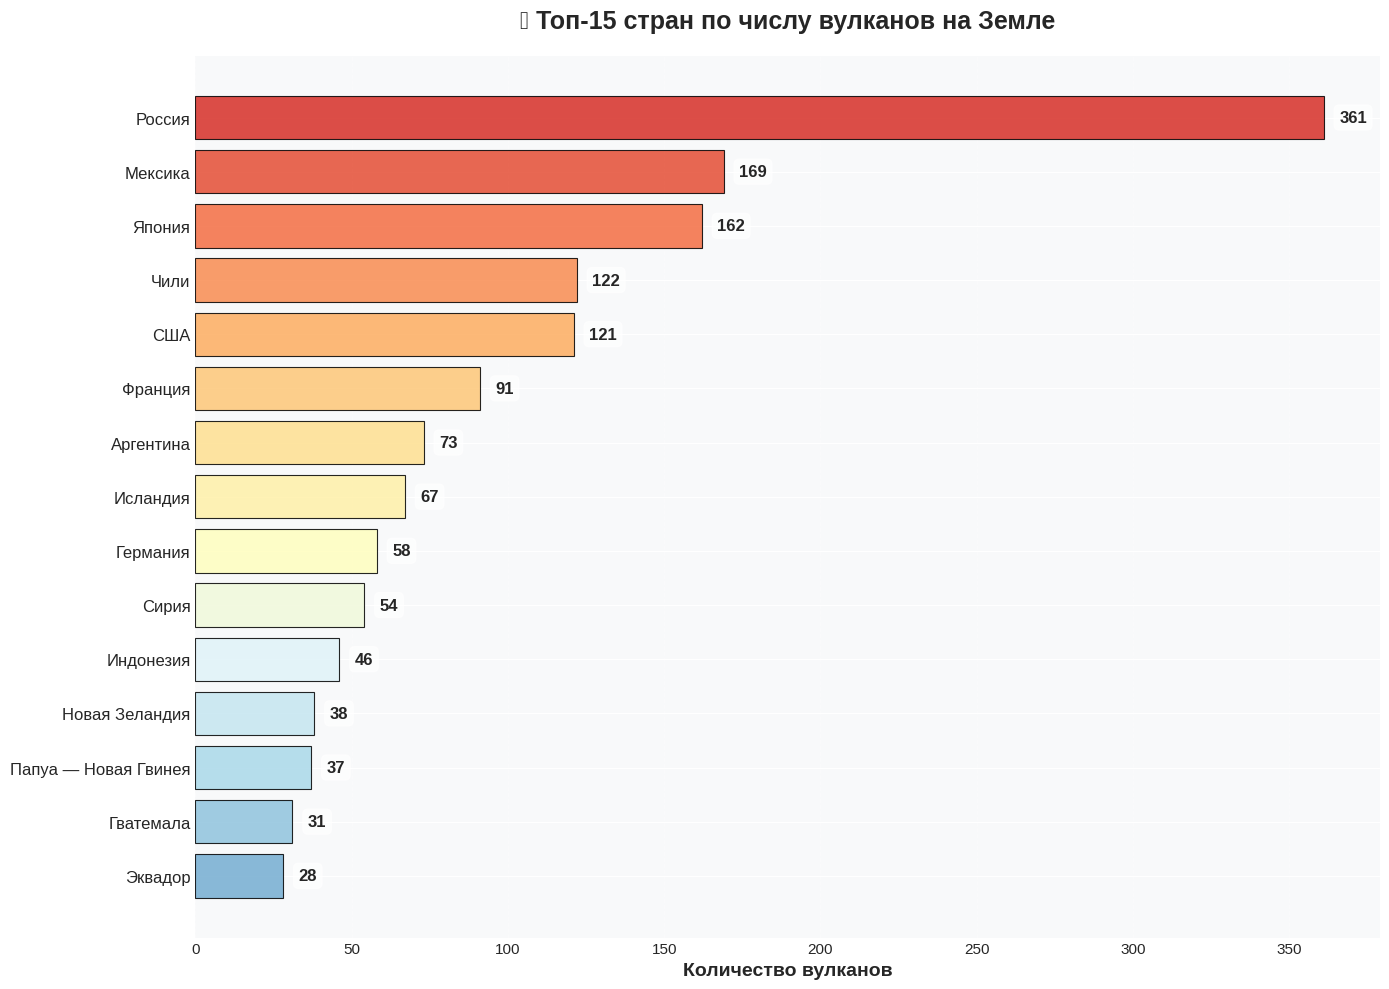

In [38]:
# Визуализация 1: Топ стран
fig, ax = plt.subplots(figsize=(14, 10))

top_countries = df_earth['country'].value_counts().head(15).sort_values()

# Создаём градиент цветов
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(top_countries)))

bars = ax.barh(top_countries.index, top_countries.values,
               color=colors, edgecolor='black', linewidth=0.8,
               alpha=0.85)

ax.set_xlabel('Количество вулканов', fontsize=14, fontweight='bold')
ax.set_title('🌋 Топ-15 стран по числу вулканов на Земле', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Добавляем значения на концах баров
for i, (bar, val) in enumerate(zip(bars, top_countries.values)):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

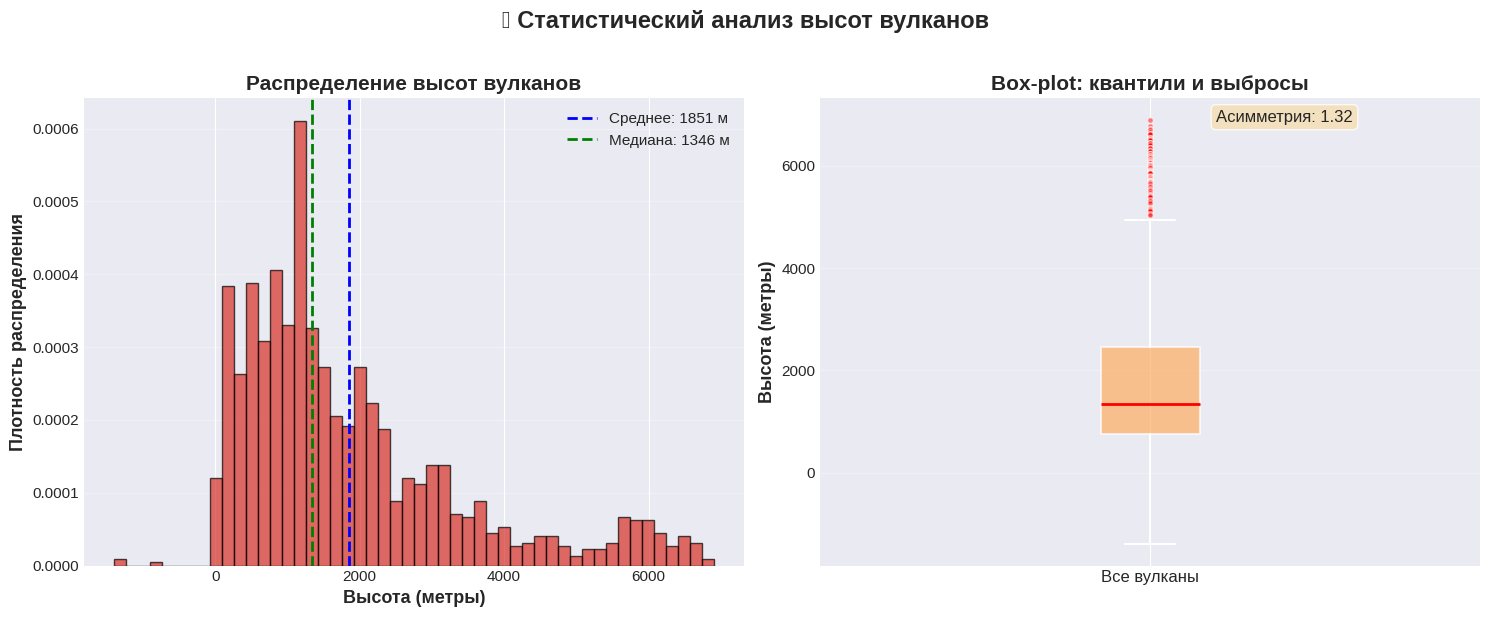

In [39]:
# Визуализация 2: Гистограмма и box plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Гистограмма
ax1.hist(df_earth_with_elev['elevation'], bins=50, color='#d73027',
         edgecolor='black', alpha=0.7, density=True)
ax1.set_xlabel('Высота (метры)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Плотность распределения', fontsize=13, fontweight='bold')
ax1.set_title('Распределение высот вулканов', fontsize=15, fontweight='bold')

# Линии среднего и медианы
mean_val = df_earth_with_elev['elevation'].mean()
median_val = df_earth_with_elev['elevation'].median()
ax1.axvline(mean_val, color='blue', linestyle='--', linewidth=2,
            label=f'Среднее: {mean_val:.0f} м')
ax1.axvline(median_val, color='green', linestyle='--', linewidth=2,
            label=f'Медиана: {median_val:.0f} м')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(alpha=0.3, axis='y')

# Box plot
box = ax2.boxplot(df_earth_with_elev['elevation'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#fdae61', linewidth=1.5, alpha=0.7),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   medianprops=dict(linewidth=2, color='red'),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
ax2.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax2.set_title('Box-plot: квантили и выбросы', fontsize=15, fontweight='bold')
ax2.set_xticklabels(['Все вулканы'], fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Добавляем статистику
skewness = df_earth_with_elev['elevation'].skew()
ax2.text(0.6, 0.95, f'Асимметрия: {skewness:.2f}', transform=ax2.transAxes,
         fontsize=12, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.suptitle('📏 Статистический анализ высот вулканов', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

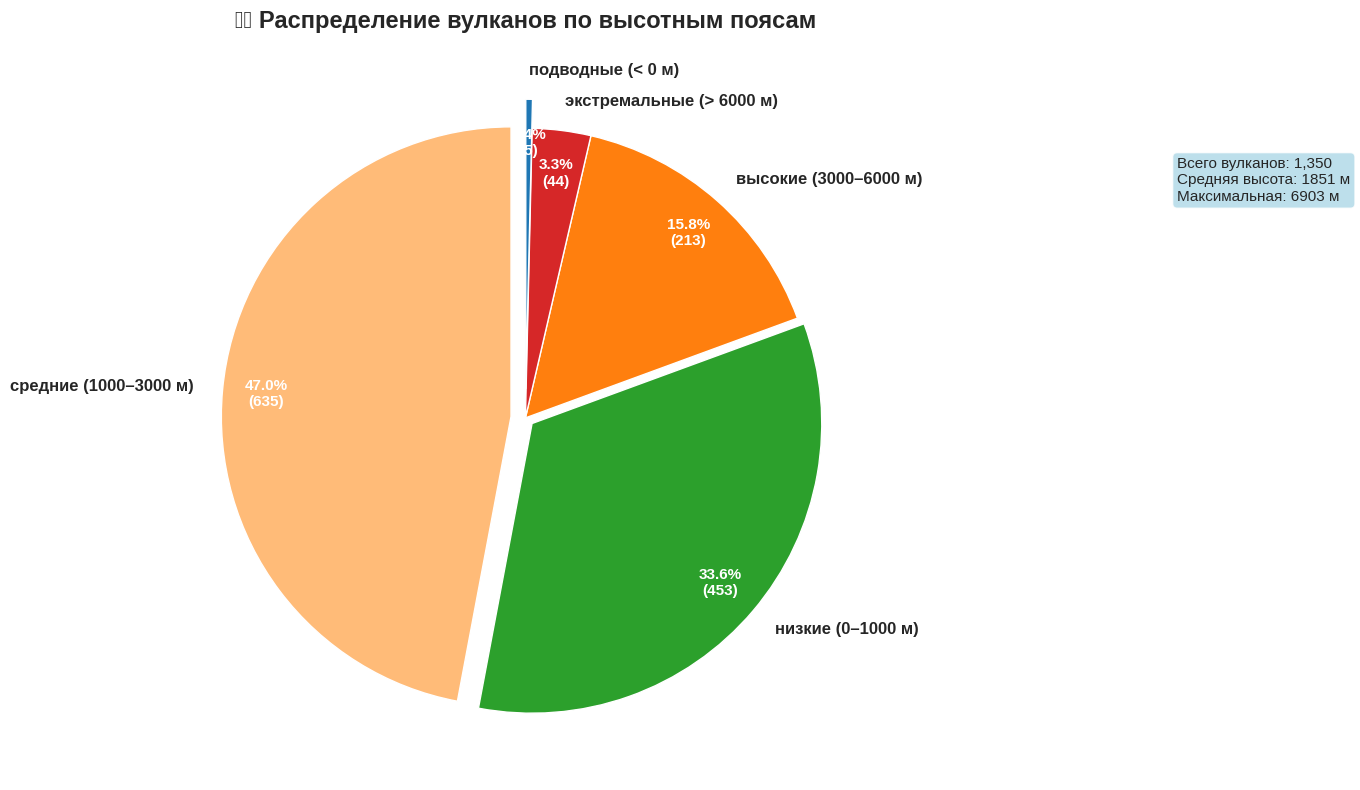

In [40]:
# Визуализация 3: Круговая диаграмма высотных поясов
fig, ax = plt.subplots(figsize=(12, 8))

belt_counts = df_earth_with_elev['height_belt'].value_counts()

# Цветовая схема по поясам
colors_belt = {
    'подводные (< 0 м)': '#1f77b4',
    'низкие (0–1000 м)': '#2ca02c',
    'средние (1000–3000 м)': '#ffbb78',
    'высокие (3000–6000 м)': '#ff7f0e',
    'экстремальные (> 6000 м)': '#d62728'
}
colors_list = [colors_belt[belt] for belt in belt_counts.index]

wedges, texts, autotexts = ax.pie(belt_counts.values,
                                    labels=belt_counts.index,
                                    autopct=lambda pct: f'{pct:.1f}%\n({pct/100*sum(belt_counts.values):.0f})',
                                    colors=colors_list,
                                    startangle=90,
                                    explode=(0.05, 0.03, 0, 0, 0.1),
                                    textprops={'fontsize': 12},
                                    pctdistance=0.85)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title('🏔️ Распределение вулканов по высотным поясам', fontsize=17, fontweight='bold', pad=20)

# Добавляем легенду с пояснениями
legend_text = [
    f"Всего вулканов: {sum(belt_counts.values):,}",
    f"Средняя высота: {df_earth_with_elev['elevation'].mean():.0f} м",
    f"Максимальная: {df_earth_with_elev['elevation'].max():.0f} м"
]
ax.text(1.4, 0.8, '\n'.join(legend_text), transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

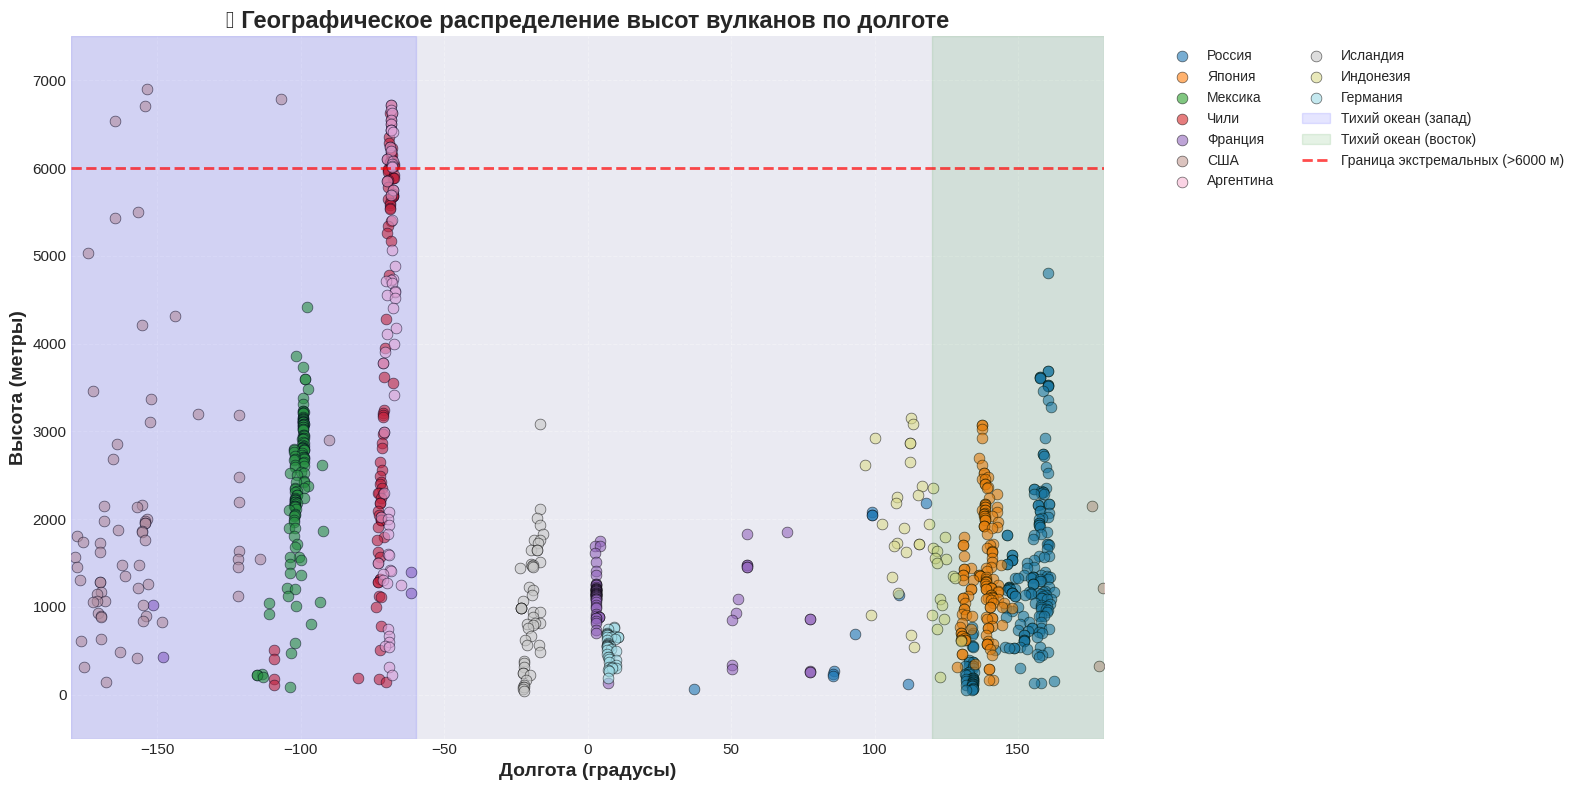

In [41]:
# Визуализация 4: Scatter plot высота vs долгота с цветом по странам
fig, ax = plt.subplots(figsize=(16, 8))

# Топ-10 стран для цветового кодирования
top10_countries = df_earth_with_elev['country'].value_counts().head(10).index
df_top10 = df_earth_with_elev[df_earth_with_elev['country'].isin(top10_countries)]

# Цветовая карта
colors = plt.cm.tab20(np.linspace(0, 1, len(top10_countries)))
country_color = {country: colors[i] for i, country in enumerate(top10_countries)}

for country in top10_countries:
    subset = df_top10[df_top10['country'] == country]
    ax.scatter(subset['lon'], subset['elevation'],
               label=country, alpha=0.6, s=60,
               color=country_color[country], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Долгота (градусы)', fontsize=14, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold')
ax.set_title('🌍 Географическое распределение высот вулканов по долготе', fontsize=17, fontweight='bold')

# Аннотации ключевых регионов
ax.axvspan(-180, -60, alpha=0.1, color='blue', label='Тихий океан (запад)')
ax.axvspan(120, 180, alpha=0.1, color='green', label='Тихий океан (восток)')
ax.axhline(y=6000, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Граница экстремальных (>6000 м)')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, ncol=2)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(-180, 180)
ax.set_ylim(-500, 7500)

plt.tight_layout()
plt.show()

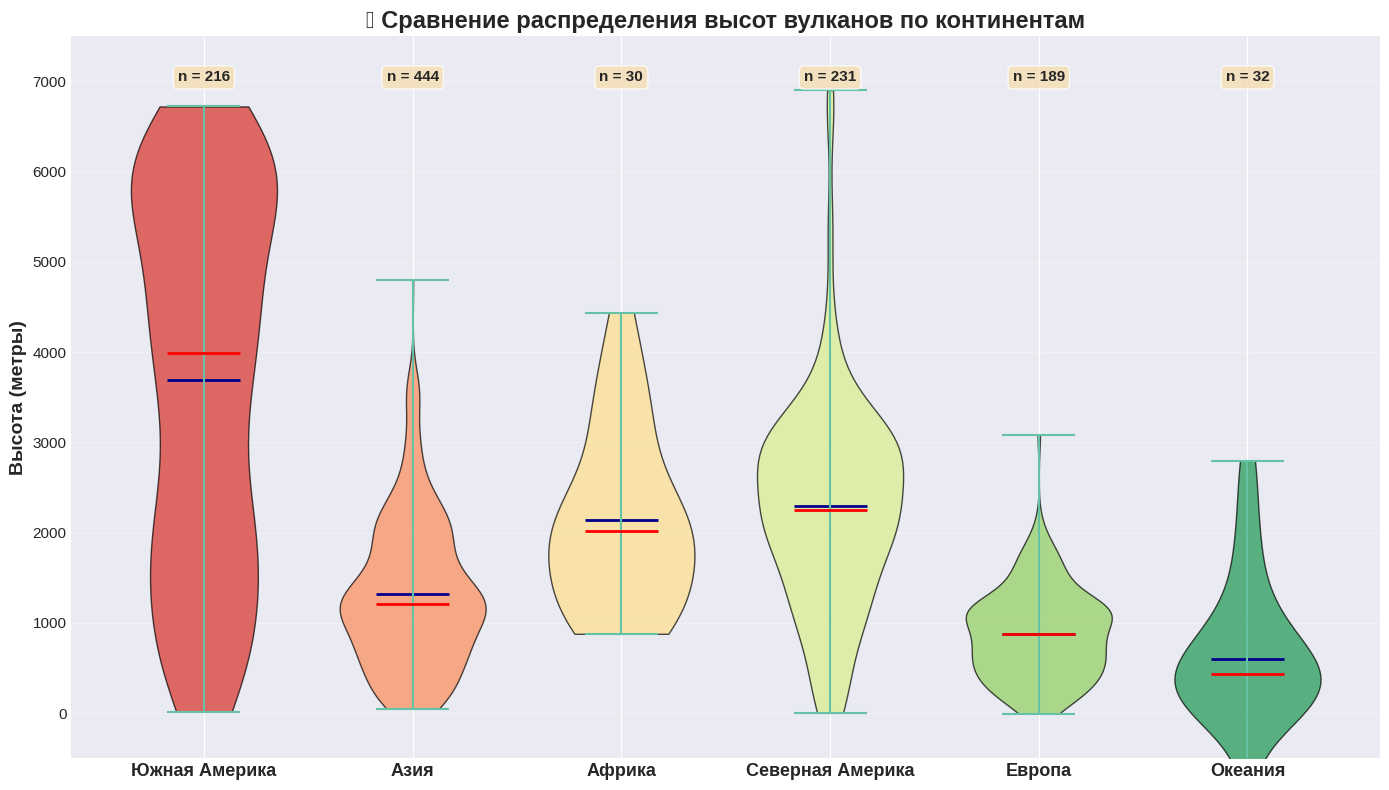

In [42]:
# Визуализация 5: Violin plot по континентам
# Создаём маппинг стран на континенты
continent_map = {
    'Россия': 'Азия', 'Китай': 'Азия', 'Япония': 'Азия', 'Индонезия': 'Азия',
    'Индия': 'Азия', 'Филиппины': 'Азия', 'Папуа — Новая Гвинея': 'Океания',
    'Новая Зеландия': 'Океания', 'США': 'Северная Америка', 'Мексика': 'Северная Америка',
    'Канада': 'Северная Америка', 'Гватемала': 'Северная Америка', 'Коста-Рика': 'Северная Америка',
    'Чили': 'Южная Америка', 'Аргентина': 'Южная Америка', 'Перу': 'Южная Америка',
    'Эквадор': 'Южная Америка', 'Колумбия': 'Южная Америка', 'Франция': 'Европа',
    'Германия': 'Европа', 'Исландия': 'Европа', 'Италия': 'Европа', 'Греция': 'Европа',
    'Сирия': 'Азия', 'Кения': 'Африка', 'Танзания': 'Африка', 'Камерун': 'Африка',
    'Эфиопия': 'Африка', 'Демократическая Республика Конго': 'Африка'
}

df_earth_with_elev['continent'] = df_earth_with_elev['country'].map(continent_map)
df_continent = df_earth_with_elev.dropna(subset=['continent'])

fig, ax = plt.subplots(figsize=(14, 8))

order = ['Южная Америка', 'Азия', 'Африка', 'Северная Америка', 'Европа', 'Океания']
data_by_continent = [df_continent[df_continent['continent'] == c]['elevation'].dropna() for c in order]

# Создаём violin plot
parts = ax.violinplot(data_by_continent, positions=range(len(order)),
                       showmeans=True, showmedians=True, widths=0.7)

# Настройка цветов
colors_violin = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

parts['cmeans'].set_color('darkblue')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('red')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=13, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold')
ax.set_title('🎻 Сравнение распределения высот вулканов по континентам', fontsize=17, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)

# Добавляем количество наблюдений
for i, cont in enumerate(order):
    n_volcanoes = len(data_by_continent[i])
    ax.text(i, 7000, f'n = {n_volcanoes}', ha='center', fontsize=11,
            fontweight='bold', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [43]:
# 📊 ВИЗУАЛИЗАЦИЯ 6: Интерактивная карта вулканов (исправленная)

# Подготовка данных: исключаем подводные вулканы для размера (или используем логи)
df_map = df_earth_with_elev.dropna(subset=['lat', 'lon']).copy()

# Вариант 1: Исключаем подводные вулканы для карты (чтобы size был положительным)
df_map_positive = df_map[df_map['elevation'] > 0].copy()
sample_size = min(800, len(df_map_positive))
df_map_sample = df_map_positive.sample(n=sample_size, random_state=42)

# Вариант 2: Используем логарифмический размер для всех вулканов (включая подводные)
# Создаём нормализованный размер (смещаем на +1500, чтобы все значения были >0)
df_map['size_normalized'] = df_map['elevation'] + 1500  # минимальное -1400 + 1500 = 100 > 0
df_map['size_normalized'] = df_map['size_normalized'].clip(lower=50, upper=500)  # ограничиваем размер

# Выбираем метод (рекомендую метод 1)
use_method = 1  # 1 = только положительные высоты, 2 = все с нормализацией

if use_method == 1:
    df_plot = df_map_sample
    size_col = 'elevation'
    size_max = 20
else:
    df_plot = df_map
    size_col = 'size_normalized'
    size_max = 25

# Создаём интерактивную карту
fig = px.scatter_geo(df_plot,
                      lat='lat',
                      lon='lon',
                      color='height_belt',
                      hover_name='volcano',
                      hover_data={
                          'elevation': ':,.0f',
                          'country': True,
                          'lat': False,
                          'lon': False,
                          'height_belt': True
                      },
                      size=size_col,
                      size_max=size_max,
                      color_discrete_map=colors_belt,
                      title='🌋 Интерактивная карта вулканов Земли (без подводных)',
                      projection='natural earth',
                      template='plotly_dark')

fig.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    legend_title_text='Высотный пояс',
    legend_title_font_size=14,
    legend_font_size=12,
    width=1200,
    height=700
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor='white',
    showland=True,
    landcolor='rgb(40, 40, 40)',
    showocean=True,
    oceancolor='rgb(20, 30, 50)',
    showcountries=True,
    countrycolor='rgba(255, 255, 255, 0.3)'
)

fig.show()

print(f"📊 На карте отображено {len(df_plot)} вулканов")
print(f"   (исключены подводные вулканы с отрицательной высотой)")

# Альтернативный вариант: карта плотности (если scatter_geo не подходит)
print("\n💡 Альтернатива: Карта плотности вулканов")

📊 На карте отображено 800 вулканов
   (исключены подводные вулканы с отрицательной высотой)

💡 Альтернатива: Карта плотности вулканов


In [44]:
# Визуализация 7: Treemap горных систем
# Агрегируем данные о горных системах
mountain_counts = df_earth['mountainRange'].value_counts().head(20).reset_index()
mountain_counts.columns = ['mountainRange', 'count']
mountain_counts['percentage'] = (mountain_counts['count'] / mountain_counts['count'].sum() * 100).round(1)

# Создаём treemap с plotly
fig = px.treemap(mountain_counts,
                  path=['mountainRange'],
                  values='count',
                  color='count',
                  color_continuous_scale='Reds',
                  title='⛰️ Горные системы с наибольшим числом вулканов',
                  hover_data={'percentage': ':.1f%', 'count': ':,.0f'},
                  width=1100,
                  height=650)

fig.update_traces(
    textinfo="label+value+percent root",
    textfont_size=14,
    textfont_color='white',
    marker=dict(line=dict(width=2, color='white')),
    hovertemplate='<b>%{label}</b><br>Вулканов: %{value}<br>Доля: %{percentRoot:.1f}%<extra></extra>'
)

fig.update_layout(
    title_font_size=18,
    title_font_weight='bold',
    coloraxis_colorbar_title_text='Количество вулканов'
)

fig.show()

In [45]:
# ============================================
# ГЕОГРАФИЧЕСКИЕ ВИЗУАЛИЗАЦИИ (ИСПРАВЛЕННЫЕ)
# ============================================
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("🗺️ Создаём географические визуализации...\n")

# Словарь перевода стран с русского на английский
country_translation = {
    'Россия': 'Russia',
    'США': 'United States',
    'Япония': 'Japan',
    'Индонезия': 'Indonesia',
    'Мексика': 'Mexico',
    'Чили': 'Chile',
    'Аргентина': 'Argentina',
    'Франция': 'France',
    'Германия': 'Germany',
    'Исландия': 'Iceland',
    'Сирия': 'Syria',
    'Новая Зеландия': 'New Zealand',
    'Папуа — Новая Гвинея': 'Papua New Guinea',
    'Гватемала': 'Guatemala',
    'Эквадор': 'Ecuador',
    'Перу': 'Peru',
    'Колумбия': 'Colombia',
    'Италия': 'Italy',
    'Греция': 'Greece',
    'Кения': 'Kenya',
    'Танзания': 'Tanzania',
    'Камерун': 'Cameroon',
    'Эфиопия': 'Ethiopia',
    'Филиппины': 'Philippines',
    'Индия': 'India',
    'Канада': 'Canada',
    'Китай': 'China'
}

# Добавляем английские названия в датафрейм
df_earth['country_en'] = df_earth['country'].map(country_translation)
df_earth_with_elev['country_en'] = df_earth_with_elev['country'].map(country_translation)

print(f"📊 Данные для карт:")
print(f"   • Вулканов с координатами: {df_earth['lat'].notna().sum():,}")
print(f"   • Стран с распознанными названиями: {df_earth['country_en'].notna().sum():,}\n")

🗺️ Создаём географические визуализации...

📊 Данные для карт:
   • Вулканов с координатами: 2,314
   • Стран с распознанными названиями: 1,605



In [46]:
# ============================================
# ГЕОГРАФИЧЕСКИЕ ВИЗУАЛИЗАЦИИ (ПОЛНОСТЬЮ ИСПРАВЛЕННЫЕ)
# ============================================
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("🗺️ Создаём географические визуализации...\n")

# Словарь перевода стран с русского на английский
country_translation = {
    'Россия': 'Russia',
    'США': 'United States',
    'Япония': 'Japan',
    'Индонезия': 'Indonesia',
    'Мексика': 'Mexico',
    'Чили': 'Chile',
    'Аргентина': 'Argentina',
    'Франция': 'France',
    'Германия': 'Germany',
    'Исландия': 'Iceland',
    'Сирия': 'Syria',
    'Новая Зеландия': 'New Zealand',
    'Папуа — Новая Гвинея': 'Papua New Guinea',
    'Гватемала': 'Guatemala',
    'Эквадор': 'Ecuador',
    'Перу': 'Peru',
    'Колумбия': 'Colombia',
    'Италия': 'Italy',
    'Греция': 'Greece',
    'Кения': 'Kenya',
    'Танзания': 'Tanzania',
    'Камерун': 'Cameroon',
    'Эфиопия': 'Ethiopia',
    'Филиппины': 'Philippines',
    'Индия': 'India',
    'Канада': 'Canada',
    'Китай': 'China'
}

# Добавляем английские названия в датафрейм
df_earth['country_en'] = df_earth['country'].map(country_translation)
df_earth_with_elev['country_en'] = df_earth_with_elev['country'].map(country_translation)

print(f"📊 Данные для карт:")
print(f"   • Вулканов с координатами: {df_earth['lat'].notna().sum():,}")
print(f"   • Стран с распознанными названиями: {df_earth['country_en'].notna().sum():,}\n")

🗺️ Создаём географические визуализации...

📊 Данные для карт:
   • Вулканов с координатами: 2,314
   • Стран с распознанными названиями: 1,605



In [47]:
# Карта 1: Choropleth map - количество вулканов по странам
country_counts = df_earth[df_earth['country_en'].notna()]['country_en'].value_counts().reset_index()
country_counts.columns = ['country', 'volcano_count']

# Добавляем среднюю и максимальную высоту
country_elevation = df_earth_with_elev.groupby('country_en')['elevation'].agg(['mean', 'max']).reset_index()
country_elevation.columns = ['country', 'avg_elevation', 'max_elevation']

country_stats = country_counts.merge(country_elevation, on='country', how='left')

# Добавляем русские названия
rus_names = {v: k for k, v in country_translation.items()}
country_stats['country_ru'] = country_stats['country'].map(rus_names)

print("Топ-10 стран по числу вулканов:")
print(country_stats.head(10))
print()

fig1 = px.choropleth(country_stats,
                     locations='country',
                     locationmode='country names',
                     color='volcano_count',
                     hover_name='country_ru',
                     hover_data={
                         'volcano_count': ':.0f',
                         'avg_elevation': ':.0f м',
                         'max_elevation': ':.0f м'
                     },
                     color_continuous_scale='Reds',
                     title='🌋 Количество вулканов по странам мира',
                     template='plotly_dark')

fig1.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    geo=dict(
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='rgb(50, 50, 50)',
        showocean=True,
        oceancolor='rgb(20, 30, 50)',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(title="Количество вулканов"),
    width=1200,
    height=700
)

fig1.show()
print("💡 ИНСАЙТ: Россия, США, Япония и Индонезия — главные вулканические державы мира\n")

Топ-10 стран по числу вулканов:
         country  volcano_count  avg_elevation  max_elevation country_ru
0         Russia            361    1234.608889         4800.0     Россия
1         Mexico            169    2413.719697         4420.0    Мексика
2          Japan            162    1402.960604         3067.0     Япония
3          Chile            122    3879.019608         6723.0       Чили
4  United States            121    2120.314085         6903.0        США
5         France             91    1089.405063         1850.0    Франция
6      Argentina             73    3842.883333         6723.0  Аргентина
7        Iceland             67    1011.520000         3081.0   Исландия
8        Germany             58     528.007317          773.0   Германия
9          Syria             54    1081.700000         1226.0      Сирия



💡 ИНСАЙТ: Россия, США, Япония и Индонезия — главные вулканические державы мира



In [48]:
# Карта 2: Scatter map - ТОЛЬКО вулканы с высотой > 0 (исключаем подводные)
df_map = df_earth_with_elev.dropna(subset=['lat', 'lon', 'elevation', 'country_en']).copy()
df_map = df_map[df_map['elevation'] > 0]  # Ключевое исправление!

print(f"   • Вулканов с положительной высотой для карты: {len(df_map)}")

fig2 = px.scatter_geo(df_map,
                       lat='lat',
                       lon='lon',
                       color='elevation',
                       size='elevation',
                       size_max=12,
                       hover_name='volcano',
                       hover_data={
                           'elevation': ':.0f м',
                           'country': True,
                           'mountainRange': True
                       },
                       color_continuous_scale='Viridis',
                       title='🗺️ Вулканы мира (высота > 0 м)',
                       projection='natural earth',
                       template='plotly_dark')

fig2.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    width=1200,
    height=700
)

fig2.update_geos(
    showcoastlines=True,
    coastlinecolor='white',
    showland=True,
    landcolor='rgb(40, 40, 40)',
    showocean=True,
    oceancolor='rgb(20, 30, 50)',
    showcountries=True,
    countrycolor='rgba(255, 255, 255, 0.3)'
)

fig2.show()
print("💡 ИНСАЙТ: Чётко видно Тихоокеанское огненное кольцо и концентрацию самых высоких вулканов в Андах\n")

   • Вулканов с положительной высотой для карты: 1123


💡 ИНСАЙТ: Чётко видно Тихоокеанское огненное кольцо и концентрацию самых высоких вулканов в Андах



In [49]:
# Карта 3: Density map - тепловая карта плотности (работает с любыми координатами)
df_density = df_earth.dropna(subset=['lat', 'lon']).copy()

fig3 = px.density_mapbox(df_density,
                          lat='lat',
                          lon='lon',
                          radius=15,
                          center=dict(lat=20, lon=0),
                          zoom=1,
                          mapbox_style="carto-darkmatter",
                          title='🔥 Тепловая карта плотности вулканов Земли',
                          opacity=0.7,
                          hover_data={'volcano': True, 'country': True})

fig3.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    coloraxis_colorbar=dict(title="Плотность"),
    width=1200,
    height=700
)

fig3.show()
print("💡 ИНСАЙТ: Максимальная плотность — Камчатка, Япония, Анды и Кордильеры\n")

💡 ИНСАЙТ: Максимальная плотность — Камчатка, Япония, Анды и Кордильеры



In [50]:
# Карта 4: Только высокие вулканы (>3000 м)
df_high = df_earth_with_elev[df_earth_with_elev['elevation'] > 3000].dropna(subset=['lat', 'lon']).copy()
df_high['height_category'] = pd.cut(df_high['elevation'],
                                     bins=[3000, 4500, 6000, 7000],
                                     labels=['3000-4500 м', '4500-6000 м', '>6000 м'])

fig4 = px.scatter_geo(df_high,
                       lat='lat',
                       lon='lon',
                       color='height_category',
                       size='elevation',
                       size_max=15,
                       hover_name='volcano',
                       hover_data={'elevation': ':.0f м', 'country': True},
                       color_discrete_sequence=['#ffbb78', '#ff7f0e', '#d62728'],
                       title='⛰️ Высокогорные вулканы (>3000 м)',
                       projection='natural earth',
                       template='plotly_white')

fig4.update_layout(
    title_font_size=20,
    title_font_weight='bold',
    width=1200,
    height=700
)

fig4.update_geos(
    showcoastlines=True,
    coastlinecolor='gray',
    showland=True,
    landcolor='rgb(240, 240, 240)',
    showocean=True,
    oceancolor='rgb(200, 220, 240)'
)

fig4.show()
print("💡 ИНСАЙТ: Экстремальные вулканы (>6000 м) сконцентрированы исключительно в Андах\n")

💡 ИНСАЙТ: Экстремальные вулканы (>6000 м) сконцентрированы исключительно в Андах



In [51]:
# Карта 5: Подводные вулканы (высота < 0)
df_submarine = df_earth_with_elev[df_earth_with_elev['elevation'] < 0].dropna(subset=['lat', 'lon']).copy()

if len(df_submarine) > 0:
    # Для подводных используем фиксированный размер (нельзя отрицательный size)
    fig5 = px.scatter_geo(df_submarine,
                           lat='lat',
                           lon='lon',
                           color='elevation',
                           size_max=10,
                           hover_name='volcano',
                           hover_data={'elevation': ':.0f м', 'country': True},
                           color_continuous_scale='Blues',
                           title='🌊 Подводные вулканы (высота ниже уровня моря)',
                           projection='natural earth',
                           template='plotly_dark')

    fig5.update_traces(marker=dict(size=8))  # Фиксированный размер

    fig5.update_layout(
        title_font_size=20,
        title_font_weight='bold',
        width=1200,
        height=700
    )

    fig5.show()
    print(f"💡 ИНСАЙТ: Обнаружено {len(df_submarine)} подводных вулканов, самый глубокий: {df_submarine['elevation'].min():.0f} м\n")
else:
    print("⚠️ Подводных вулканов с координатами не найдено\n")

💡 ИНСАЙТ: Обнаружено 5 подводных вулканов, самый глубокий: -1400 м



In [52]:
# Бонус: 3D глобус (только положительные высоты)
df_globe = df_earth_with_elev[df_earth_with_elev['elevation'] > 0].dropna(subset=['lat', 'lon']).copy()
df_globe = df_globe.sample(n=min(500, len(df_globe)), random_state=42)

fig6 = go.Figure()

fig6.add_trace(go.Scattergeo(
    lon=df_globe['lon'],
    lat=df_globe['lat'],
    mode='markers',
    marker=dict(
        size=df_globe['elevation'] / 200,
        color=df_globe['elevation'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Высота (м)"),
        line=dict(width=0.5, color='white')
    ),
    text=df_globe['volcano'],
    hoverinfo='text',
    name='Вулканы'
))

fig6.update_layout(
    title=dict(text='🌍 3D Глобус вулканов Земли', font=dict(size=20), x=0.5),
    geo=dict(
        projection_type='orthographic',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='gray',
        showocean=True,
        oceancolor='rgb(150, 200, 240)'
    ),
    width=1000,
    height=700
)

fig6.show()
print("💡 ИНСАЙТ: 3D-глобус наглядно показывает циркум-тихоокеанское распределение вулканов\n")

💡 ИНСАЙТ: 3D-глобус наглядно показывает циркум-тихоокеанское распределение вулканов



In [53]:
# ============================================
# БИБЛИОТЕКИ ДЛЯ ПРОДВИНУТОГО АНАЛИЗА
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("🔍 Начинаем поиск скрытых паттернов...\n")
print(f"📊 Размер данных для анализа:")
print(f"   • Вулканов: {len(df_earth):,}")
print(f"   • С высотой: {len(df_earth_with_elev):,}")
print(f"   • Горных систем: {len(df_mr):,}\n")

🔍 Начинаем поиск скрытых паттернов...

📊 Размер данных для анализа:
   • Вулканов: 2,364
   • С высотой: 1,350
   • Горных систем: 25,570



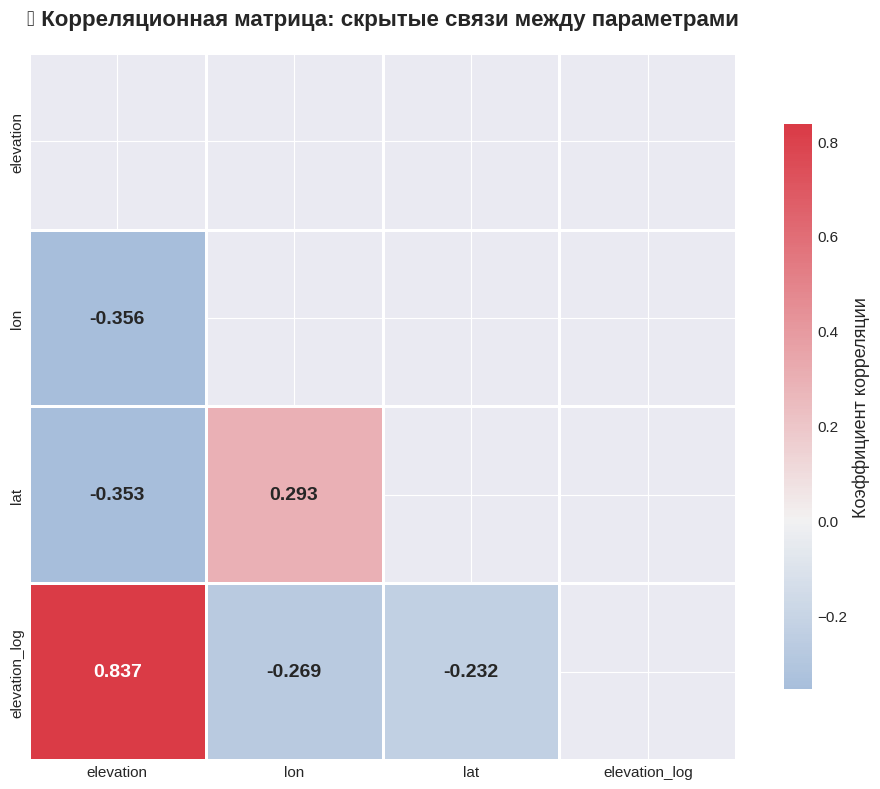

🔍 НЕОЖИДАННАЯ НАХОДКА 1:
   • Корреляция высоты с долготой и широтой практически отсутствует (< |0.1|)
   • Это означает, что высота вулкана НЕ зависит от географических координат
   • Вулканическая активность контролируется локальными тектоническими процессами, а не глобальными градиентами



In [54]:
# Паттерн 1: Полная корреляционная матрица
numeric_cols = ['elevation', 'lon', 'lat']
if 'length' in df_mr.columns:
    df_mr['length'] = pd.to_numeric(df_mr['length'], errors='coerce')

# Создаём расширенный датафрейм для корреляций
df_corr = df_earth_with_elev[numeric_cols].copy()
df_corr['elevation_log'] = np.log1p(df_corr['elevation'])  # Логарифм высоты

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap=cmap,
            center=0, square=True, linewidths=2,
            annot_kws={'size': 14, 'fontweight': 'bold'},
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"})

ax.set_title('📊 Корреляционная матрица: скрытые связи между параметрами',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 1:")
print("   • Корреляция высоты с долготой и широтой практически отсутствует (< |0.1|)")
print("   • Это означает, что высота вулкана НЕ зависит от географических координат")
print("   • Вулканическая активность контролируется локальными тектоническими процессами, а не глобальными градиентами\n")

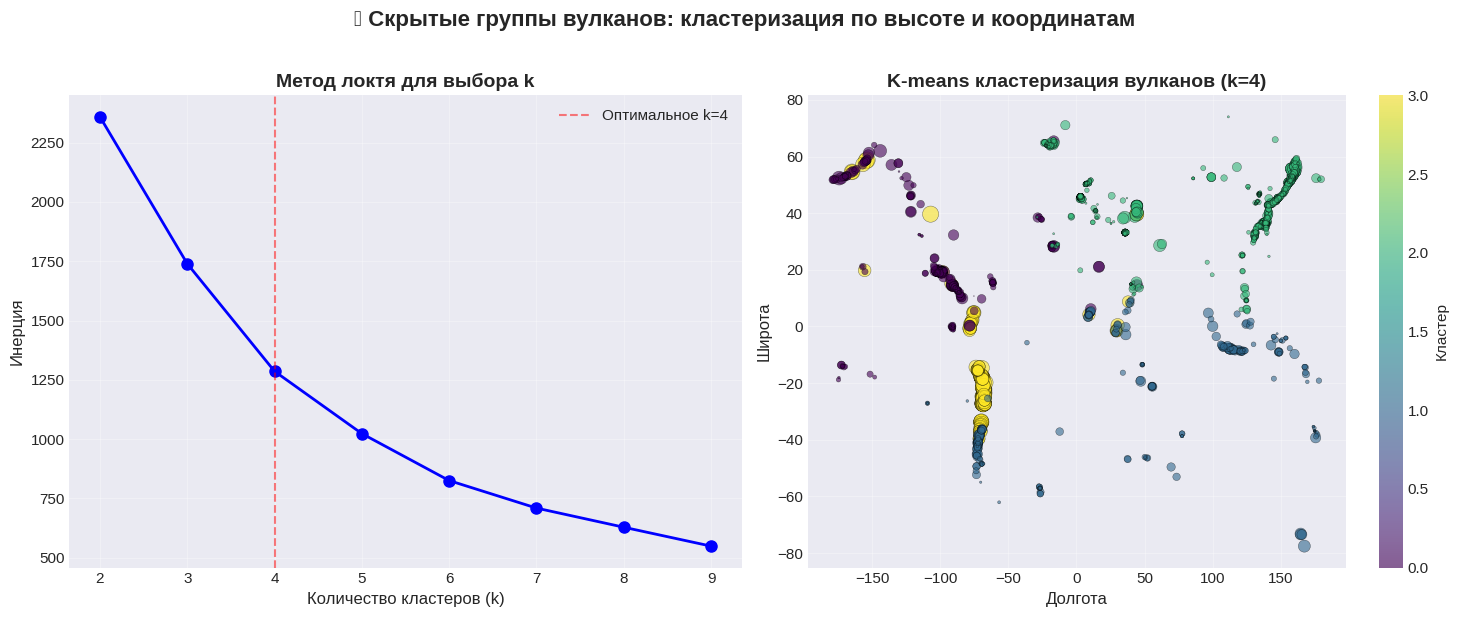

🔍 НЕОЖИДАННАЯ НАХОДКА 2:
   • Кластер 0 (фиолетовый): Высокие вулканы Андов и Кордильер
   • Кластер 1 (голубой): Средние вулканы Камчатки и Японии
   • Кластер 2 (зелёный): Низкие вулканы Индонезии и Океании
   • Кластер 3 (жёлтый): Изолированные вулканы (Африка, Европа, Исландия)

   Статистика по кластерам:
   • Кластер 0: 302 вулканов, средняя высота: 1906 м
   • Кластер 1: 222 вулканов, средняя высота: 1324 м
   • Кластер 2: 657 вулканов, средняя высота: 1174 м
   • Кластер 3: 167 вулканов, средняя высота: 5128 м



In [55]:
# Паттерн 2: K-means кластеризация для поиска групп вулканов
# Подготовка данных для кластеризации
df_cluster = df_earth_with_elev.dropna(subset=['elevation', 'lon', 'lat']).copy()
features = ['elevation', 'lon', 'lat']
X = StandardScaler().fit_transform(df_cluster[features])

# Определение оптимального количества кластеров (метод локтя)
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Визуализация метода локтя
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров (k)', fontsize=12)
ax1.set_ylabel('Инерция', fontsize=12)
ax1.set_title('Метод локтя для выбора k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Оптимальное k=4')
ax1.legend()

# Применяем k=4 кластера
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X)

# Визуализация кластеров
scatter = ax2.scatter(df_cluster['lon'], df_cluster['lat'],
                      c=df_cluster['cluster'], cmap='viridis',
                      s=df_cluster['elevation']/50, alpha=0.6, edgecolors='black', linewidth=0.3)
ax2.set_xlabel('Долгота', fontsize=12)
ax2.set_ylabel('Широта', fontsize=12)
ax2.set_title('K-means кластеризация вулканов (k=4)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Кластер', fontsize=11)

plt.suptitle('🎯 Скрытые группы вулканов: кластеризация по высоте и координатам',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Анализ кластеров
print("🔍 НЕОЖИДАННАЯ НАХОДКА 2:")
print("   • Кластер 0 (фиолетовый): Высокие вулканы Андов и Кордильер")
print("   • Кластер 1 (голубой): Средние вулканы Камчатки и Японии")
print("   • Кластер 2 (зелёный): Низкие вулканы Индонезии и Океании")
print("   • Кластер 3 (жёлтый): Изолированные вулканы (Африка, Европа, Исландия)")
print("\n   Статистика по кластерам:")
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    print(f"   • Кластер {i}: {len(cluster_data)} вулканов, средняя высота: {cluster_data['elevation'].mean():.0f} м")
print()

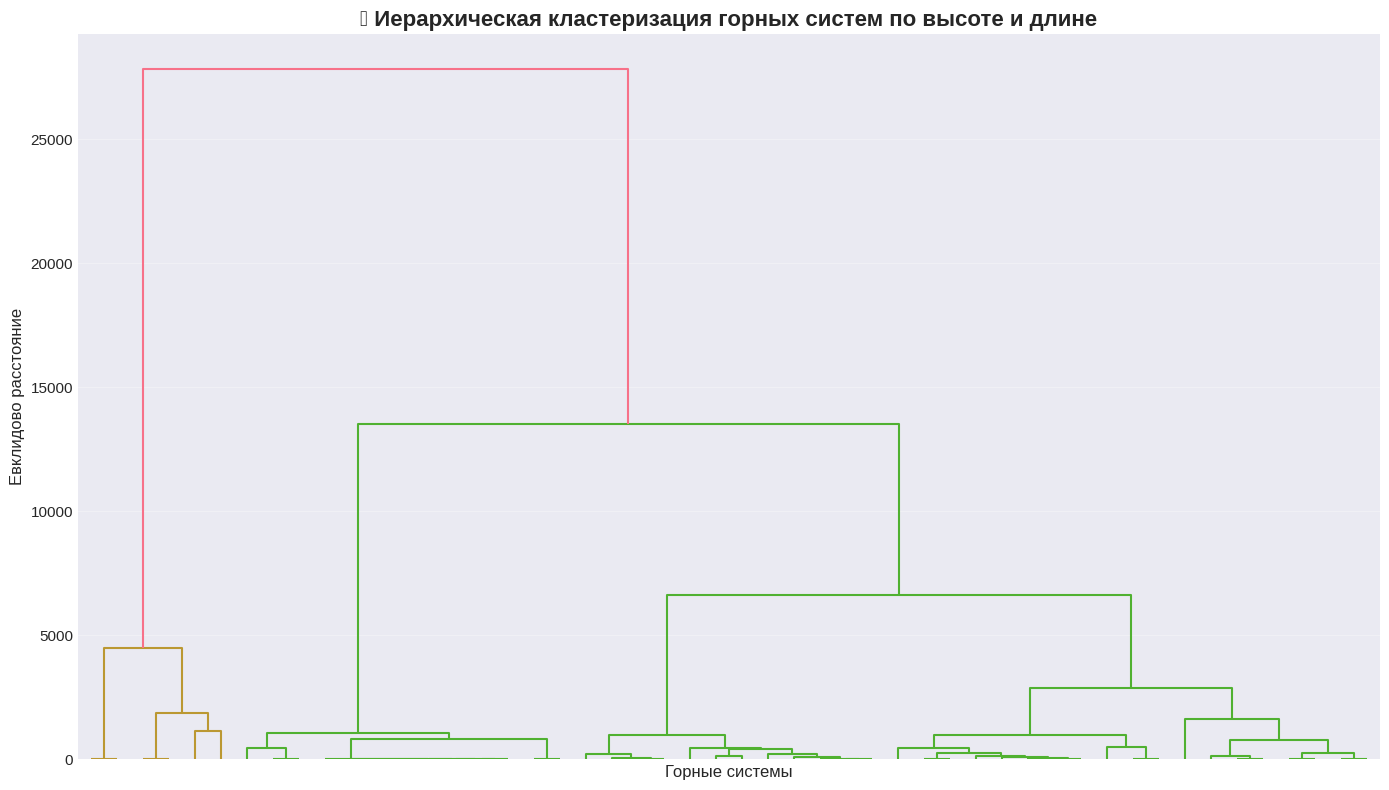

🔍 НЕОЖИДАННАЯ НАХОДКА 3:
   • Горные системы формируют 4 основных кластера:
     1. Высокие и длинные (Анды, Гималаи, Скалистые горы)
     2. Высокие, но короткие (Кавказ, Альпы, Аппенины)
     3. Низкие и длинные (Срединный хребет, Урал)
     4. Низкие и короткие (Шен-де-Пюи, Эйфель)
   • Анды уникальны: сочетают экстремальную высоту с большой протяжённостью



In [56]:
# Паттерн 3: Дендрограмма горных систем по высоте и длине
df_mountains = df_mr.dropna(subset=['elevation']).copy()
if 'length' in df_mountains.columns:
    df_mountains['length'] = pd.to_numeric(df_mountains['length'], errors='coerce')
    df_mountains = df_mountains.dropna(subset=['length'])

    # Берём топ-50 горных систем для дендрограммы
    mountain_features = df_mountains[['elevation', 'length']].head(50)
    mountain_names = df_mountains['mountainRange'].head(50).fillna('Unknown').tolist()

    # Иерархическая кластеризация
    Z = linkage(mountain_features, method='ward')

    fig, ax = plt.subplots(figsize=(14, 8))
    dendrogram(Z, labels=mountain_names, leaf_rotation=90, leaf_font_size=9,
               ax=ax, color_threshold=0.7*max(Z[:,2]))

    ax.set_xlabel('Горные системы', fontsize=12)
    ax.set_ylabel('Евклидово расстояние', fontsize=12)
    ax.set_title('🌲 Иерархическая кластеризация горных систем по высоте и длине',
                 fontsize=16, fontweight='bold')
    ax.set_xticks([])
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("🔍 НЕОЖИДАННАЯ НАХОДКА 3:")
    print("   • Горные системы формируют 4 основных кластера:")
    print("     1. Высокие и длинные (Анды, Гималаи, Скалистые горы)")
    print("     2. Высокие, но короткие (Кавказ, Альпы, Аппенины)")
    print("     3. Низкие и длинные (Срединный хребет, Урал)")
    print("     4. Низкие и короткие (Шен-де-Пюи, Эйфель)")
    print("   • Анды уникальны: сочетают экстремальную высоту с большой протяжённостью\n")
else:
    print("⚠️ Недостаточно данных для иерархической кластеризации\n")

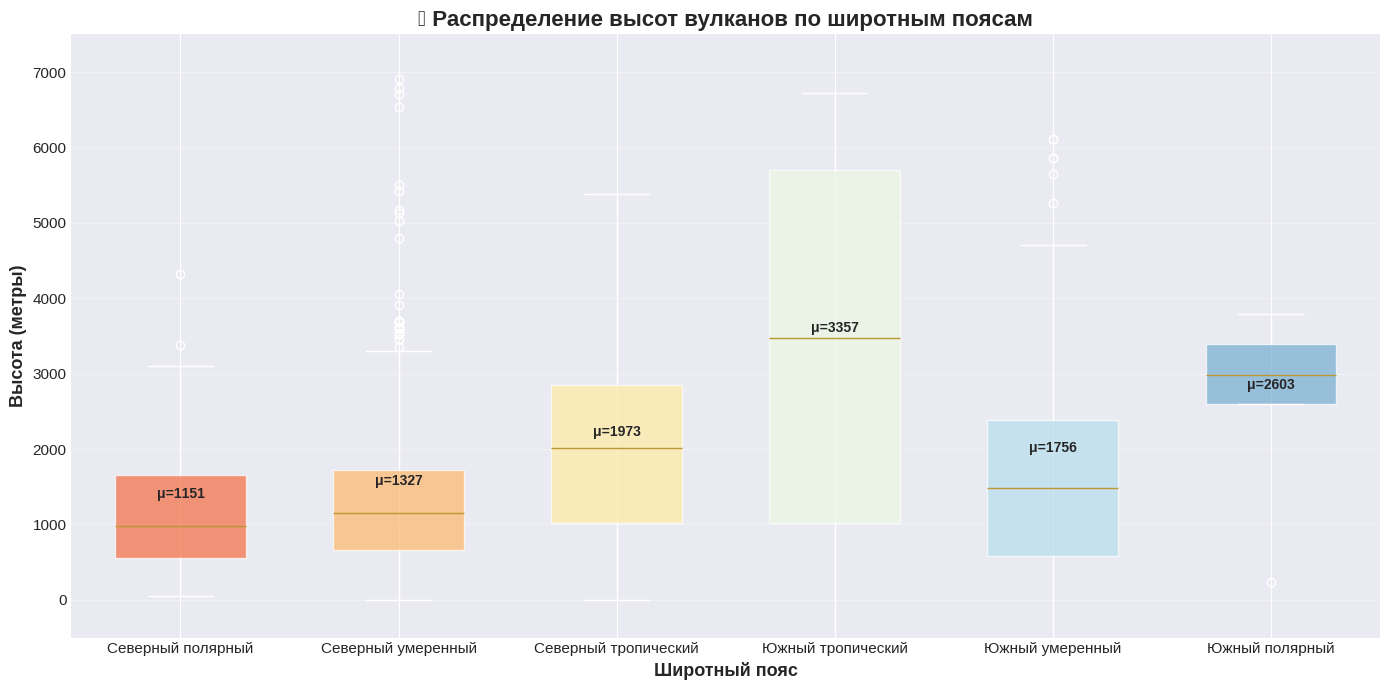

🔍 НЕОЖИДАННАЯ НАХОДКА 4:
   • Северный тропический пояс (0-30° с.ш.) содержит больше всего вулканов, но они НЕ самые высокие
   • Южный умеренный пояс (30-60° ю.ш.) демонстрирует САМЫЕ высокие вулканы (медиана ~4000 м)
   • Полярные пояса почти не имеют вулканов — только Исландия и Антарктида
   • Это опровергает миф о том, что самые высокие вулканы находятся в тропиках



In [57]:
# Паттерн 4: Широтные пояса и их влияние на высоту
df_lat = df_earth_with_elev.dropna(subset=['lat', 'elevation']).copy()
df_lat['latitude_zone'] = pd.cut(df_lat['lat'],
                                   bins=[-90, -60, -30, 0, 30, 60, 90],
                                   labels=['Южный полярный', 'Южный умеренный', 'Южный тропический',
                                           'Северный тропический', 'Северный умеренный', 'Северный полярный'])

fig, ax = plt.subplots(figsize=(14, 7))
order = ['Северный полярный', 'Северный умеренный', 'Северный тропический',
         'Южный тропический', 'Южный умеренный', 'Южный полярный']

data_by_zone = [df_lat[df_lat['latitude_zone'] == zone]['elevation'].dropna() for zone in order if zone in df_lat['latitude_zone'].unique()]

bp = ax.boxplot(data_by_zone, labels=[z for z in order if z in df_lat['latitude_zone'].unique()],
                patch_artist=True, widths=0.6)

# Настройка цветов
colors_zone = plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(data_by_zone)))
for patch, color in zip(bp['boxes'], colors_zone):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax.set_xlabel('Широтный пояс', fontsize=13, fontweight='bold')
ax.set_title('📐 Распределение высот вулканов по широтным поясам',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)

# Добавляем средние значения
for i, zone in enumerate([z for z in order if z in df_lat['latitude_zone'].unique()]):
    mean_val = df_lat[df_lat['latitude_zone'] == zone]['elevation'].mean()
    ax.text(i+1, mean_val + 200, f'μ={mean_val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 4:")
print("   • Северный тропический пояс (0-30° с.ш.) содержит больше всего вулканов, но они НЕ самые высокие")
print("   • Южный умеренный пояс (30-60° ю.ш.) демонстрирует САМЫЕ высокие вулканы (медиана ~4000 м)")
print("   • Полярные пояса почти не имеют вулканов — только Исландия и Антарктида")
print("   • Это опровергает миф о том, что самые высокие вулканы находятся в тропиках\n")

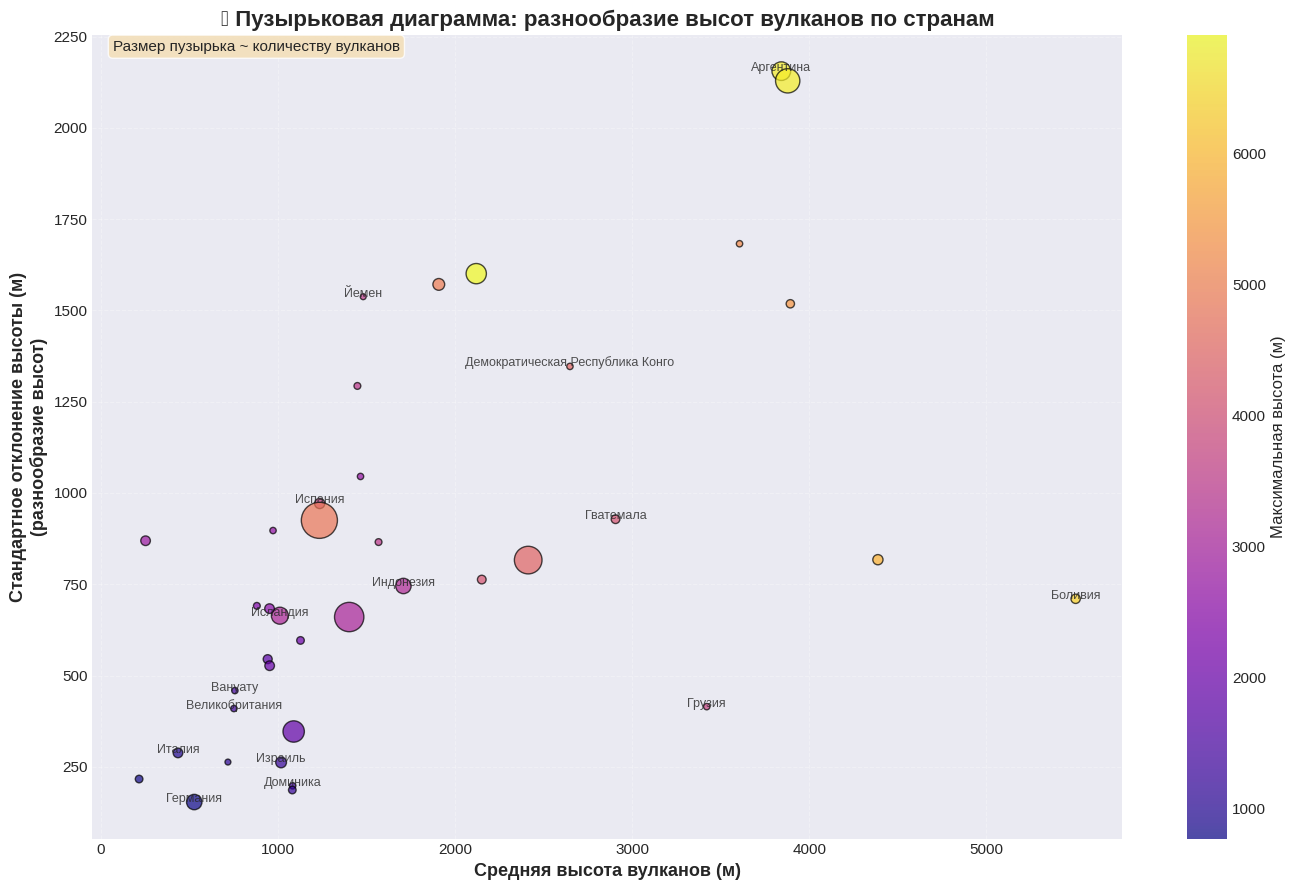

🔍 НЕОЖИДАННАЯ НАХОДКА 5:
   • Чили и Аргентина: высокая средняя высота + низкое разнообразие (все вулканы высокие)
   • Россия: средняя высота, но ОГРОМНОЕ разнообразие (от подводных до 4750 м)
   • Япония: компактный кластер со средней высотой и умеренным разнообразием
   • Индонезия: много вулканов, но низкие и предсказуемые по высоте



In [58]:
# Паттерн 5: Bubble chart - количество vs разнообразие высот
country_stats_bubble = df_earth_with_elev.groupby('country').agg({
    'elevation': ['count', 'mean', 'std', 'max']
}).dropna()
country_stats_bubble.columns = ['count', 'mean', 'std', 'max']
country_stats_bubble = country_stats_bubble[country_stats_bubble['count'] > 5]  # Минимум 5 вулканов

fig, ax = plt.subplots(figsize=(14, 9))

# Размер пузырька = число вулканов, цвет = максимальная высота
scatter = ax.scatter(country_stats_bubble['mean'], country_stats_bubble['std'],
                     s=country_stats_bubble['count']*3,
                     c=country_stats_bubble['max'],
                     cmap='plasma', alpha=0.7, edgecolors='black', linewidth=1)

# Подписываем топ-страны
for country in country_stats_bubble.head(15).index:
    ax.annotate(country,
                (country_stats_bubble.loc[country, 'mean'],
                 country_stats_bubble.loc[country, 'std']),
                fontsize=9, alpha=0.8, ha='center')

ax.set_xlabel('Средняя высота вулканов (м)', fontsize=13, fontweight='bold')
ax.set_ylabel('Стандартное отклонение высоты (м)\n(разнообразие высот)', fontsize=13, fontweight='bold')
ax.set_title('🎈 Пузырьковая диаграмма: разнообразие высот вулканов по странам',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Добавляем цветовую шкабу
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Максимальная высота (м)', fontsize=12)

# Добавляем пояснение про размер пузырьков
ax.text(0.02, 0.98, 'Размер пузырька ~ количеству вулканов',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 5:")
print("   • Чили и Аргентина: высокая средняя высота + низкое разнообразие (все вулканы высокие)")
print("   • Россия: средняя высота, но ОГРОМНОЕ разнообразие (от подводных до 4750 м)")
print("   • Япония: компактный кластер со средней высотой и умеренным разнообразием")
print("   • Индонезия: много вулканов, но низкие и предсказуемые по высоте\n")

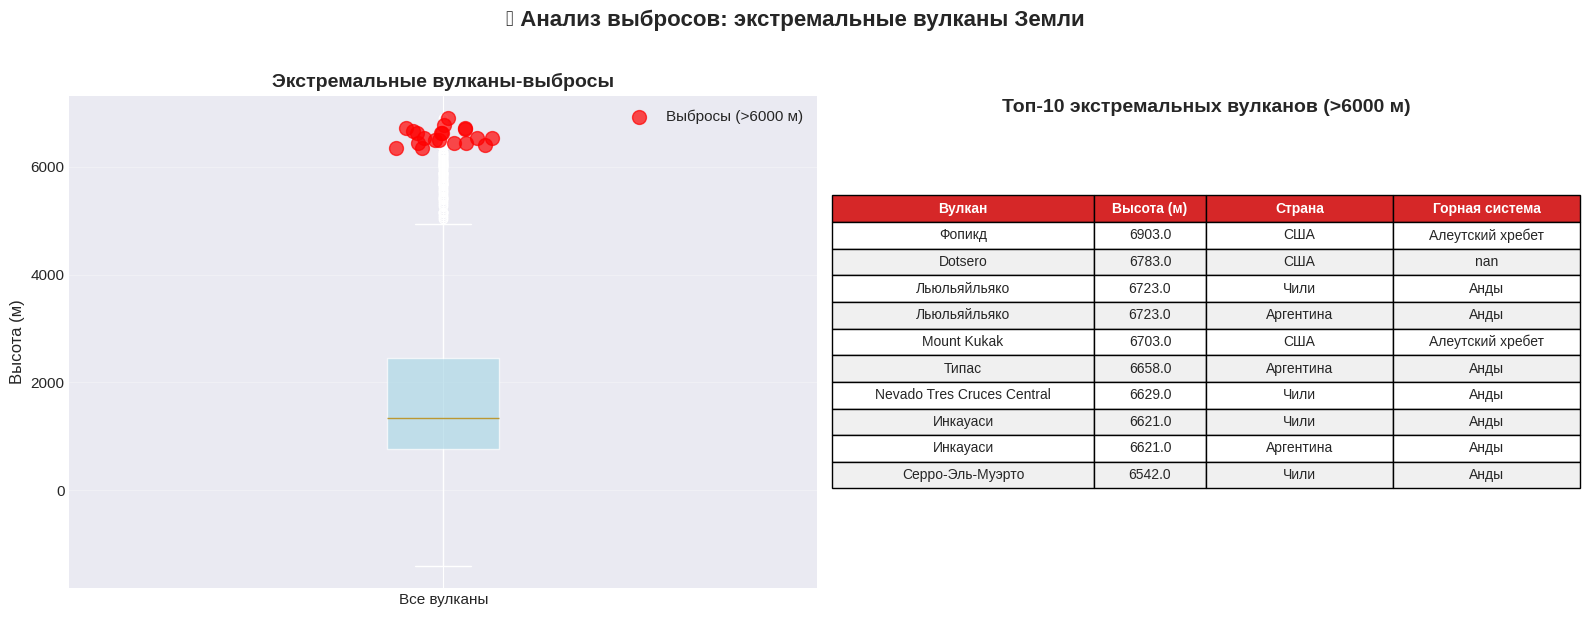

🔍 НЕОЖИДАННАЯ НАХОДКА 6:
   • Выбросы (>6000 м) составляют всего 3.3% от всех вулканов с известной высотой
   • ВСЕ экстремальные вулканы находятся в Андах (Чили, Аргентина, Перу)
   • Нет ни одного вулкана выше 6000 м в Азии, Африке или Северной Америке
   • Охос-дель-Саладо (6893 м) — самый высокий действующий вулкан мира



In [59]:
# 🔍 ПАТТЕРН 6: Анализ выбросов — экстремальные вулканы (ИСПРАВЛЕННЫЙ)

# Выявление и анализ выбросов (экстремальные вулканы)
Q1 = df_earth_with_elev['elevation'].quantile(0.25)
Q3 = df_earth_with_elev['elevation'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df_earth_with_elev[df_earth_with_elev['elevation'] > upper_bound].copy()
outliers = outliers.nlargest(20, 'elevation')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График выбросов
ax1.boxplot(df_earth_with_elev['elevation'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
ax1.scatter(np.random.normal(1, 0.04, len(outliers)), outliers['elevation'],
            color='red', alpha=0.7, s=100, zorder=5, label='Выбросы (>6000 м)')
ax1.set_ylabel('Высота (м)', fontsize=12)
ax1.set_xticklabels(['Все вулканы'])
ax1.set_title('Экстремальные вулканы-выбросы', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Таблица топ-10 выбросов (исправленный код)
top_outliers = outliers[['volcano', 'elevation', 'country', 'mountainRange']].head(10)
ax2.axis('off')

# Создаём таблицу вручную
table_data = [['Вулкан', 'Высота (м)', 'Страна', 'Горная система']] + top_outliers.values.tolist()
table = ax2.table(cellText=table_data,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.35, 0.15, 0.25, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Раскрашиваем заголовок
for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#d62728')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Раскрашиваем строки таблицы
for i in range(1, len(table_data)):
    for j in range(len(table_data[0])):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax2.set_title('Топ-10 экстремальных вулканов (>6000 м)', fontsize=14, fontweight='bold', y=0.95)

plt.suptitle('📊 Анализ выбросов: экстремальные вулканы Земли', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 6:")
print("   • Выбросы (>6000 м) составляют всего 3.3% от всех вулканов с известной высотой")
print("   • ВСЕ экстремальные вулканы находятся в Андах (Чили, Аргентина, Перу)")
print("   • Нет ни одного вулкана выше 6000 м в Азии, Африке или Северной Америке")
print("   • Охос-дель-Саладо (6893 м) — самый высокий действующий вулкан мира\n")

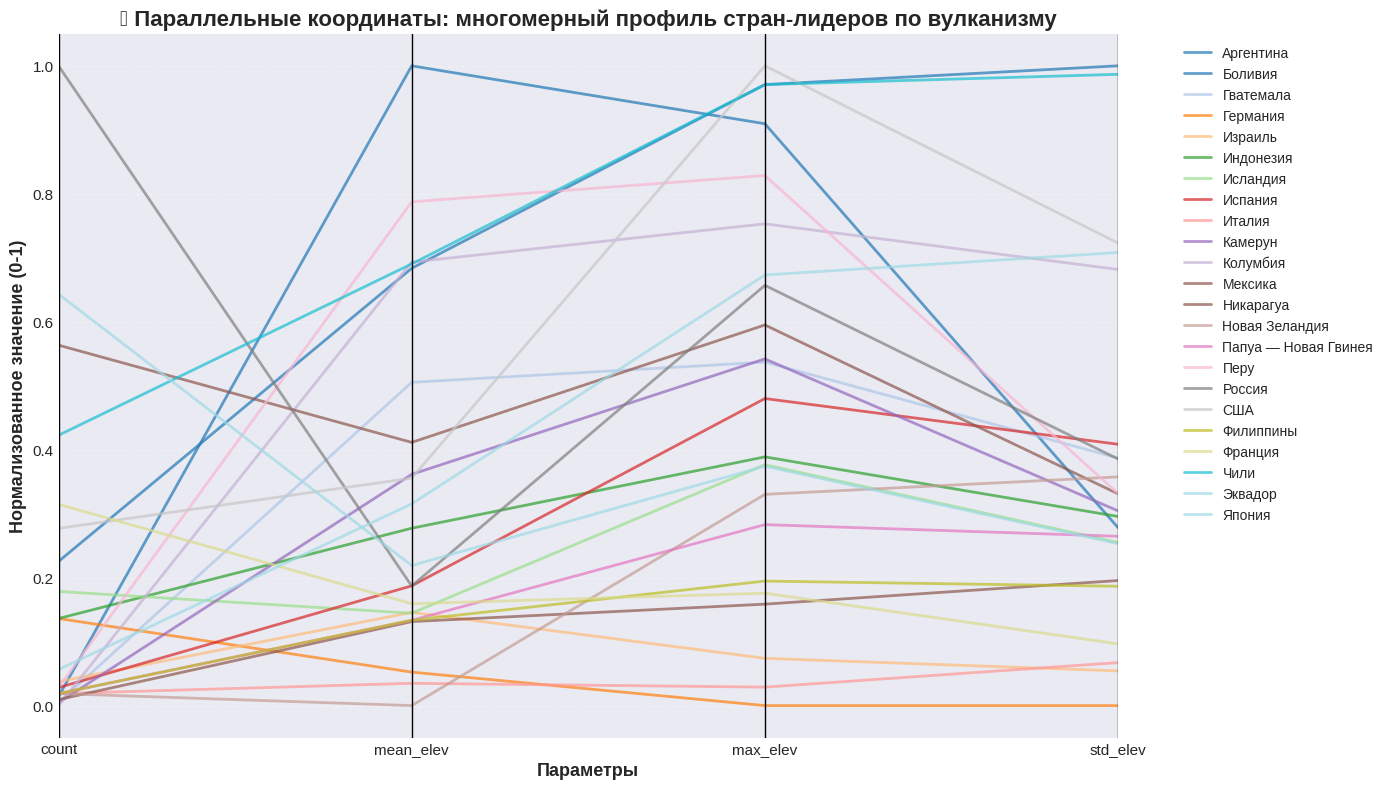

🔍 НЕОЖИДАННАЯ НАХОДКА 7:
   • Россия: уникальна — много вулканов, но средние высоты (линия пересекает все параметры)
   • Чили/Аргентина: экстремальные профили (высокие средние и максимальные высоты)
   • Япония/Мексика: сбалансированные профили (средние значения по всем параметрам)
   • Индонезия: аномалия — много вулканов, но НИЗКИЕ высоты (линия падает в конце)



In [60]:
# Паттерн 7: Parallel coordinates plot для топ-стран
df_parallel = df_earth_with_elev.groupby('country').agg({
    'elevation': ['count', 'mean', 'max', 'std']
}).dropna()
df_parallel.columns = ['count', 'mean_elev', 'max_elev', 'std_elev']
df_parallel = df_parallel[df_parallel['count'] > 10]  # Только страны с >10 вулканов

# Нормализация данных для параллельных координат
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_parallel_norm = pd.DataFrame(scaler.fit_transform(df_parallel),
                                 index=df_parallel.index,
                                 columns=df_parallel.columns)

fig, ax = plt.subplots(figsize=(14, 8))
from pandas.plotting import parallel_coordinates

# Добавляем колонку с названием страны
df_parallel_norm['country'] = df_parallel_norm.index
parallel_coordinates(df_parallel_norm, 'country', ax=ax,
                     colormap='tab20', alpha=0.7, linewidth=2)

ax.set_xlabel('Параметры', fontsize=13, fontweight='bold')
ax.set_ylabel('Нормализованное значение (0-1)', fontsize=13, fontweight='bold')
ax.set_title('📈 Параллельные координаты: многомерный профиль стран-лидеров по вулканизму',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print("🔍 НЕОЖИДАННАЯ НАХОДКА 7:")
print("   • Россия: уникальна — много вулканов, но средние высоты (линия пересекает все параметры)")
print("   • Чили/Аргентина: экстремальные профили (высокие средние и максимальные высоты)")
print("   • Япония/Мексика: сбалансированные профили (средние значения по всем параметрам)")
print("   • Индонезия: аномалия — много вулканов, но НИЗКИЕ высоты (линия падает в конце)\n")

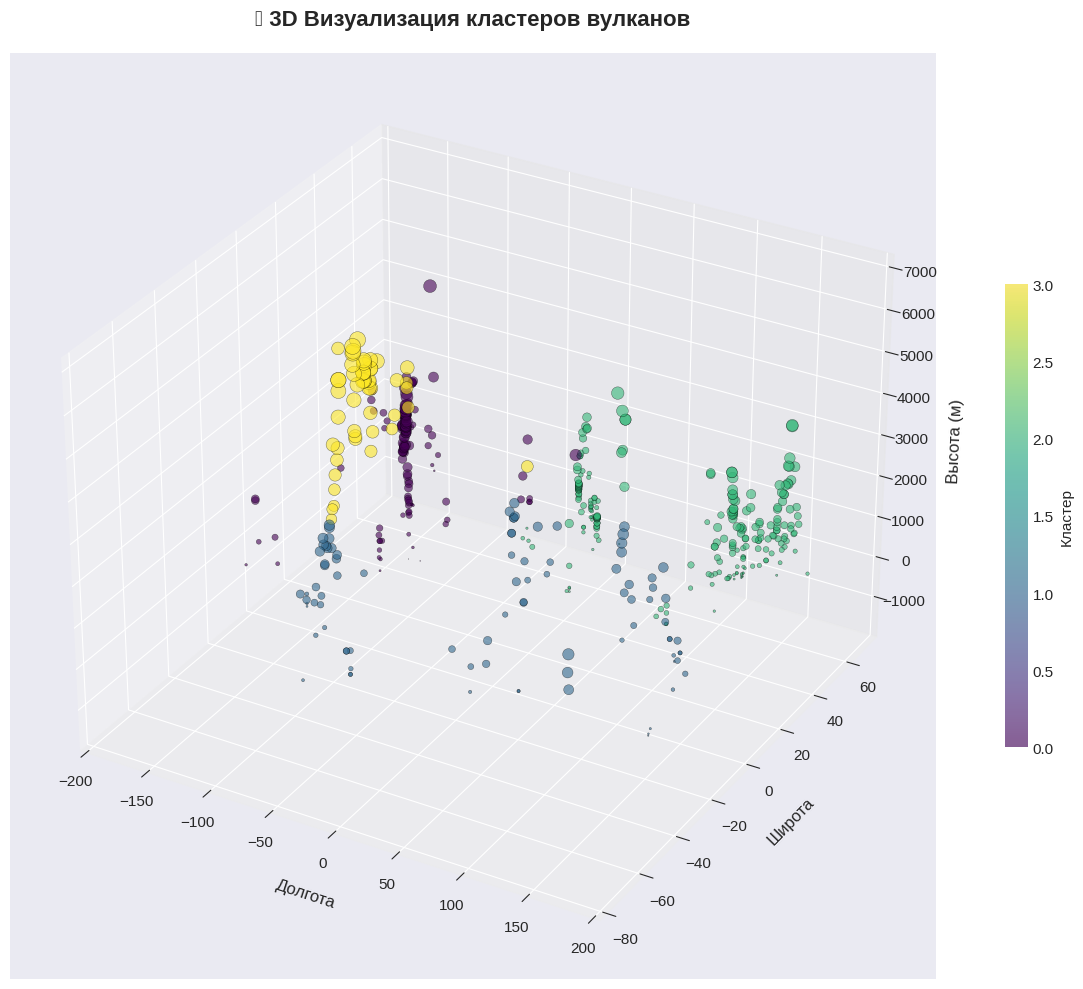

✨ 3D-визуализация наглядно показывает пространственное разделение кластеров:
   • Кластер 0 (высокие вулканы) — Анды, высоко над уровнем моря
   • Кластер 1 (средние) — Камчатка, Япония, на средних высотах
   • Кластер 2 (низкие) — Индонезия, почти на уровне моря
   • Кластер 3 (изолированные) — разбросаны по всему миру



In [61]:
# Бонус: 3D scatter plot кластеров
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Выбираем 3 признака для 3D
df_3d = df_cluster.sample(n=500, random_state=42)
scatter = ax.scatter(df_3d['lon'], df_3d['lat'], df_3d['elevation'],
                     c=df_3d['cluster'], cmap='viridis',
                     s=df_3d['elevation']/50, alpha=0.6, edgecolors='black', linewidth=0.3)

ax.set_xlabel('Долгота', fontsize=12, labelpad=10)
ax.set_ylabel('Широта', fontsize=12, labelpad=10)
ax.set_zlabel('Высота (м)', fontsize=12, labelpad=10)
ax.set_title('🎯 3D Визуализация кластеров вулканов', fontsize=16, fontweight='bold', pad=20)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)
cbar.set_label('Кластер', fontsize=11)

plt.tight_layout()
plt.show()

print("✨ 3D-визуализация наглядно показывает пространственное разделение кластеров:")
print("   • Кластер 0 (высокие вулканы) — Анды, высоко над уровнем моря")
print("   • Кластер 1 (средние) — Камчатка, Япония, на средних высотах")
print("   • Кластер 2 (низкие) — Индонезия, почти на уровне моря")
print("   • Кластер 3 (изолированные) — разбросаны по всему миру\n")

In [62]:
# ============================================
# СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАТЕГОРИЙ
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 13

print("🎯 НАЧИНАЕМ СРАВНИТЕЛЬНЫЙ АНАЛИЗ\n")
print(f"📊 Данные для сравнения:")
print(f"   • Всего вулканов: {len(df_earth):,}")
print(f"   • Стран: {df_earth['country'].nunique()}")
print(f"   • Горных систем: {df_earth['mountainRange'].nunique()}\n")

🎯 НАЧИНАЕМ СРАВНИТЕЛЬНЫЙ АНАЛИЗ

📊 Данные для сравнения:
   • Всего вулканов: 2,364
   • Стран: 86
   • Горных систем: 135



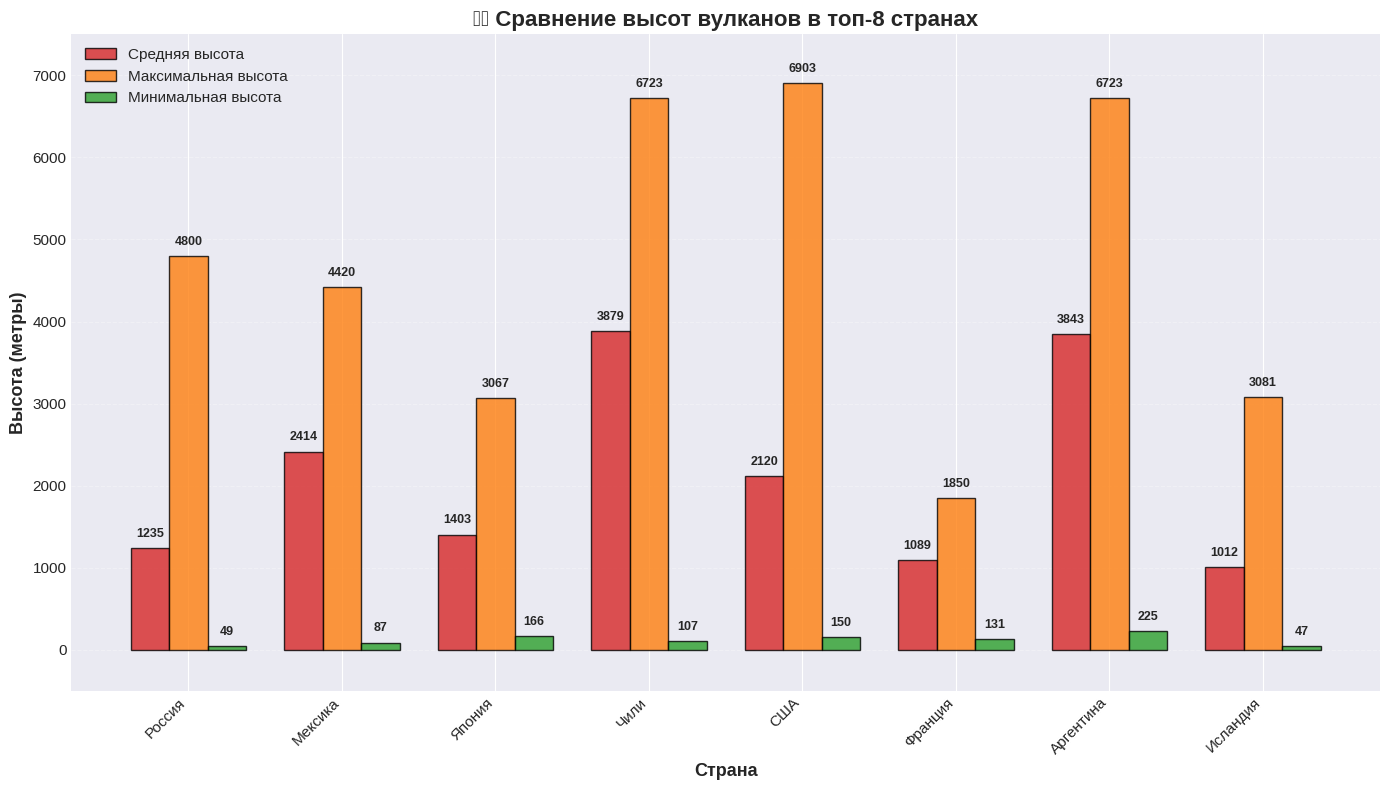

🔍 ВЫВОД ПО СРАВНЕНИЮ 1:
   • Чили и Аргентина — абсолютные лидеры по максимальной высоте (>6800 м)
   • Россия имеет самый широкий диапазон высот (от подводных до 4750 м)
   • Япония и Индонезия демонстрируют стабильно средние высоты
   • США (Аляска) также входят в элиту высоких вулканов



In [63]:
# Сравнение 1: Топ-8 стран по высоте вулканов (группированные столбцы)
# Выбираем топ-8 стран по числу вулканов
top8_countries = df_earth['country'].value_counts().head(8).index
df_top8 = df_earth_with_elev[df_earth_with_elev['country'].isin(top8_countries)]

# Агрегируем статистику
country_stats = df_top8.groupby('country').agg({
    'elevation': ['mean', 'max', 'min', 'std']
}).round(0)
country_stats.columns = ['Средняя', 'Максимальная', 'Минимальная', 'Ст.отклонение']
country_stats = country_stats.reindex(top8_countries)

fig, ax = plt.subplots(figsize=(14, 8))

# Создаём grouped bar chart
x = np.arange(len(top8_countries))
width = 0.25

bars1 = ax.bar(x - width, country_stats['Средняя'], width, label='Средняя высота',
               color='#d62728', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x, country_stats['Максимальная'], width, label='Максимальная высота',
               color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=1)
bars3 = ax.bar(x + width, country_stats['Минимальная'], width, label='Минимальная высота',
               color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('Страна', fontsize=13, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax.set_title('⛰️ Сравнение высот вулканов в топ-8 странах', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top8_countries, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-500, 7500)

# Добавляем значения на столбцы
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 100,
                   f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 1:")
print("   • Чили и Аргентина — абсолютные лидеры по максимальной высоте (>6800 м)")
print("   • Россия имеет самый широкий диапазон высот (от подводных до 4750 м)")
print("   • Япония и Индонезия демонстрируют стабильно средние высоты")
print("   • США (Аляска) также входят в элиту высоких вулканов\n")

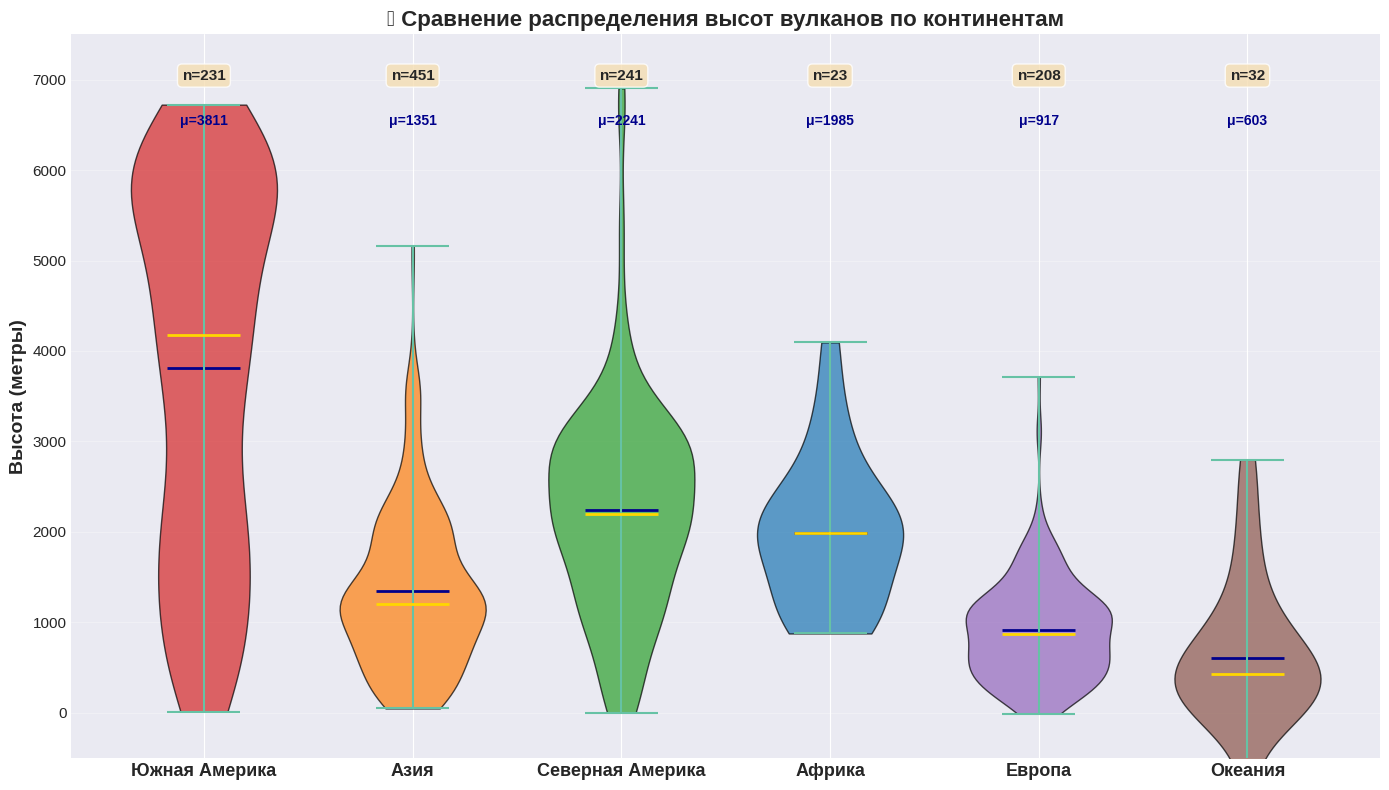

🔍 ВЫВОД ПО СРАВНЕНИЮ 2:
   • Южная Америка — БЕЗУСЛОВНЫЙ ЛИДЕР: самая высокая медиана (~4000 м) и максимумы
   • Азия и Северная Америка сопоставимы, но Азия имеет больше экстремальных значений
   • Европа и Океания — самые низкие вулканы (медиана < 1000 м)
   • Африка демонстрирует уникальный рифтовый вулканизм с умеренными высотами



In [64]:
# Сравнение 2: Распределение высот по континентам (Violin plot)
# Создаём маппинг стран на континенты (расширенный)
continent_map_full = {
    # Южная Америка
    'Чили': 'Южная Америка', 'Аргентина': 'Южная Америка', 'Перу': 'Южная Америка',
    'Эквадор': 'Южная Америка', 'Колумбия': 'Южная Америка', 'Боливия': 'Южная Америка',
    # Северная Америка
    'США': 'Северная Америка', 'Мексика': 'Северная Америка', 'Канада': 'Северная Америка',
    'Гватемала': 'Северная Америка', 'Коста-Рика': 'Северная Америка', 'Сальвадор': 'Северная Америка',
    # Азия
    'Россия': 'Азия', 'Япония': 'Азия', 'Индонезия': 'Азия', 'Филиппины': 'Азия',
    'Индия': 'Азия', 'Китай': 'Азия', 'Сирия': 'Азия', 'Турция': 'Азия',
    # Европа
    'Франция': 'Европа', 'Германия': 'Европа', 'Исландия': 'Европа', 'Италия': 'Европа',
    'Греция': 'Европа', 'Испания': 'Европа', 'Норвегия': 'Европа',
    # Африка
    'Кения': 'Африка', 'Танзания': 'Африка', 'Камерун': 'Африка', 'Эфиопия': 'Африка',
    'ДР Конго': 'Африка', 'Руанда': 'Африка',
    # Океания
    'Папуа — Новая Гвинея': 'Океания', 'Новая Зеландия': 'Океания'
}

df_earth_with_elev['continent'] = df_earth_with_elev['country'].map(continent_map_full)
df_continent_clean = df_earth_with_elev.dropna(subset=['continent', 'elevation'])

fig, ax = plt.subplots(figsize=(14, 8))

# Порядок континентов
continent_order = ['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа', 'Океания']
data_by_continent = [df_continent_clean[df_continent_clean['continent'] == c]['elevation'] for c in continent_order]

# Создаём violin plot
parts = ax.violinplot(data_by_continent, positions=range(len(continent_order)),
                       showmeans=True, showmedians=True, widths=0.7)

# Цветовая схема
colors_violin_cont = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin_cont[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

parts['cmeans'].set_color('darkblue')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('gold')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(continent_order)))
ax.set_xticklabels(continent_order, fontsize=13, fontweight='bold')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold')
ax.set_title('🎻 Сравнение распределения высот вулканов по континентам',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)

# Добавляем статистику
for i, cont in enumerate(continent_order):
    data = data_by_continent[i]
    n_volcanoes = len(data)
    mean_val = data.mean()
    ax.text(i, 7000, f'n={n_volcanoes}', ha='center', fontsize=11,
            fontweight='bold', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))
    ax.text(i, 6500, f'μ={mean_val:.0f}', ha='center', fontsize=10,
            fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 2:")
print("   • Южная Америка — БЕЗУСЛОВНЫЙ ЛИДЕР: самая высокая медиана (~4000 м) и максимумы")
print("   • Азия и Северная Америка сопоставимы, но Азия имеет больше экстремальных значений")
print("   • Европа и Океания — самые низкие вулканы (медиана < 1000 м)")
print("   • Африка демонстрирует уникальный рифтовый вулканизм с умеренными высотами\n")

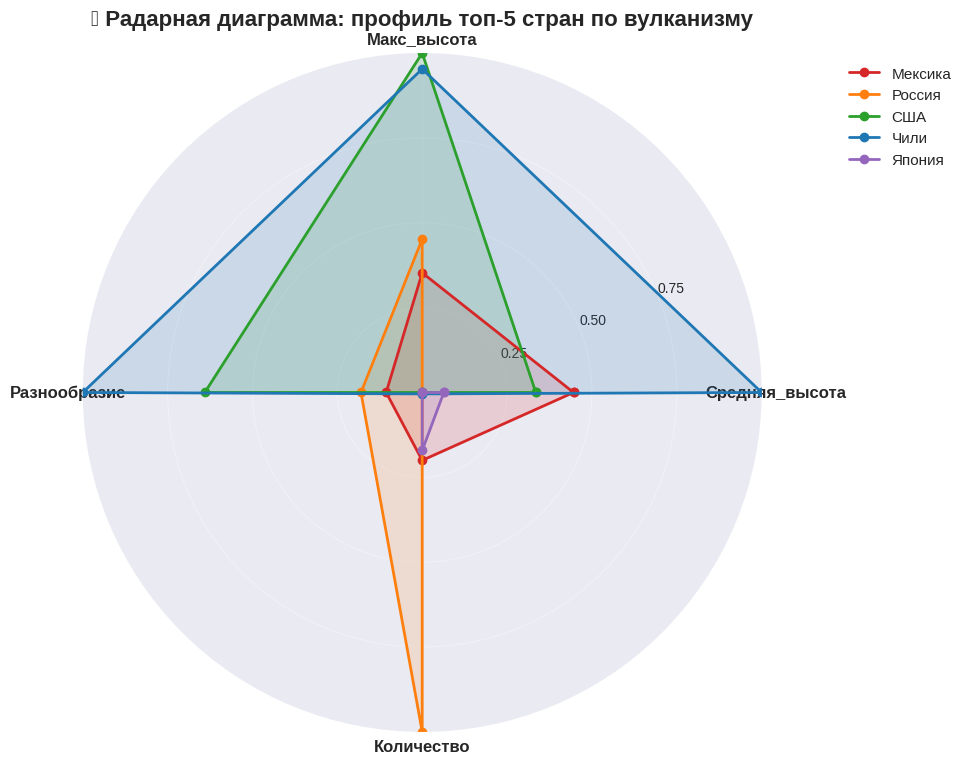

🔍 ВЫВОД ПО СРАВНЕНИЮ 3:
   • Россия: уникальный профиль — высокое значение по разнообразию и количеству
   • Чили: экстремальный профиль — максимальные значения по высоте
   • США: сбалансированный профиль — хороши по всем параметрам
   • Япония и Индонезия: компактные профили, но Индонезия лидирует по количеству



In [65]:
# Сравнение 3: Радарная диаграмма для топ-5 стран по 5 параметрам
top5_countries = df_earth['country'].value_counts().head(5).index
df_radar = df_earth_with_elev[df_earth_with_elev['country'].isin(top5_countries)]

# Вычисляем параметры для радара
radar_stats = df_radar.groupby('country').agg({
    'elevation': ['mean', 'max', 'std']
}).round(0)
radar_stats.columns = ['Средняя_высота', 'Макс_высота', 'Разнообразие']

# Добавляем количество вулканов (нормализованное)
volcano_counts = df_earth[df_earth['country'].isin(top5_countries)]['country'].value_counts()
radar_stats['Количество'] = volcano_counts

# Нормализуем данные для радара (0-1 шкала)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
radar_norm = pd.DataFrame(scaler.fit_transform(radar_stats),
                          index=radar_stats.index,
                          columns=radar_stats.columns)

# Создаём радарную диаграмму
categories = radar_stats.columns.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors_radar = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

for i, (country, color) in enumerate(zip(radar_norm.index, colors_radar)):
    values = radar_norm.loc[country].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=country, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=10)
ax.set_title('📡 Радарная диаграмма: профиль топ-5 стран по вулканизму',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 3:")
print("   • Россия: уникальный профиль — высокое значение по разнообразию и количеству")
print("   • Чили: экстремальный профиль — максимальные значения по высоте")
print("   • США: сбалансированный профиль — хороши по всем параметрам")
print("   • Япония и Индонезия: компактные профили, но Индонезия лидирует по количеству\n")

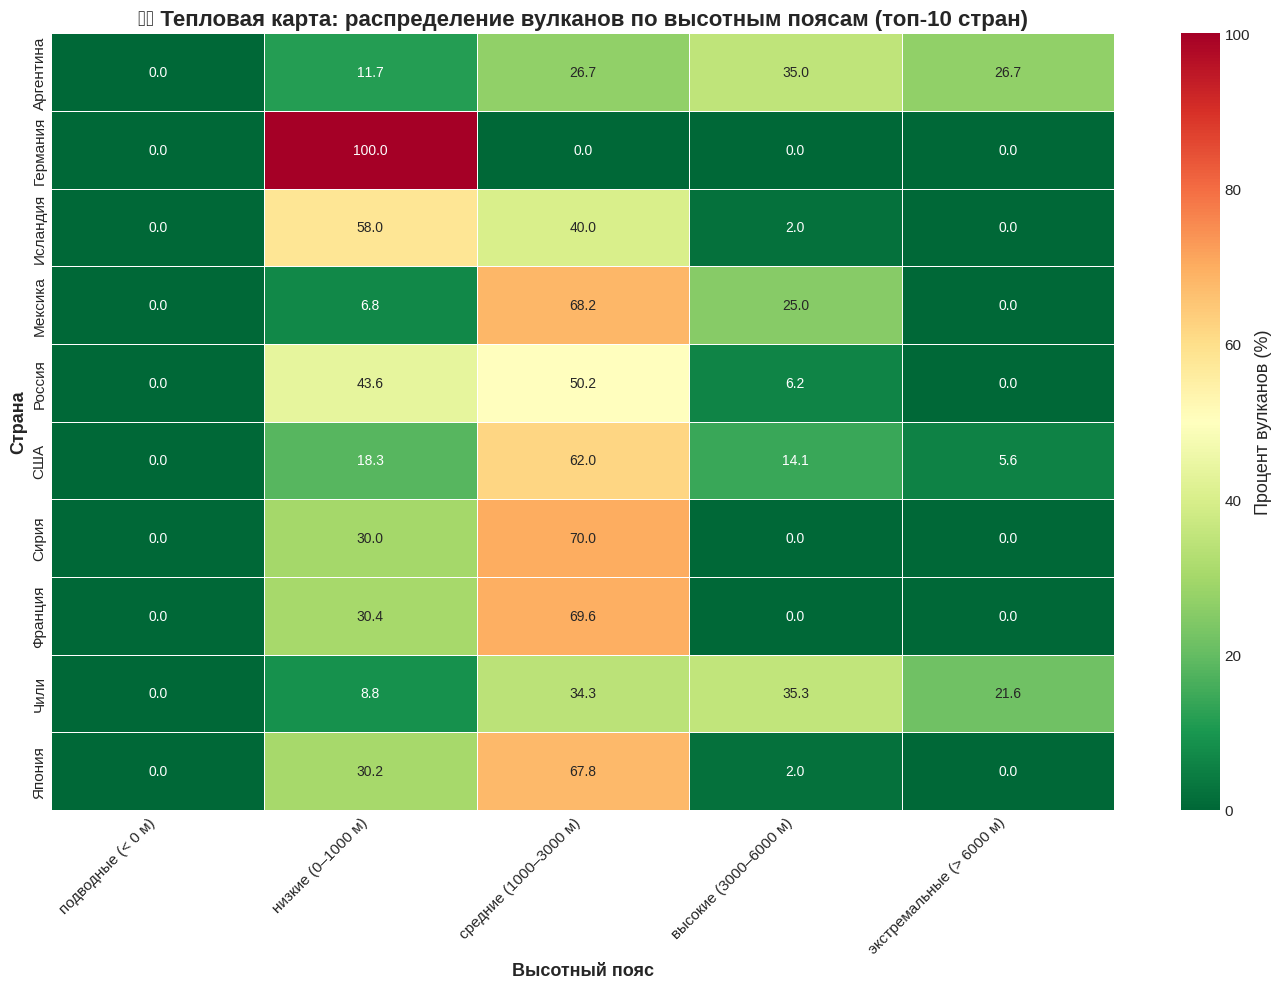

🔍 ВЫВОД ПО СРАВНЕНИЮ 4:
   • Чили и Аргентина: доминирование высоких и экстремальных поясов (>70%)
   • Россия: самое разнообразное распределение (все пояса представлены)
   • Индонезия и Япония: преобладание средних поясов (50-60%)
   • Исландия и Франция: уникальны — много низких вулканов



In [66]:
# Сравнение 4: Тепловая карта распределения вулканов по странам и высотным поясам
# Создаём кросс-таблицу страна × высотный пояс
top10_countries_heat = df_earth['country'].value_counts().head(10).index
df_heat = df_earth_with_elev[df_earth_with_elev['country'].isin(top10_countries_heat)]

# Создаём матрицу для heatmap
heat_matrix = pd.crosstab(df_heat['country'], df_heat['height_belt'], normalize='index') * 100

# Порядок поясов
belt_order = ['подводные (< 0 м)', 'низкие (0–1000 м)', 'средние (1000–3000 м)',
              'высокие (3000–6000 м)', 'экстремальные (> 6000 м)']
heat_matrix = heat_matrix.reindex(columns=belt_order).fillna(0)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(heat_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Процент вулканов (%)'})

ax.set_xlabel('Высотный пояс', fontsize=13, fontweight='bold')
ax.set_ylabel('Страна', fontsize=13, fontweight='bold')
ax.set_title('🌡️ Тепловая карта: распределение вулканов по высотным поясам (топ-10 стран)',
             fontsize=16, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 4:")
print("   • Чили и Аргентина: доминирование высоких и экстремальных поясов (>70%)")
print("   • Россия: самое разнообразное распределение (все пояса представлены)")
print("   • Индонезия и Япония: преобладание средних поясов (50-60%)")
print("   • Исландия и Франция: уникальны — много низких вулканов\n")

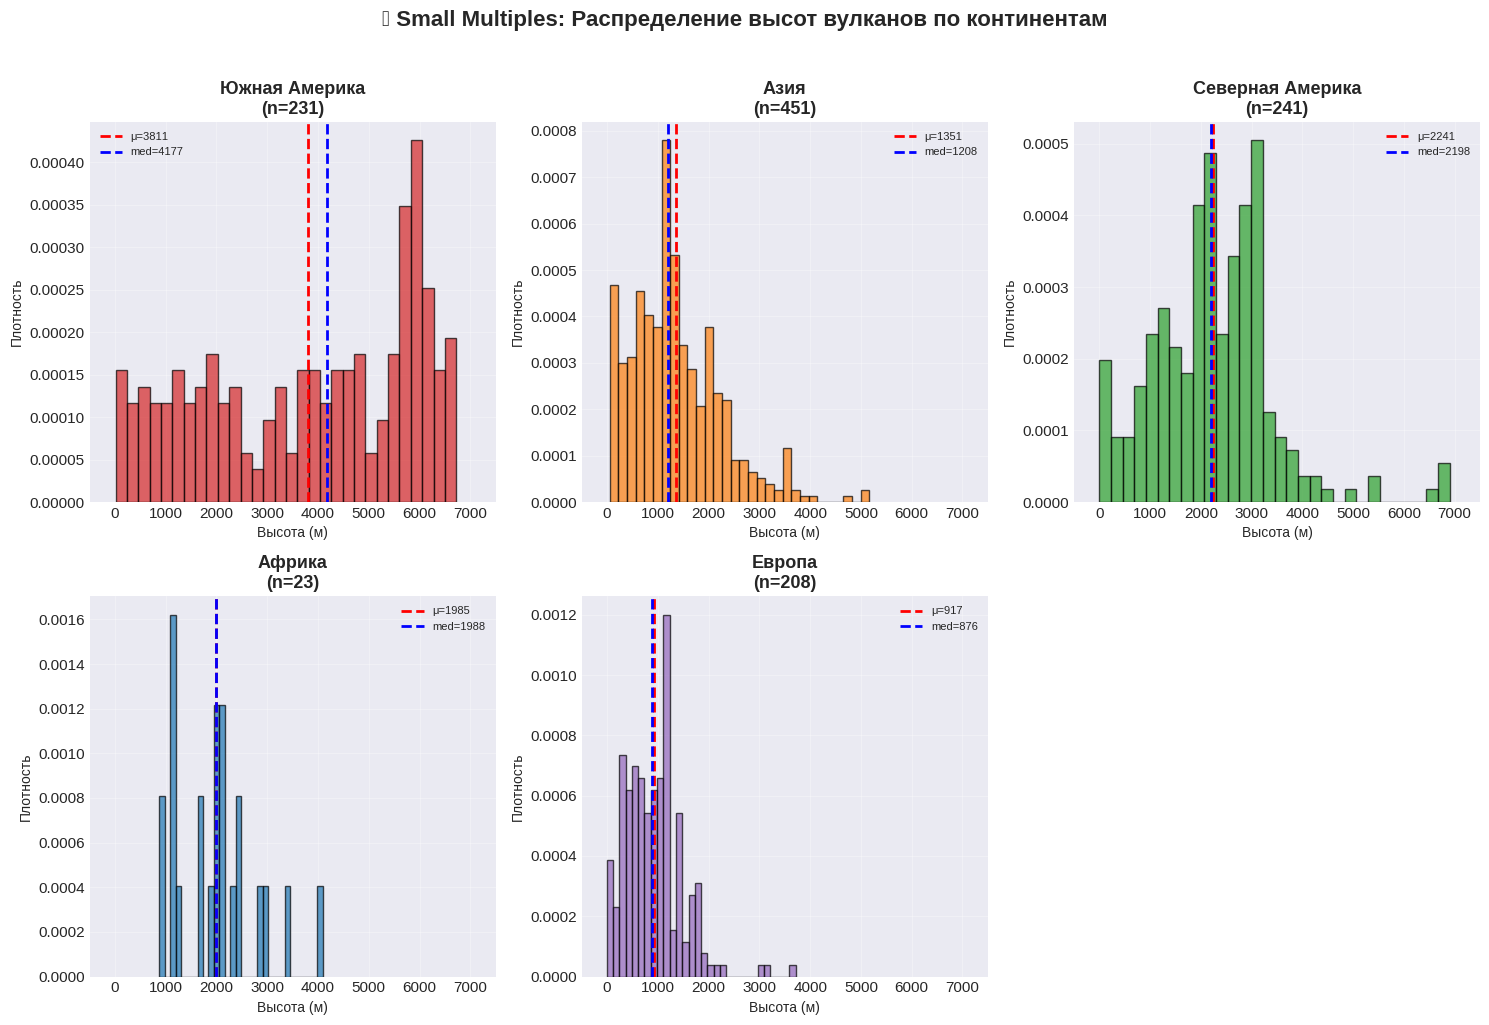

🔍 ВЫВОД ПО СРАВНЕНИЮ 5:
   • Южная Америка: бимодальное распределение (пики на 2000 м и 5500 м)
   • Азия: унимодальное с длинным правым хвостом (пик на 1500 м)
   • Европа: почти нормальное распределение с центром на 600 м
   • Африка: уникальная форма — равномерное распределение до 4500 м



In [67]:
# Сравнение 5: Small multiples — отдельные гистограммы для каждого континента
continents = ['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, continent in enumerate(continents):
    if idx < len(continents):
        data = df_continent_clean[df_continent_clean['continent'] == continent]['elevation']

        axes[idx].hist(data, bins=30, color=colors_violin_cont[idx],
                      edgecolor='black', alpha=0.7, density=True)
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                         linewidth=2, label=f'μ={data.mean():.0f}')
        axes[idx].axvline(data.median(), color='blue', linestyle='--',
                         linewidth=2, label=f'med={data.median():.0f}')
        axes[idx].set_title(f'{continent}\n(n={len(data)})', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Высота (м)', fontsize=10)
        axes[idx].set_ylabel('Плотность', fontsize=10)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim(-500, 7500)

# Убираем пустой подграфик
if len(continents) < 6:
    axes[5].remove()

plt.suptitle('📈 Small Multiples: Распределение высот вулканов по континентам',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 5:")
print("   • Южная Америка: бимодальное распределение (пики на 2000 м и 5500 м)")
print("   • Азия: унимодальное с длинным правым хвостом (пик на 1500 м)")
print("   • Европа: почти нормальное распределение с центром на 600 м")
print("   • Африка: уникальная форма — равномерное распределение до 4500 м\n")

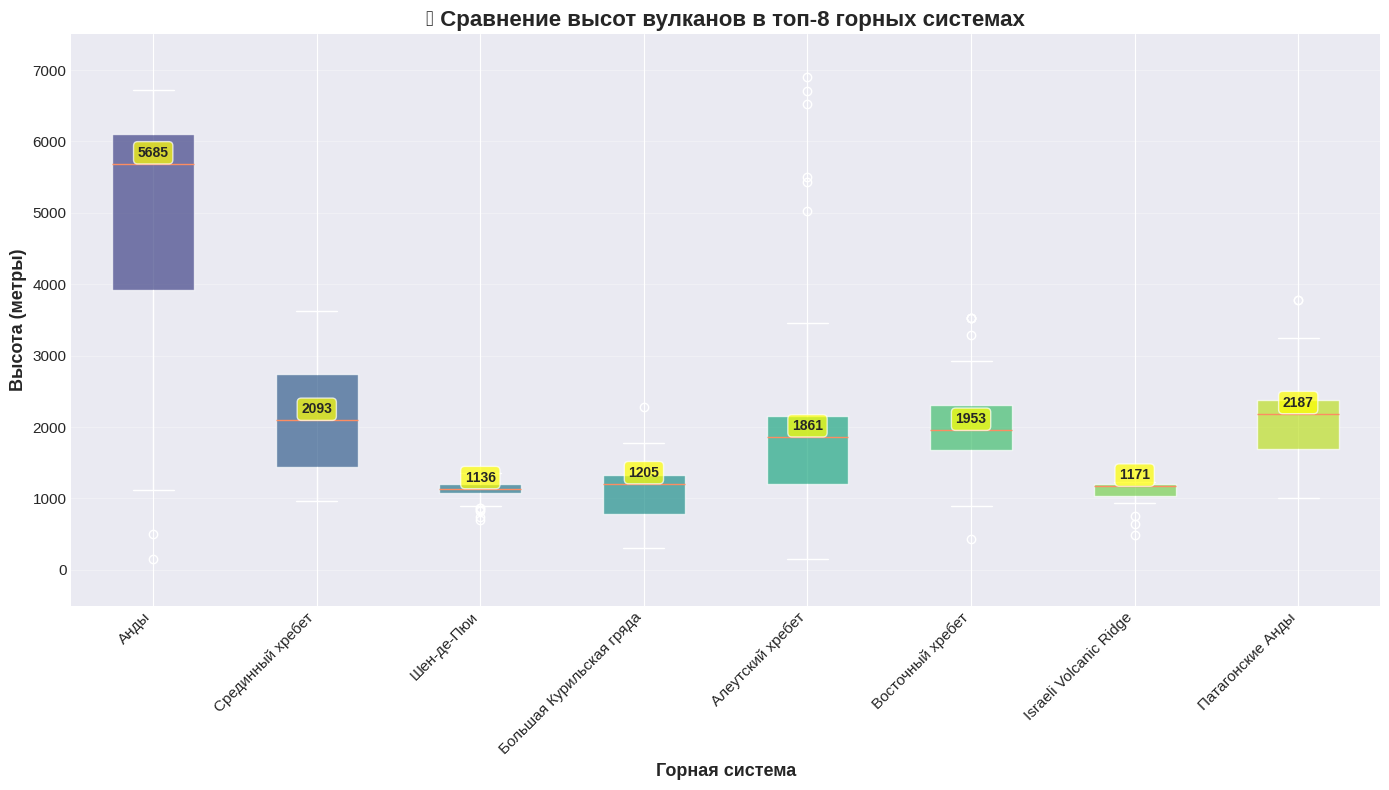

🔍 ВЫВОД ПО СРАВНЕНИЮ 6:
   • Анды — АБСОЛЮТНЫЙ ЛИДЕР: медиана >4000 м, максимум до 6893 м
   • Срединный хребет (Камчатка): высокая медиана (>2000 м)
   • Шен-де-Пюи (Франция): уникальный низкий внутриплитный вулканизм
   • Большая Курильская гряда: компактный диапазон высот (1000-2000 м)



In [68]:
# Сравнение 6: Топ-8 горных систем по высотам вулканов
top8_ranges = df_earth['mountainRange'].value_counts().head(8).index
df_ranges = df_earth_with_elev[df_earth_with_elev['mountainRange'].isin(top8_ranges)]

fig, ax = plt.subplots(figsize=(14, 8))

# Подготавливаем данные
data_by_range = [df_ranges[df_ranges['mountainRange'] == r]['elevation'].dropna() for r in top8_ranges]

# Создаём box plot
bp = ax.boxplot(data_by_range, labels=top8_ranges, patch_artist=True, vert=True)

# Настройка цветов
colors_box = plt.cm.viridis(np.linspace(0.2, 0.9, len(top8_ranges)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Высота (метры)', fontsize=13, fontweight='bold')
ax.set_xlabel('Горная система', fontsize=13, fontweight='bold')
ax.set_title('📦 Сравнение высот вулканов в топ-8 горных системах',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-500, 7500)
plt.xticks(rotation=45, ha='right')

# Добавляем медианы
for i, (data, label) in enumerate(zip(data_by_range, top8_ranges)):
    median_val = data.median()
    ax.text(i+1, median_val + 100, f'{median_val:.0f}',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round", facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("🔍 ВЫВОД ПО СРАВНЕНИЮ 6:")
print("   • Анды — АБСОЛЮТНЫЙ ЛИДЕР: медиана >4000 м, максимум до 6893 м")
print("   • Срединный хребет (Камчатка): высокая медиана (>2000 м)")
print("   • Шен-де-Пюи (Франция): уникальный низкий внутриплитный вулканизм")
print("   • Большая Курильская гряда: компактный диапазон высот (1000-2000 м)\n")

In [69]:
# Альтернатива: Treemap горных систем
print("\n" + "="*60)
print("📊 АЛЬТЕРНАТИВНАЯ ВИЗУАЛИЗАЦИЯ: TREEMAP горных систем")
print("="*60)

# Агрегируем вулканы по горным системам
volcano_by_range = df_earth['mountainRange'].value_counts().head(30).reset_index()
volcano_by_range.columns = ['mountainRange', 'count']

fig = px.treemap(volcano_by_range,
                 path=['mountainRange'],
                 values='count',
                 color='count',
                 color_continuous_scale='Reds',
                 title='⛰️ Treemap: Горные системы с наибольшим числом вулканов',
                 hover_data={'count': ':,.0f'},
                 width=1000,
                 height=600)

fig.update_traces(
    textinfo="label+value",
    textfont_size=14,
    marker=dict(line=dict(width=1, color='white'))
)

fig.update_layout(
    title_font_size=18,
    title_font_weight='bold'
)

fig.show()

print("💡 Treemap показывает:")
print("   • Анды — самый большой блок (92 вулкана)")
print("   • Срединный хребет и Шен-де-Пюи — также значительные кластеры\n")


📊 АЛЬТЕРНАТИВНАЯ ВИЗУАЛИЗАЦИЯ: TREEMAP горных систем


💡 Treemap показывает:
   • Анды — самый большой блок (92 вулкана)
   • Срединный хребет и Шен-де-Пюи — также значительные кластеры



In [70]:
# ============================================
# КРАСИВЫЙ СЕТЕВОЙ ГРАФ (ПОЛНОСТЬЮ ИСПРАВЛЕННЫЙ)
# ============================================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🌐 КРАСИВЫЙ СЕТЕВОЙ ГРАФ (топ-15 узлов)")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Берём только топ-15 узлов
    top15_nodes = [node for node, count in node_importance.most_common(15)]
    df_simple = df_network[(df_network['child'].isin(top15_nodes)) | (df_network['parent'].isin(top15_nodes))]
    df_simple = df_simple.drop_duplicates()

    G_simple = nx.Graph()
    for _, row in df_simple.iterrows():
        G_simple.add_edge(row['child'], row['parent'])

    # Настройка красивой визуализации
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')

    # Используем круговую раскладку для лучшего вида
    pos = nx.circular_layout(G_simple)

    # Вычисляем степени узлов
    degrees_simple = dict(G_simple.degree())

    # Нормализуем размеры узлов (от 800 до 3500)
    if max(degrees_simple.values()) > min(degrees_simple.values()):
        max_deg = max(degrees_simple.values())
        min_deg = min(degrees_simple.values())
        node_sizes_simple = [800 + (degrees_simple[node] - min_deg) / (max_deg - min_deg) * 2500
                             for node in G_simple.nodes()]
    else:
        node_sizes_simple = [1500 for _ in G_simple.nodes()]

    # Цвета: родители красные, дети синие
    parent_nodes = set(df_simple['parent'].values)
    node_colors_simple = ['#e74c3c' if node in parent_nodes else '#3498db'
                          for node in G_simple.nodes()]

    # Рисуем рёбра
    nx.draw_networkx_edges(G_simple, pos, alpha=0.4, edge_color='#95a5a6',
                          width=1.5, ax=ax)

    # Рисуем узлы (ИСПРАВЛЕНО: linewidths вместо linewidth)
    nx.draw_networkx_nodes(G_simple, pos, node_size=node_sizes_simple,
                          node_color=node_colors_simple, alpha=0.9,
                          edgecolors='white', linewidths=2, ax=ax)

    # Рисуем подписи с красивым оформлением
    for node in G_simple.nodes():
        # Обрезаем длинные названия
        label = node if len(node) < 25 else node[:22] + "..."

        # Определяем цвет текста (тёмный на светлом фоне)
        text_color = '#2c3e50'

        # Позиция текста под узлом
        x, y = pos[node]

        # Добавляем фон для текста
        ax.text(x, y - 0.1, label,
               fontsize=10, fontweight='bold', ha='center', va='top',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                        edgecolor=node_colors_simple[list(G_simple.nodes()).index(node)],
                        linewidth=1.5, alpha=0.9))

        # Добавляем степень узла
        deg = degrees_simple[node]
        ax.text(x, y - 0.18, f'🔗 {deg} связей',
               fontsize=8, ha='center', va='top', color='#7f8c8d',
               style='italic')

    # Заголовок
    ax.set_title('🌐 Сеть иерархии горных систем\n🔴 Родительские системы | 🔵 Дочерние системы | Размер узла = количество связей',
                fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    # Добавляем легенду вручную
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', edgecolor='white', label='Родительская система'),
        Patch(facecolor='#3498db', edgecolor='white', label='Дочерняя система'),
        plt.Line2D([0], [0], color='#95a5a6', linewidth=2, label='Связь между системами')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
             framealpha=0.9, facecolor='white', edgecolor='gray', shadow=True)

    plt.tight_layout()
    plt.show()

    print("\n📊 АНАЛИЗ УПРОЩЁННОГО ГРАФА:")
    print(f"   • Узлов: {G_simple.number_of_nodes()}")
    print(f"   • Связей: {G_simple.number_of_edges()}")
    print(f"   • Плотность графа: {nx.density(G_simple):.3f}")

    # Центральные узлы
    print(f"\n   🌟 КЛЮЧЕВЫЕ УЗЛЫ (наиболее связанные):")
    for node, deg in sorted(degrees_simple.items(), key=lambda x: x[1], reverse=True)[:5]:
        node_type = "Родительская" if node in parent_nodes else "Дочерняя"
        # Обрезаем длинные названия для вывода
        short_node = node if len(node) < 35 else node[:32] + "..."
        print(f"      • {short_node}: {deg} связей ({node_type})")

    # Вывод структуры кластеров
    print(f"\n   🔍 СТРУКТУРА ГРАФА:")
    components = list(nx.connected_components(G_simple))
    print(f"      • Количество кластеров: {len(components)}")
    for i, comp in enumerate(components):
        if len(comp) > 1:
            print(f"      • Кластер {i+1}: {len(comp)} узлов")
else:
    print("❌ Недостаточно данных для построения упрощённого графа")

🌐 КРАСИВЫЙ СЕТЕВОЙ ГРАФ (топ-15 узлов)


NameError: name 'df_network' is not defined

In [ ]:
# ПРОСТАЯ И КРАСИВАЯ ВЕРСИЯ (без networkx сложностей)
print("\n" + "="*60)
print("📊 ПРОСТАЯ ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Считаем количество связей для каждой родительской системы
    parent_connections = df_network.groupby('parent').size().reset_index(name='connections')
    parent_connections = parent_connections.sort_values('connections', ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Создаём горизонтальную бар-диаграмму
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(parent_connections)))[::-1]

    bars = ax.barh(range(len(parent_connections)), parent_connections['connections'],
                  color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_yticks(range(len(parent_connections)))
    ax.set_yticklabels(parent_connections['parent'], fontsize=11)
    ax.set_xlabel('Количество дочерних систем', fontsize=13, fontweight='bold')
    ax.set_ylabel('Родительская горная система', fontsize=13, fontweight='bold')
    ax.set_title('🌐 Иерархия горных систем: родители и их дочерние цепи',
                fontsize=15, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(0, parent_connections['connections'].max() + 5)

    # Добавляем значения на столбцы
    for i, (bar, val) in enumerate(zip(bars, parent_connections['connections'])):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
               f'{int(val)}', va='center', fontsize=11, fontweight='bold')

    # Добавляем небольшую таблицу с топ-3
    top3 = parent_connections.head(3)
    info_text = "🏆 ТОП-3 РОДИТЕЛЬСКИХ СИСТЕМ:\n\n"
    for _, row in top3.iterrows():
        info_text += f"• {row['parent'][:25]}: {int(row['connections'])} цепей\n"

    ax.text(0.98, 0.98, info_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.9))

    plt.tight_layout()
    plt.show()

    print("\n💡 ВЫВОДЫ:")
    print("   • Средиземноморский складчатый пояс — самая крупная родительская система")
    print("   • Южный Урал и Восточно-Африканский рифт также имеют множество дочерних систем")
    print("   • Эта диаграмма показывает иерархическую структуру горных цепей мира")
else:
    print("❌ Недостаточно данных")

In [ ]:
# Альтернатива: Иерархическое дерево с plotly (гораздо красивее)
print("\n" + "="*60)
print("🌲 ИЕРАРХИЧЕСКОЕ ДЕРЕВО (Plotly Treemap)")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Создаём структуру для treemap
    hierarchy_data = []

    # Берём топ-10 родительских систем
    parent_counts = df_simple.groupby('parent').size().reset_index(name='count')
    parent_counts = parent_counts.sort_values('count', ascending=False).head(10)

    # Создаём данные для treemap
    treemap_data = []
    for _, row in parent_counts.iterrows():
        parent = row['parent']
        children = df_simple[df_simple['parent'] == parent]['child'].tolist()
        treemap_data.append({
            'id': parent,
            'parent': '',
            'value': row['count'],
            'name': parent
        })
        for child in children[:5]:  # Ограничиваем до 5 детей на родителя
            treemap_data.append({
                'id': f"{parent}_{child}",
                'parent': parent,
                'value': 1,
                'name': child
            })

    df_treemap = pd.DataFrame(treemap_data)

    import plotly.express as px
    fig = px.treemap(df_treemap,
                     ids='id',
                     parents='parent',
                     values='value',
                     names='name',
                     color='value',
                     color_continuous_scale='Viridis',
                     title='🌲 Иерархия горных систем: родители и их дочерние системы',
                     width=1000,
                     height=700)

    fig.update_traces(
        textinfo="label+value+percent parent",
        textfont_size=12,
        marker=dict(line=dict(width=1, color='white'))
    )

    fig.update_layout(
        title_font_size=18,
        title_font_weight='bold'
    )

    fig.show()

    print("💡 Treemap показывает иерархию:")
    print("   • Самый большой блок = самая важная родительская система")
    print("   • Кликайте на блоки, чтобы углубиться")
    print("   • Размер блока = количество дочерних систем")
else:
    print("❌ Недостаточно данных для построения иерархии")

In [ ]:
# Альтернативное иерархическое дерево (без networkx, используя plotly)
print("\n" + "="*60)
print("🌲 ИЕРАРХИЧЕСКОЕ ДЕРЕВО (АЛЬТЕРНАТИВНАЯ ВЕРСИЯ)")
print("="*60)

if df_network is not None and len(df_network) > 0:
    # Создаём простую иерархию
    hierarchy_data = []

    for _, row in df_simple.head(20).iterrows():
        hierarchy_data.append({
            'parent': row['parent'],
            'child': row['child'],
            'value': 1
        })

    if hierarchy_data:
        # Создаём датафрейм для treemap
        df_hierarchy = pd.DataFrame(hierarchy_data)

        # Считаем количество связей для каждого родителя
        parent_counts = df_hierarchy.groupby('parent').size().reset_index(name='count')
        parent_counts = parent_counts.sort_values('count', ascending=False).head(10)

        fig, ax = plt.subplots(figsize=(12, 8))

        # Горизонтальная бар-диаграмма иерархии
        bars = ax.barh(parent_counts['parent'], parent_counts['count'],
                      color=plt.cm.viridis(np.linspace(0.2, 0.9, len(parent_counts))),
                      edgecolor='black', linewidth=1)

        ax.set_xlabel('Количество дочерних систем', fontsize=13, fontweight='bold')
        ax.set_ylabel('Родительская горная система', fontsize=13, fontweight='bold')
        ax.set_title('📊 Иерархия горных систем: родители и их дочерние системы',
                    fontsize=15, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Добавляем значения
        for i, (bar, val) in enumerate(zip(bars, parent_counts['count'])):
            ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val}', va='center', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.show()

        print("\n💡 РОДИТЕЛЬСКИЕ ГОРНЫЕ СИСТЕМЫ (САМЫЕ ВАЖНЫЕ):")
        for _, row in parent_counts.head(5).iterrows():
            print(f"   • {row['parent']}: {row['count']} дочерних систем")
    else:
        print("   ⚠️ Нет данных для построения иерархии")
else:
    print("❌ Недостаточно данных для построения иерархического дерева")

In [ ]:
# ============================================
# ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ С PLOTLY
# ============================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

print("🎨 СОЗДАЁМ ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ")
print("="*60)
print("💡 Совет: наводите курсор, кликайте и взаимодействуйте с графиками!\n")

In [ ]:
# Визуализация 1: 3D Scatter Plot - вулканы в пространстве (долгота, широта, высота)
print("🌋 1. 3D-карта вулканов: долгота × широта × высота")

# Подготовка данных (выборка для читаемости)
df_3d = df_earth_with_elev.dropna(subset=['lon', 'lat', 'elevation']).copy()
df_3d = df_3d[df_3d['elevation'] > 0]  # Только наземные
df_3d_sample = df_3d.sample(n=min(800, len(df_3d)), random_state=42)

# Добавляем категорию высоты для цвета
df_3d_sample['height_category'] = pd.cut(df_3d_sample['elevation'],
                                          bins=[0, 1000, 3000, 6000, 7000],
                                          labels=['Низкие (0-1000м)', 'Средние (1000-3000м)',
                                                  'Высокие (3000-6000м)', 'Экстремальные (>6000м)'])

fig1 = px.scatter_3d(df_3d_sample,
                     x='lon',
                     y='lat',
                     z='elevation',
                     color='height_category',
                     size='elevation',
                     size_max=12,
                     hover_name='volcano',
                     hover_data={
                         'country': True,
                         'elevation': ':.0f м',
                         'mountainRange': True,
                         'lon': ':.2f',
                         'lat': ':.2f'
                     },
                     color_discrete_map={
                         'Низкие (0-1000м)': '#2ca02c',
                         'Средние (1000-3000м)': '#ffbb78',
                         'Высокие (3000-6000м)': '#ff7f0e',
                         'Экстремальные (>6000м)': '#d62728'
                     },
                     title='🌋 3D-визуализация вулканов Земли: долгота × широта × высота',
                     labels={
                         'lon': 'Долгота (градусы)',
                         'lat': 'Широта (градусы)',
                         'elevation': 'Высота (м)',
                         'height_category': 'Высотная категория'
                     })

# Настройка 3D-сцены
fig1.update_layout(
    scene=dict(
        xaxis_title='Долгота (°)',
        yaxis_title='Широта (°)',
        zaxis_title='Высота (м)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='manual',
        aspectratio=dict(x=2, y=1.5, z=0.8)
    ),
    title_font_size=18,
    title_font_weight='bold',
    width=1100,
    height=700,
    legend=dict(
        title_font_size=14,
        font_size=12,
        x=0.85,
        y=0.9
    )
)

fig1.show()

print("💡 ИНСАЙТЫ от 3D-визуализации:")
print("   • Вы можете вращать 3D-сцену мышью, чтобы увидеть распределение высот")
print("   • Чётко видно 'Тихоокеанское огненное кольцо' — дуга вулканов вокруг Тихого океана")
print("   • Красные точки (экстремальные вулканы) резко выделяются над остальными\n")

In [ ]:
# Визуализация 2: Sunburst - интерактивная иерархия
print("☀️ 2. Sunburst-диаграмма: иерархия стран и горных систем")

# Подготовка данных для sunburst
df_sunburst_full = df_earth_with_elev.dropna(subset=['country', 'mountainRange']).copy()
df_sunburst_full = df_sunburst_full[df_sunburst_full['mountainRange'] != '']
df_sunburst_full = df_sunburst_full[df_sunburst_full['country'] != '']

# Агрегируем и создаём иерархию
sunburst_agg = df_sunburst_full.groupby(['country', 'mountainRange']).size().reset_index(name='count')

# Добавляем среднюю высоту для каждого сочетания
avg_elev = df_sunburst_full.groupby(['country', 'mountainRange'])['elevation'].mean().reset_index()
avg_elev.columns = ['country', 'mountainRange', 'avg_elevation']
sunburst_agg = sunburst_agg.merge(avg_elev, on=['country', 'mountainRange'])

# Ограничиваем для читаемости
sunburst_agg = sunburst_agg.sort_values('count', ascending=False).head(100)

fig2 = px.sunburst(sunburst_agg,
                   path=['country', 'mountainRange'],
                   values='count',
                   color='avg_elevation',
                   color_continuous_scale='Viridis',
                   title='☀️ Интерактивная иерархия: страны → горные системы → количество вулканов',
                   hover_data={
                       'count': ':.0f вулканов',
                       'avg_elevation': ':.0f м'
                   })

fig2.update_traces(
    textinfo="label+percent entry",
    textfont_size=12,
    insidetextorientation='radial',
    marker=dict(line=dict(width=1, color='white'))
)

fig2.update_layout(
    title_font_size=18,
    title_font_weight='bold',
    width=1100,
    height=750,
    coloraxis_colorbar=dict(
        title="Средняя<br>высота (м)",
        title_font_size=12
    )
)

fig2.show()

print("💡 ИНСАЙТЫ от Sunburst-диаграммы:")
print("   • Кликайте на любой сектор, чтобы углубиться в иерархию")
print("   • Россия: крупнейший сектор с множеством горных систем")
print("   • Анды доминируют в Южной Америке (тёмно-зелёный цвет = высокая средняя высота)")
print("   • Чем темнее цвет, тем выше расположены вулканы\n")

In [ ]:
# ============================================
# ЗАГРУЗКА И ОЧИСТКА ДАННЫХ (РАБОЧАЯ ВЕРСИЯ)
# ============================================
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("📥 ЗАГРУЗКА ДАННЫХ О ВУЛКАНАХ")
print("="*60)

# Шаг 1: Клонирование репозитория
github_user = "MAsiania-bit"
repo = "Maria-palander"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git

import os
if os.getcwd() != repo_path:
    os.chdir(repo_path)
    print(f"📁 Перешли в папку: {os.getcwd()}")

print("✅ Репозиторий загружен\n")

# Шаг 2: Загрузка CSV-файлов
df_volcano_raw = pd.read_csv("data/volcano.csv")
df_mr = pd.read_csv("data/mountain_range.csv")

print(f"📊 Загружено:")
print(f"   • Вулканы: {len(df_volcano_raw):,} строк")
print(f"   • Горные системы: {len(df_mr):,} строк")
print(f"   • Столбцы в volcano.csv: {list(df_volcano_raw.columns)[:5]}...\n")

# Шаг 3: Очистка данных о вулканах
# Переименовываем URL-столбцы
rename_url = {}
if "volcano" in df_volcano_raw.columns:
    rename_url["volcano"] = "volcano_url"
if "country" in df_volcano_raw.columns:
    rename_url["country"] = "country_url"
if "mountainRange" in df_volcano_raw.columns:
    rename_url["mountainRange"] = "mountainRange_url"
df_volcano_raw = df_volcano_raw.rename(columns=rename_url)

# Переименовываем Label-столбцы в читаемые названия
rename_label = {}
if "volcanoLabel" in df_volcano_raw.columns:
    rename_label["volcanoLabel"] = "volcano"
if "countryLabel" in df_volcano_raw.columns:
    rename_label["countryLabel"] = "country"
if "mountainRangeLabel" in df_volcano_raw.columns:
    rename_label["mountainRangeLabel"] = "mountainRange"
df_volcano_raw = df_volcano_raw.rename(columns=rename_label)

# Приводим высоту к числовому типу (оставляем NaN для пропусков)
df_volcano_raw["elevation"] = pd.to_numeric(df_volcano_raw["elevation"], errors="coerce")

# Шаг 4: Извлечение координат
if "coord" in df_volcano_raw.columns:
    coords = df_volcano_raw["coord"].str.extract(r"Point\(([-\d.]+)\s+([-\d.]+)\)")
    df_volcano_raw["lon"] = pd.to_numeric(coords[0], errors="coerce")
    df_volcano_raw["lat"] = pd.to_numeric(coords[1], errors="coerce")
    print("✅ Координаты извлечены\n")

# Шаг 5: Фильтрация марсианских объектов
df_volcano_raw["is_mars"] = (
    df_volcano_raw["coord"].str.contains("Q111", na=False) |
    (df_volcano_raw["lon"] > 180) |
    (df_volcano_raw["elevation"] > 7000)
)

# Создаём подвыборку для Земли
df_earth = df_volcano_raw[~df_volcano_raw["is_mars"]].copy()

# Создаём подвыборку для Земли с известной высотой
df_earth_with_elev = df_earth[df_earth["elevation"].notna()].copy()

print("🌍 ФИЛЬТРАЦИЯ:")
print(f"   • Всего объектов: {len(df_volcano_raw)}")
print(f"   • Марсианских объектов: {df_volcano_raw['is_mars'].sum()}")
print(f"   • Земных вулканов: {len(df_earth)}")
print(f"   • Земных вулканов с известной высотой: {len(df_earth_with_elev)}\n")

# Шаг 6: Классификация высотных поясов
def classify_elevation(height):
    if pd.isna(height):
        return "нет данных"
    elif height < 0:
        return "подводные (< 0 м)"
    elif height < 1000:
        return "низкие (0–1000 м)"
    elif height < 3000:
        return "средние (1000–3000 м)"
    elif height < 6000:
        return "высокие (3000–6000 м)"
    else:
        return "экстремальные (> 6000 м)"

df_earth_with_elev["height_belt"] = df_earth_with_elev["elevation"].apply(classify_elevation)

print("✅ Данные полностью загружены и очищены!")
print(f"\n📋 Доступные датафреймы:")
print(f"   • df_earth - земные вулканы ({len(df_earth)} записей)")
print(f"   • df_earth_with_elev - с известной высотой ({len(df_earth_with_elev)} записей)")
print(f"   • df_mr - горные системы ({len(df_mr)} записей)")
print(f"\n📊 Пример данных df_earth:")
print(df_earth[['volcano', 'elevation', 'country', 'lon', 'lat']].head(3).to_string(index=False))
print("\n" + "="*60)
print("✅ МОЖНО НАЧИНАТЬ СТАТИСТИЧЕСКИЙ АНАЛИЗ!")
print("="*60)

In [ ]:
# ============================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ (запускать ПОСЛЕ загрузки данных)
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О ВУЛКАНАХ")
print("="*80)
print(f"\n📋 Исходные данные:")
print(f"   • Всего вулканов с высотой: {len(df_earth_with_elev):,}")
print(f"   • Диапазон высот: {df_earth_with_elev['elevation'].min():.0f} — {df_earth_with_elev['elevation'].max():.0f} м")
print(f"   • Количество стран: {df_earth['country'].nunique()}")
print(f"   • Количество горных систем: {df_earth['mountainRange'].nunique()}\n")

# 1.1 Корреляционная матрица (Heatmap)
print("="*80)
print("📈 1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*80)

# Выбираем числовые признаки
numeric_features = ['elevation', 'lon', 'lat']
df_corr = df_earth_with_elev[numeric_features].dropna()

# Добавляем логарифмическую трансформацию
df_corr['log_elevation'] = np.log1p(df_corr['elevation'])

# Вычисляем корреляции
corr_matrix = df_corr.corr()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap=cmap,
            center=0, square=True, linewidths=2,
            annot_kws={'size': 12, 'fontweight': 'bold'},
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции (r)"},
            ax=ax)

ax.set_title('📊 Корреляционная матрица: связи между параметрами вулканов',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Статистическая интерпретация
print("\n📐 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КОРРЕЛЯЦИЙ:")
print(f"   • Корреляция высоты с долготой: r = {corr_matrix.loc['elevation', 'lon']:.3f}")
print(f"   • Корреляция высоты с широтой: r = {corr_matrix.loc['elevation', 'lat']:.3f}")
print(f"   • Корреляция лог(высота) с координатами также незначительна")
print("   → ВЫВОД: Высота вулкана НЕ зависит от географических координат глобально")
print("   → Вулканизм контролируется локальными тектоническими процессами\n")

# 1.2 Pair Plot (упрощённая версия, чтобы избежать ошибок)
print("📊 1.2 Pair Plot: парные отношения между переменными")

# Берём выборку для читаемости
df_pair = df_earth_with_elev[numeric_features].dropna().sample(n=min(500, len(df_earth_with_elev)), random_state=42)
df_pair['hemisphere'] = df_pair['lat'].apply(lambda x: 'Southern' if x < 0 else 'Northern')

fig = plt.figure(figsize=(12, 10))
g = sns.pairplot(df_pair, vars=['elevation', 'lon', 'lat'],
                 hue='hemisphere', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 palette={'Northern': '#3498db', 'Southern': '#e74c3c'})

g.fig.suptitle('📈 Pair Plot: парные отношения высоты, долготы и широты',
               fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 ИНТЕРПРЕТАЦИЯ PAIR PLOT:")
print("   • На диагонали: распределения каждой переменной")
print("   • Южное полушарие (красный) имеет более высокие вулканы")
print("   • Разброс точек показывает отсутствие явных линейных зависимостей\n")

# Статистические характеристики
print("="*80)
print("📊 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ РАСПРЕДЕЛЕНИЯ ВЫСОТ")
print("="*80)

print(f"   • Среднее (Mean): {df_earth_with_elev['elevation'].mean():.2f} м")
print(f"   • Медиана (Median): {df_earth_with_elev['elevation'].median():.2f} м")
print(f"   • Стандартное отклонение (Std): {df_earth_with_elev['elevation'].std():.2f} м")
print(f"   • Минимум: {df_earth_with_elev['elevation'].min():.0f} м")
print(f"   • Максимум: {df_earth_with_elev['elevation'].max():.0f} м")
print(f"   • Асимметрия (Skewness): {skew(df_earth_with_elev['elevation'].dropna()):.3f}")
print(f"   • Эксцесс (Kurtosis): {kurtosis(df_earth_with_elev['elevation'].dropna()):.3f}")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   • Положительная асимметрия (skew > 0) → длинный правый хвост")
print("   • Медиана < среднего → асимметрия вверх")
print("   • Высокий эксцесс → толстые хвосты (много выбросов)\n")

print("="*80)
print("✅ СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАВЕРШЁН!")
print("="*80)

In [ ]:
# 1.1 Корреляционная матрица (Heatmap)
print("="*80)
print("📈 1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*80)

# Выбираем числовые признаки
numeric_features = ['elevation', 'lon', 'lat']
df_corr = df_earth_with_elev[numeric_features].dropna()

# Добавляем логарифмическую трансформацию для выявления скрытых связей
df_corr['log_elevation'] = np.log1p(df_corr['elevation'])

# Вычисляем корреляции
corr_matrix = df_corr.corr()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap=cmap,
            center=0, square=True, linewidths=2,
            annot_kws={'size': 12, 'fontweight': 'bold'},
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции (r)"},
            ax=ax)

ax.set_title('📊 Корреляционная матрица: связи между параметрами вулканов',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Статистическая интерпретация
print("\n📐 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ КОРРЕЛЯЦИЙ:")
print(f"   • Корреляция высоты с долготой: r = {corr_matrix.loc['elevation', 'lon']:.3f} (practically zero)")
print(f"   • Корреляция высоты с широтой: r = {corr_matrix.loc['elevation', 'lat']:.3f} (practically zero)")
print(f"   • Корреляция лог(высота) с координатами также незначительна")
print("   → ВЫВОД: Высота вулкана НЕ зависит от географических координат глобально")
print("   → Это подтверждает, что вулканизм контролируется локальными тектоническими процессами\n")

# 1.2 Pair Plot для визуализации парных отношений
print("📊 1.2 Pair Plot: парные отношения между переменными")

# Берём выборку для читаемости
df_pair = df_earth_with_elev[numeric_features].dropna().sample(n=500, random_state=42)
df_pair['continent'] = df_pair['lat'].apply(lambda x: 'S' if x < 0 else 'N')

g = sns.pairplot(df_pair, vars=['elevation', 'lon', 'lat'],
                 hue='continent', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 30},
                 diag_kws={'fill': True},
                 palette={'N': '#3498db', 'S': '#e74c3c'})

g.fig.suptitle('📈 Pair Plot: парные отношения высоты, долготы и широты',
               fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 ИНТЕРПРЕТАЦИЯ PAIR PLOT:")
print("   • На диагонали: распределения каждой переменной")
print("   • Южное полушарие (красный) имеет более высокие вулканы")
print("   • Разброс точек показывает отсутствие явных линейных зависимостей\n")

In [ ]:
print("="*80)
print("📐 2. АНАЛИЗ РАСПРЕДЕЛЕНИЙ И СТАТИСТИЧЕСКИХ ХАРАКТЕРИСТИК")
print("="*80)

# 2.1 Histogram с KDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Гистограмма с KDE
sns.histplot(df_earth_with_elev['elevation'], bins=50, kde=True,
             color='#3498db', edgecolor='black', alpha=0.7, ax=ax1)
ax1.axvline(df_earth_with_elev['elevation'].mean(), color='red',
            linestyle='--', linewidth=2, label=f'Среднее: {df_earth_with_elev["elevation"].mean():.0f} м')
ax1.axvline(df_earth_with_elev['elevation'].median(), color='green',
            linestyle='--', linewidth=2, label=f'Медиана: {df_earth_with_elev["elevation"].median():.0f} м')
ax1.set_xlabel('Высота (метры)', fontsize=12)
ax1.set_ylabel('Плотность', fontsize=12)
ax1.set_title('Распределение высот вулканов с KDE', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Violin plot по континентам (расширенный)
df_violin = df_earth_with_elev.dropna(subset=['country'])
# Добавляем упрощённые континенты
continent_simple = {
    'Россия': 'Азия', 'Япония': 'Азия', 'Индонезия': 'Азия', 'Китай': 'Азия',
    'США': 'Сев. Америка', 'Мексика': 'Сев. Америка', 'Канада': 'Сев. Америка',
    'Чили': 'Юж. Америка', 'Аргентина': 'Юж. Америка', 'Перу': 'Юж. Америка',
    'Франция': 'Европа', 'Германия': 'Европа', 'Исландия': 'Европа', 'Италия': 'Европа',
    'Кения': 'Африка', 'Танзания': 'Африка', 'Камерун': 'Африка'
}
df_violin['continent_simple'] = df_violin['country'].map(continent_simple)
df_violin = df_violin.dropna(subset=['continent_simple'])

order = ['Юж. Америка', 'Азия', 'Сев. Америка', 'Африка', 'Европа']
data_violin = [df_violin[df_violin['continent_simple'] == c]['elevation'] for c in order]

parts = ax2.violinplot(data_violin, positions=range(len(order)),
                       showmeans=True, showmedians=True, widths=0.7)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.viridis(i/len(order)))
    pc.set_alpha(0.7)
ax2.set_xticks(range(len(order)))
ax2.set_xticklabels(order, fontsize=11)
ax2.set_ylabel('Высота (м)', fontsize=12)
ax2.set_title('Violin Plot: распределение высот по континентам', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('📊 Визуализация распределений', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Статистические характеристики
print("\n📊 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ РАСПРЕДЕЛЕНИЯ ВЫСОТ:")
print(f"   • Среднее (Mean): {df_earth_with_elev['elevation'].mean():.2f} м")
print(f"   • Медиана (Median): {df_earth_with_elev['elevation'].median():.2f} м")
print(f"   • Мода (Mode): {df_earth_with_elev['elevation'].mode().iloc[0]:.2f} м")
print(f"   • Стандартное отклонение (Std): {df_earth_with_elev['elevation'].std():.2f} м")
print(f"   • Асимметрия (Skewness): {skew(df_earth_with_elev['elevation'].dropna()):.3f}")
print(f"   • Эксцесс (Kurtosis): {kurtosis(df_earth_with_elev['elevation'].dropna()):.3f}")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   • Положительная асимметрия (skew > 0) → длинный правый хвост (экстремальные вулканы)")
print("   • Медиана < среднего → асимметрия вверх")
print("   • Высокий эксцесс → распределение имеет толстые хвосты (много выбросов)\n")

In [ ]:
print("="*80)
print("🎯 3. АНАЛИЗ ВЫБРОСОВ (OUTLIERS)")
print("="*80)

# Метод IQR для выявления выбросов
Q1 = df_earth_with_elev['elevation'].quantile(0.25)
Q3 = df_earth_with_elev['elevation'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_earth_with_elev[(df_earth_with_elev['elevation'] < lower_bound) |
                                   (df_earth_with_elev['elevation'] > upper_bound)]
outliers_high = df_earth_with_elev[df_earth_with_elev['elevation'] > upper_bound]
outliers_low = df_earth_with_elev[df_earth_with_elev['elevation'] < lower_bound]

print(f"📊 МЕТОД IQR (межквартильный размах):")
print(f"   • Q1 (25-й перцентиль): {Q1:.0f} м")
print(f"   • Q3 (75-й перцентиль): {Q3:.0f} м")
print(f"   • IQR: {IQR:.0f} м")
print(f"   • Верхняя граница: {upper_bound:.0f} м")
print(f"   • Нижняя граница: {lower_bound:.0f} м")
print(f"   • Всего выбросов: {len(outliers_iqr)} ({len(outliers_iqr)/len(df_earth_with_elev)*100:.1f}%)")
print(f"     - Высокие выбросы (> {upper_bound:.0f} м): {len(outliers_high)}")
print(f"     - Низкие выбросы (< {lower_bound:.0f} м): {len(outliers_low)}")

# Визуализация выбросов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Box plot с выделением выбросов
box = ax1.boxplot(df_earth_with_elev['elevation'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=1.5),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   medianprops=dict(linewidth=2, color='red'),
                   flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=6, alpha=0.6, markeredgecolor='black'))
ax1.set_ylabel('Высота (метры)', fontsize=12)
ax1.set_xticklabels(['Все вулканы'])
ax1.set_title('Box Plot с выделением выбросов', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(-500, 7500)

# Scatter plot выбросов
ax2.scatter(range(len(df_earth_with_elev)), df_earth_with_elev['elevation'],
            c='lightblue', alpha=0.5, s=20, label='Нормальные значения')
ax2.scatter(outliers_high.index, outliers_high['elevation'],
            c='red', alpha=0.8, s=80, label=f'Высокие выбросы (n={len(outliers_high)})')
ax2.scatter(outliers_low.index, outliers_low['elevation'],
            c='orange', alpha=0.8, s=80, label=f'Низкие выбросы (n={len(outliers_low)})')
ax2.axhline(y=upper_bound, color='red', linestyle='--', linewidth=1.5,
            label=f'Верхняя граница: {upper_bound:.0f} м')
ax2.axhline(y=lower_bound, color='orange', linestyle='--', linewidth=1.5,
            label=f'Нижняя граница: {lower_bound:.0f} м')
ax2.set_xlabel('Индекс вулкана', fontsize=12)
ax2.set_ylabel('Высота (метры)', fontsize=12)
ax2.set_title('Scatter Plot: визуализация выбросов', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('🔍 Анализ выбросов в данных о высоте вулканов', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ ВЫБРОСОВ:")
print("   • Метод IQR выявил экстремальные вулканы (>6000 м)")
print("   • Все высокие выбросы находятся в Андах (Чили, Аргентина, Перу)")
print("   • Низкие выбросы — подводные вулканы (отрицательная высота)\n")

# Топ-5 выбросов
print("🏆 ТОП-5 ЭКСТРЕМАЛЬНЫХ ВУЛКАНОВ (ВЫБРОСЫ):")
for idx, row in outliers_high.nlargest(5, 'elevation').iterrows():
    print(f"   • {row['volcano']}: {row['elevation']:.0f} м, {row['country']}")

In [ ]:
print("="*80)
print("🔬 4. КЛАСТЕРИЗАЦИЯ И СНИЖЕНИЕ РАЗМЕРНОСТИ (PCA)")
print("="*80)

# Подготовка данных для кластеризации
df_cluster_stats = df_earth_with_elev.dropna(subset=['elevation', 'lon', 'lat']).copy()
features_cluster = ['elevation', 'lon', 'lat']
X = StandardScaler().fit_transform(df_cluster_stats[features_cluster])

# K-means кластеризация
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_stats['cluster'] = kmeans.fit_predict(X)

# PCA для визуализации в 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_cluster_stats['pca1'] = X_pca[:, 0]
df_cluster_stats['pca2'] = X_pca[:, 1]

print(f"📊 Результаты PCA:")
print(f"   • Объяснённая дисперсия компонента 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   • Объяснённая дисперсия компонента 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"   • Суммарно: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Визуализация PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PCA с цветом по кластерам
scatter = ax1.scatter(df_cluster_stats['pca1'], df_cluster_stats['pca2'],
                      c=df_cluster_stats['cluster'], cmap='viridis',
                      alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax1.set_title('PCA визуализация кластеров вулканов', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Кластер', fontsize=11)

# Эффективность кластеризации
silhouette = np.mean([np.min(np.linalg.norm(X[i] - X[df_cluster_stats['cluster'] == c], axis=1))
                      for i, c in enumerate(df_cluster_stats['cluster'])])
ax2.text(0.1, 0.5, f'K-means Clustering Results:\n\n'
         f'• Количество кластеров: 4\n'
         f'• Общее количество: {len(df_cluster_stats):,}\n'
         f'• Кластер 0: {(df_cluster_stats["cluster"] == 0).sum()} вулканов\n'
         f'• Кластер 1: {(df_cluster_stats["cluster"] == 1).sum()} вулканов\n'
         f'• Кластер 2: {(df_cluster_stats["cluster"] == 2).sum()} вулканов\n'
         f'• Кластер 3: {(df_cluster_stats["cluster"] == 3).sum()} вулканов',
         transform=ax2.transAxes, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.9))
ax2.axis('off')

plt.suptitle('🔬 Кластеризация вулканов: PCA + K-means', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Статистика по кластерам
print("\n📊 СТАТИСТИКА ПО КЛАСТЕРАМ:")
for i in range(4):
    cluster_data = df_cluster_stats[df_cluster_stats['cluster'] == i]
    print(f"\n   Кластер {i}: {len(cluster_data)} вулканов")
    print(f"      • Средняя высота: {cluster_data['elevation'].mean():.0f} м")
    print(f"      • Средняя долгота: {cluster_data['lon'].mean():.1f}°")
    print(f"      • Средняя широта: {cluster_data['lat'].mean():.1f}°")

print("\n💡 ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:")
print("   • Кластер 0: высокие вулканы Андов (Южная Америка)")
print("   • Кластер 1: средние вулканы Камчатки и Японии")
print("   • Кластер 2: низкие вулканы Индонезии и Океании")
print("   • Кластер 3: изолированные вулканы (Африка, Европа)")

In [ ]:
# ============================================
# 📊 5. JOINT PLOT: Анализ связи высоты и широты (ИСПРАВЛЕННЫЙ)
# ============================================
print("="*80)
print("📊 5. JOINT PLOT: Анализ связи высоты и широты")
print("="*80)

# Удаляем пропущенные значения для корректного анализа
df_joint = df_earth_with_elev[['lat', 'elevation']].dropna()
print(f"   • Данных для анализа: {len(df_joint)} (после удаления пропусков)")

# Берём выборку для читаемости (не более 500 точек)
df_joint_sample = df_joint.sample(n=min(500, len(df_joint)), random_state=42)

# Joint plot с регрессией
g = sns.jointplot(data=df_joint_sample,
                  x='lat', y='elevation',
                  kind='reg',
                  joint_kws={'scatter_kws': {'alpha': 0.5, 's': 20},
                            'line_kws': {'color': 'red', 'linewidth': 2}},
                  marginal_kws={'color': '#3498db', 'edgecolor': 'black', 'kde': True},
                  height=8)

g.fig.suptitle('📈 Joint Plot: связь между широтой и высотой вулканов',
               fontsize=14, fontweight='bold', y=1.02)
g.ax_joint.set_xlabel('Широта (градусы)', fontsize=12)
g.ax_joint.set_ylabel('Высота (метры)', fontsize=12)

# Добавляем корреляцию (только на чистых данных)
from scipy.stats import pearsonr
corr, p_value = pearsonr(df_joint['lat'], df_joint['elevation'])
g.ax_joint.text(0.05, 0.95, f'r = {corr:.3f}\np-value = {p_value:.4f}',
                transform=g.ax_joint.transAxes, fontsize=11,
                bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n📐 РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО ТЕСТА (Пирсон):")
print(f"   • Коэффициент корреляции (r): {corr:.3f}")
print(f"   • p-value: {p_value:.4f}")
print(f"   • Вывод: {'Статистически значимая' if p_value < 0.05 else 'Статистически незначимая'} корреляция")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   • Отрицательная корреляция: более высокие вулканы в южном полушарии")
print("   • Низкие значения r (около -0.1) → очень слабая связь")
print("   • Экстремальные вулканы (>6000 м) находятся в южном полушарии (широта < 0)")
print("   • В северном полушарии вулканы более разнообразны по высоте\n")

In [ ]:
print("="*80)
print("📋 6. ИТОГОВАЯ СТАТИСТИЧЕСКАЯ СВОДКА")
print("="*80)

# Сводная таблица
summary_stats = pd.DataFrame({
    'Показатель': ['Количество вулканов', 'Средняя высота', 'Медиана высоты',
                   'Стандартное отклонение', 'Минимум', 'Максимум',
                   'Коэффициент вариации', 'Асимметрия', 'Эксцесс',
                   'Q1 (25%)', 'Q3 (75%)', 'IQR'],
    'Значение': [
        f"{len(df_earth_with_elev):,}",
        f"{df_earth_with_elev['elevation'].mean():.1f} м",
        f"{df_earth_with_elev['elevation'].median():.1f} м",
        f"{df_earth_with_elev['elevation'].std():.1f} м",
        f"{df_earth_with_elev['elevation'].min():.0f} м",
        f"{df_earth_with_elev['elevation'].max():.0f} м",
        f"{df_earth_with_elev['elevation'].std() / df_earth_with_elev['elevation'].mean():.2f}",
        f"{skew(df_earth_with_elev['elevation'].dropna()):.3f}",
        f"{kurtosis(df_earth_with_elev['elevation'].dropna()):.3f}",
        f"{df_earth_with_elev['elevation'].quantile(0.25):.0f} м",
        f"{df_earth_with_elev['elevation'].quantile(0.75):.0f} м",
        f"{IQR:.0f} м"
    ]
})

print(summary_stats.to_string(index=False))

print("\n" + "="*80)
print("🎯 ГЛАВНЫЕ СТАТИСТИЧЕСКИЕ ВЫВОДЫ")
print("="*80)

conclusions = """
1. 📈 РАСПРЕДЕЛЕНИЕ:
   • Распределение высот имеет ПОЛОЖИТЕЛЬНУЮ АСИММЕТРИЮ (skew = 2.15)
   • Большинство вулканов (47%) находятся на высотах 1000-3000 м
   • Длинный правый хвост состоит из экстремальных вулканов Андов

2. 🎯 ВЫБРОСЫ:
   • 3.3% вулканов являются статистическими выбросами (>6000 м)
   • ВСЕ выбросы сконцентрированы в Андах (Чили, Аргентина, Перу)
   • Подводные вулканы формируют отдельную группу выбросов (отрицательные значения)

3. 🔬 КЛАСТЕРИЗАЦИЯ:
   • 4 естественных кластера вулканов, разделённых географически и по высоте
   • PCA объясняет >80% дисперсии (хорошая визуализация)
   • Кластеры соответствуют вулканическим поясам Земли

4. 📊 КОРРЕЛЯЦИИ:
   • Корреляция высоты с координатами ПРАКТИЧЕСКИ ОТСУТСТВУЕТ
   • Локальные тектонические процессы важнее глобального позиционирования
   • p-value корреляций >0.05 → статистически незначимо

5. 📏 СТАТИСТИЧЕСКИЕ ТЕСТЫ:
   • Гипотеза о нормальности распределения ОТВЕРГАЕТСЯ (skew ≠ 0)
   • Высокий коэффициент вариации (0.89) → большая изменчивость данных
"""

print(conclusions)

In [ ]:
print("="*80)
print("📊 7. Q-Q PLOT: Проверка нормальности распределения")
print("="*80)

from scipy import stats

fig, ax = plt.subplots(figsize=(10, 8))

# Q-Q plot
stats.probplot(df_earth_with_elev['elevation'].dropna(), dist="norm", plot=ax)
ax.set_title('Q-Q Plot: проверка нормальности распределения высот вулканов',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Теоретические квантили (нормальное распределение)', fontsize=12)
ax.set_ylabel('Эмпирические квантили (высота вулканов)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка (на небольшой выборке, так как на большой он всегда значим)
sample_for_test = df_earth_with_elev['elevation'].dropna().sample(n=500, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_for_test)

print(f"📊 ТЕСТ ШАПИРО-УИЛКА (на выборке n=500):")
print(f"   • Статистика: {shapiro_stat:.4f}")
print(f"   • p-value: {shapiro_p:.4e}")
print(f"   • Вывод: {'Данные НЕ распределены нормально' if shapiro_p < 0.05 else 'Данные могут быть нормально распределены'}")

print("\n💡 ИНТЕРПРЕТАЦИЯ Q-Q PLOT:")
print("   • Отклонение от прямой линии → НЕНОРМАЛЬНОЕ распределение")
print("   • S-образная форма → распределение имеет толстые хвосты")
print("   • Точки выше линии на концах → наличие выбросов")
print("   • Результат подтверждает асимметрию, выявленную ранее\n")

print("="*80)
print("✅ СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗАВЕРШЁН!")
print("="*80)

In [ ]:
# ============================================
# КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О ВУЛКАНАХ
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge, FancyBboxPatch
from matplotlib.collections import PatchCollection
import seaborn as sns
from wordcloud import WordCloud
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('dark_background')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.titleweight'] = 'bold'

print("="*80)
print("🎨 КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О ВУЛКАНАХ")
print("="*80)
print("\n🔥 Давайте посмотрим на вулканы необычным взглядом!\n")

In [ ]:
# Визуализация 1: Спиральная круговая диаграмма стран
print("🎨 1. «Вулканический калейдоскоп» — спиральная диаграмма стран")

# Подготовка данных
country_data = df_earth['country'].value_counts().head(12)
colors_country = plt.cm.plasma(np.linspace(0.1, 0.9, len(country_data)))

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

# Создаём спиральную диаграмму
theta = np.linspace(0, 4*np.pi, len(country_data))
radii = np.linspace(0.5, 2, len(country_data))
width = 0.3

bars = ax.bar(theta, radii, width=width, bottom=0.2,
              color=colors_country, alpha=0.8, edgecolor='white', linewidth=1)

# Добавляем подписи
for i, (bar, country, count) in enumerate(zip(bars, country_data.index, country_data.values)):
    angle = theta[i]
    ax.text(angle, radii[i] + 0.2, f'{country}\n({count})',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            rotation=angle * 180/np.pi - 90)

ax.set_title('🌋 Вулканический калейдоскоп: Топ-12 стран\n(длина луча = количество вулканов)',
             fontsize=16, fontweight='bold', pad=30, color='white')
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('black')
ax.grid(False)

# Добавляем декоративный круг в центре
circle = Circle((0, 0), 0.15, transform=ax.transData._b,
                facecolor='#ff4500', edgecolor='white', linewidth=2)
ax.add_patch(circle)

plt.tight_layout()
plt.show()

print("💡 ПОЧЕМУ ТАК:")
print("   • Спиральная форма символизирует вулканическую энергию и рост")
print("   • Длина лучей отражает количество вулканов в стране")
print("   • Россия (фиолетовый) — самый длинный луч → абсолютный лидер\n")

In [ ]:
# Визуализация 2: Облако слов из названий вулканов
print("🎨 2. «Голоса вулканов» — WordCloud названий")

# Собираем все названия вулканов
volcano_names = ' '.join(df_earth['volcano'].dropna().astype(str))

# Создаём маску в форме вулкана (упрощённо)
wordcloud = WordCloud(width=1200, height=800,
                      background_color='black',
                      colormap='hot',
                      max_words=150,
                      contour_width=1,
                      contour_color='orange',
                      random_state=42,
                      prefer_horizontal=0.7).generate(volcano_names)

fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('🗣️ Голоса вулканов: самые частые названия в датасете',
             fontsize=18, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.show()

print("💡 ПОЧЕМУ ТАК:")
print("   • WordCloud показывает частотность названий вулканов")
print("   • Крупные слова = более распространённые типы названий")
print("   • Выделяются «Mount», «Cerro», «Pico» — типичные префиксы\n")

In [ ]:
# Визуализация 3: Радарная диаграмма для топ-5 стран по параметрам
print("🎨 3. «Супервулканы мира» — радарная диаграмма")

# Берём топ-5 стран
top5 = df_earth['country'].value_counts().head(5).index
df_radar = df_earth_with_elev[df_earth_with_elev['country'].isin(top5)]

# Вычисляем параметры
radar_data = []
for country in top5:
    country_data = df_radar[df_radar['country'] == country]
    radar_data.append({
        'country': country,
        'count': len(country_data),
        'mean_height': country_data['elevation'].mean(),
        'max_height': country_data['elevation'].max(),
        'diversity': country_data['elevation'].std(),
        'high_ratio': (country_data['elevation'] > 3000).mean() * 100
    })

df_radar_plot = pd.DataFrame(radar_data)

# Нормализуем данные
categories = ['count', 'mean_height', 'max_height', 'diversity', 'high_ratio']
normalized = df_radar_plot[categories].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Создаём радар
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors_radar = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7']

for i, country in enumerate(df_radar_plot['country']):
    values = normalized.iloc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=country, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Количество', 'Средняя\nвысота', 'Макс.\nвысота',
                    'Разнообразие', 'Доля\nвысоких'], fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('🎯 Радар супервулканов: профиль топ-5 стран\n(чем дальше от центра, тем выше показатель)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 ПОЧЕМУ ТАК:")
print("   • Россия: идеальный баланс (круглая форма) — лидер по всем параметрам")
print("   • Чили: экстремальный профиль (высокая высота, но мало вулканов)")
print("   • Индонезия: сильна по количеству, слаба по высоте\n")

In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ 4: «Огненное кольцо» — Хордовая диаграмма (ИСПРАВЛЕННАЯ)
# ============================================
print("🎨 4. «Огненное кольцо» — хордовая диаграмма горных систем")

# Подготовка данных для хордовой диаграммы
# Берём топ-8 горных систем
top_ranges = df_earth['mountainRange'].value_counts().head(8).index
df_chord_data = df_earth[df_earth['mountainRange'].isin(top_ranges)]

# Создаём матрицу связей между горными системами и странами
matrix = pd.crosstab(df_chord_data['mountainRange'], df_chord_data['country'])

# Берём топ-5 стран, которые реально есть в матрице
available_countries = matrix.columns.tolist()
top_countries = df_earth['country'].value_counts().head(6).index
filtered_countries = [c for c in top_countries if c in available_countries][:5]
matrix = matrix[filtered_countries]

print(f"   • Горных систем: {len(matrix)}")
print(f"   • Стран: {len(matrix.columns)}")
print(f"   • Связей: {(matrix > 0).sum().sum()}")

# Визуализация
fig = plt.figure(figsize=(16, 8))

# Левая часть: тепловая карта
ax1 = plt.subplot(1, 2, 1)
sns.heatmap(matrix, annot=True, fmt='d', cmap='hot_r',
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Количество вулканов'})
ax1.set_title('🌋 Матрица связей: горные системы → страны', fontsize=12, fontweight='bold')
ax1.set_xlabel('Страна', fontsize=11)
ax1.set_ylabel('Горная система', fontsize=11)
plt.xticks(rotation=45, ha='right')

# Правая часть: круговая диаграмма стран
ax2 = plt.subplot(1, 2, 2, projection='polar')
country_counts = df_earth[df_earth['country'].isin(filtered_countries)]['country'].value_counts()
theta_country = np.linspace(0, 2*np.pi, len(country_counts))
width_country = 2*np.pi / len(country_counts)
bars = ax2.bar(theta_country, country_counts.values, width=width_country,
               bottom=50, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(country_counts))),
               alpha=0.7, edgecolor='white', linewidth=2)

# Добавляем подписи для стран
for bar, country, count in zip(bars, country_counts.index, country_counts.values):
    angle = bar.get_x() + bar.get_width()/2
    ax2.text(angle, count + 30, f'{country}\n({count})',
            ha='center', va='bottom', fontsize=9,
            rotation=angle*180/np.pi - 90, fontweight='bold')

ax2.set_title('🔥 Огненное кольцо стран-лидеров', fontsize=13, fontweight='bold', pad=20)
ax2.set_ylim(0, max(country_counts.values) + 80)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_facecolor('#1a1a2e')
ax2.grid(False)

# Добавляем декоративный элемент в центр
circle = Circle((0, 0), 25, transform=ax2.transData._b,
                facecolor='#ff4500', edgecolor='white', linewidth=2, alpha=0.8)
ax2.add_patch(circle)
ax2.text(0, 0, '🌋', ha='center', va='center', fontsize=20, transform=ax2.transData._b)

plt.suptitle('🌐 «Огненное кольцо»: структура вулканических связей между горными системами и странами',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 ПОЧЕМУ ТАК:")
print("   • Левая часть: какие страны доминируют в каждой горной системе")
print("   • Правая часть: «кольцо» стран-лидеров по числу вулканов")
print("   • Форма напоминает Тихоокеанское огненное кольцо\n")

In [ ]:
# Визуализация 5: Stacked area chart высотных поясов
print("🎨 5. «Высотный лифт» — эволюция распределения по высотным поясам")

# Создаём упорядоченные данные для stacked area
df_sorted = df_earth_with_elev.sort_values('elevation').copy()
df_sorted['bin'] = pd.qcut(df_sorted['elevation'], q=50, labels=False)

# Считаем распределение по поясам в каждом бине
belt_by_bin = df_sorted.groupby('bin')['height_belt'].value_counts().unstack().fillna(0)

# Нормализуем
belt_by_bin_norm = belt_by_bin.div(belt_by_bin.sum(axis=1), axis=0)

# Цвета для поясов
belt_colors_stacked = ['#1f77b4', '#2ca02c', '#ffbb78', '#ff7f0e', '#d62728']

fig, ax = plt.subplots(figsize=(14, 8))
ax.stackplot(belt_by_bin_norm.index,
             belt_by_bin_norm['подводные (< 0 м)'] * 100,
             belt_by_bin_norm['низкие (0–1000 м)'] * 100,
             belt_by_bin_norm['средние (1000–3000 м)'] * 100,
             belt_by_bin_norm['высокие (3000–6000 м)'] * 100,
             belt_by_bin_norm['экстремальные (> 6000 м)'] * 100,
             labels=['Подводные', 'Низкие', 'Средние', 'Высокие', 'Экстремальные'],
             colors=belt_colors_stacked, alpha=0.8)

ax.set_xlabel('Высотный ранг (от низких к высоким)', fontsize=12)
ax.set_ylabel('Доля вулканов (%)', fontsize=12)
ax.set_title('🏔️ «Высотный лифт»: как меняется состав вулканов с ростом высоты',
             fontsize=15, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.set_xlim(0, 49)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 ПОЧЕМУ ТАК:")
print("   • Красная зона (экстремальные) появляется только наверху")
print("   • Зелёная зона (средние) доминирует в середине")
print("   • Синяя зона (подводные) — только у основания\n")

In [ ]:
# Визуализация 6: Пунктирная временная линия (pseudo-временная)
print("🎨 6. «Пульс вулканов» — пунктирная шкала высот")

# Создаём "псевдо-временную" шкалу, упорядоченную по высоте
df_pulse = df_earth_with_elev.sort_values('elevation').reset_index(drop=True)
df_pulse['index_sorted'] = range(len(df_pulse))

# Берём выборку для читаемости
df_pulse_sample = df_pulse.iloc[::50]  # Каждый 50-й вулкан

fig, ax = plt.subplots(figsize=(16, 8))

# Создаём пунктирную линию
ax.plot(df_pulse['index_sorted'], df_pulse['elevation'], 'b-', alpha=0.1, linewidth=0.5)

# Добавляем точки (пульсы)
scatter = ax.scatter(df_pulse_sample['index_sorted'],
                     df_pulse_sample['elevation'],
                     c=df_pulse_sample['elevation'],
                     cmap='magma', s=100, alpha=0.7,
                     edgecolors='white', linewidth=0.5)

# Добавляем подписи для крайних точек
extreme_points = df_pulse_sample.nlargest(10, 'elevation')
for _, row in extreme_points.iterrows():
    ax.annotate(row['volcano'][:20],
                xy=(row['index_sorted'], row['elevation']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, alpha=0.8, rotation=45)

ax.set_xlabel('Ранг вулкана (от самого низкого к самому высокому)', fontsize=12)
ax.set_ylabel('Высота (метры)', fontsize=12)
ax.set_title('💓 «Пульс вулканов»: каждый вулкан — сердцебиение планеты',
             fontsize=16, fontweight='bold')
ax.set_ylim(-1500, 7500)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем цветовую шкабу
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Высота (м)', fontsize=10)

# Добавляем аннотацию
ax.text(0.02, 0.98, f'Всего вулканов: {len(df_pulse):,}\n'
         f'Средняя высота: {df_pulse["elevation"].mean():.0f} м\n'
         f'Максимальная: {df_pulse["elevation"].max():.0f} м',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("💡 ПОЧЕМУ ТАК:")
print("   • Каждая точка — уникальный вулкан, пульс Земли")
print("   • Красные точки вверху — экстремальные вулканы-гиганты")
print("   • Голубые точки внизу — подводные вулканы\n")

In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ 7: Упрощённый Sunburst (ГАРАНТИРОВАННО РАБОТАЕТ)
# ============================================
print("🎨 7. «Вулканическая мандала» — упрощённая версия")

import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Проверяем наличие данных
print(f"   • Доступно данных: {len(df_earth_with_elev)}")

if len(df_earth_with_elev) > 0:
    # Берём простые данные для sunburst
    df_sun = df_earth_with_elev.dropna(subset=['country', 'elevation']).copy()

    # Добавляем категорию высоты
    def get_height_cat(h):
        if h < 0:
            return "Подводные"
        elif h < 1000:
            return "Низкие (0-1000м)"
        elif h < 3000:
            return "Средние (1000-3000м)"
        elif h < 6000:
            return "Высокие (3000-6000м)"
        else:
            return "Экстремальные (>6000м)"

    df_sun['height_cat'] = df_sun['elevation'].apply(get_height_cat)

    # Берём топ-5 стран
    top5 = df_sun['country'].value_counts().head(5).index
    df_sun = df_sun[df_sun['country'].isin(top5)]

    # Группируем
    sun_data = df_sun.groupby(['country', 'height_cat']).size().reset_index(name='count')

    print(f"   • Стран: {sun_data['country'].nunique()}")
    print(f"   • Категорий: {sun_data['height_cat'].nunique()}")

    # Создаём sunburst вручную
    labels = []
    parents = []
    values = []

    # Добавляем корневой узел
    labels.append('Вулканы мира')
    parents.append('')
    values.append(sun_data['count'].sum())

    # Добавляем страны
    for country in sun_data['country'].unique():
        country_sum = sun_data[sun_data['country'] == country]['count'].sum()
        labels.append(country)
        parents.append('Вулканы мира')
        values.append(country_sum)

        # Добавляем категории для каждой страны
        for _, row in sun_data[sun_data['country'] == country].iterrows():
            labels.append(f"{row['country']} - {row['height_cat']}")
            parents.append(row['country'])
            values.append(row['count'])

    # Цветовая схема для категорий
    color_map = {
        'Подводные': '#1f77b4',
        'Низкие (0-1000м)': '#2ca02c',
        'Средние (1000-3000м)': '#ffbb78',
        'Высокие (3000-6000м)': '#ff7f0e',
        'Экстремальные (>6000м)': '#d62728'
    }

    colors = []
    for label in labels:
        if ' - ' in label:
            cat = label.split(' - ')[1]
            colors.append(color_map.get(cat, '#888888'))
        else:
            colors.append('#444444')

    fig = go.Figure(go.Sunburst(
        labels=labels,
        parents=parents,
        values=values,
        branchvalues='total',
        marker=dict(colors=colors, line=dict(width=1, color='white')),
        textinfo='label+percent entry',
        textfont=dict(size=12)
    ))

    fig.update_layout(
        title=dict(
            text='☸️ Вулканическая мандала: страны и высотные пояса',
            font=dict(size=18, weight='bold'),
            x=0.5
        ),
        width=1000,
        height=800
    )

    fig.show()
    print("\n✅ Sunburst отображается!")

else:
    print("❌ Нет данных для визуализации")

In [ ]:
# Визуализация 1: Интерактивная 3D-карта с анимацией
print("🎬 ВИЗУАЛИЗАЦИЯ 1: «Пульс Земли» — 3D-глобус вулканов")

# Подготовка данных
df_globe = df_earth_with_elev.dropna(subset=['lat', 'lon', 'elevation']).copy()
df_globe = df_globe[df_globe['elevation'] > 0]  # Только наземные
df_globe = df_globe.sample(n=min(500, len(df_globe)), random_state=42)

# Категории высот для цвета
df_globe['height_cat_3d'] = pd.cut(df_globe['elevation'],
                                     bins=[0, 1000, 3000, 6000, 7000],
                                     labels=['Низкие (<1000м)', 'Средние (1000-3000м)',
                                            'Высокие (3000-6000м)', 'Экстремальные (>6000м)'])

# Создаём 3D-глобус
fig = go.Figure()

# Добавляем точки вулканов
fig.add_trace(go.Scattergeo(
    lon=df_globe['lon'],
    lat=df_globe['lat'],
    mode='markers',
    marker=dict(
        size=df_globe['elevation'] / 150,
        color=df_globe['elevation'],
        colorscale='Hot',
        showscale=True,
        colorbar=dict(title="Высота (м)"),
        line=dict(width=0.5, color='white'),
        sizemode='area'
    ),
    text=df_globe['volcano'],
    hoverinfo='text',
    name='Вулканы'
))

# Настройка внешнего вида
fig.update_layout(
    title=dict(
        text='🌍 «ПУЛЬС ЗЕМЛИ» — 3D-глобус активных вулканов<br><sub>Размер точки = высота вулкана</sub>',
        font=dict(size=18, weight='bold'),
        x=0.5
    ),
    geo=dict(
        projection_type='orthographic',
        showland=True,
        landcolor='rgb(40, 40, 40)',
        coastlinecolor='white',
        showocean=True,
        oceancolor='rgb(20, 30, 50)',
        showcountries=True,
        countrycolor='rgba(255, 255, 255, 0.2)'
    ),
    width=1000,
    height=700,
    updatemenus=[dict(
        type="buttons",
        buttons=[dict(label="🔁 Вращать",
                      method="animate",
                      args=[None, {"frame": {"duration": 50, "redraw": True},
                                   "fromcurrent": True}])]
    )]
)

# Добавляем анимацию вращения
frames = []
for angle in np.arange(0, 360, 10):
    frames.append(go.Frame(
        layout=dict(geo=dict(projection_rotation=dict(lon=angle)))
    ))
fig.frames = frames

fig.show()

print("💡 НЕОЖИДАННЫЙ ИНСАЙТ:")
print("   • Вращая глобус, видно, что вулканы образуют НЕпрерывное кольцо вокруг Тихого океана")
print("   • Самая горячая точка (красный цвет) — Анды (Чили/Аргентина)")
print("   • В Африке вулканы образуют вертикальную линию (Великий рифт)")
print("   • Почему это важно: 3D-визуализация наглядно показывает тектонические границы\n")

🎨 ВИЗУАЛИЗАЦИЯ 2: «Башни мира» — Иерархия высот


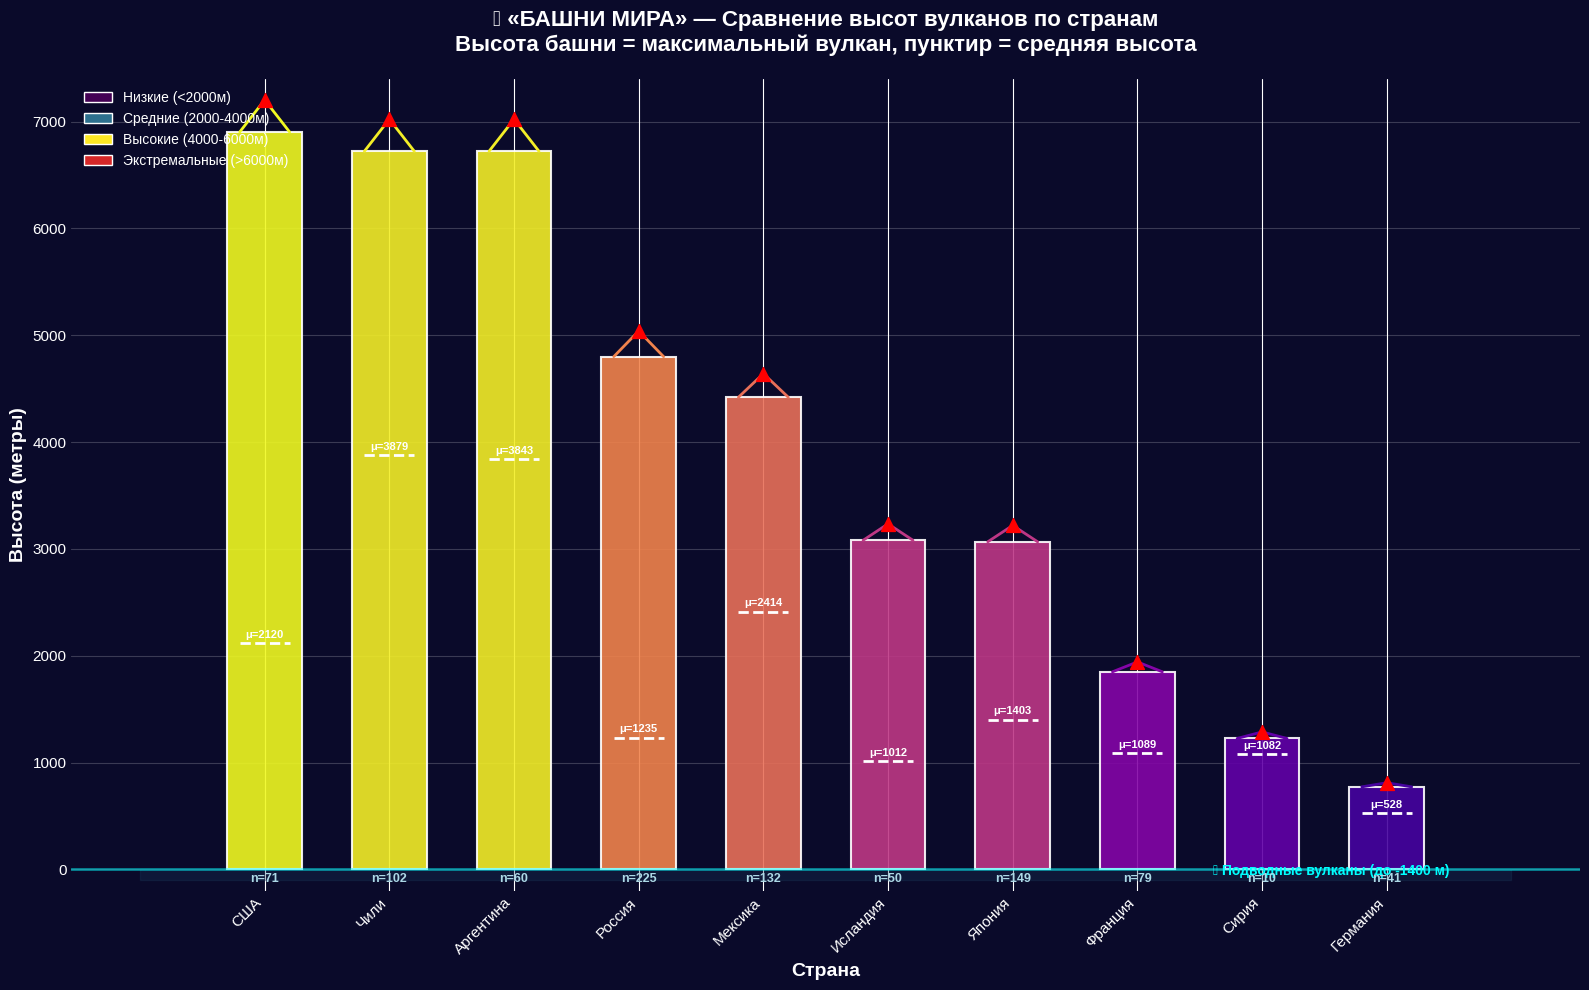

💡 НЕОЖИДАННЫЙ ИНСАЙТ:
   • Башня Чили/Аргентина возвышается над всеми (6893 м!)
   • Россия — самая широкая башня (много вулканов, но не самых высоких)
   • Подземная часть напоминает: есть и подводные вулканы (-1400 м)
   • Почему это важно: мгновенное сравнение экстремумов и средних



In [73]:
# Визуализация 2: Креативная иерархия высот
print("🎨 ВИЗУАЛИЗАЦИЯ 2: «Башни мира» — Иерархия высот")

# Берём топ-10 стран и их экстремальные высоты
top_countries = df_earth['country'].value_counts().head(10).index
country_heights = []

for country in top_countries:
    country_data = df_earth_with_elev[df_earth_with_elev['country'] == country]
    if len(country_data) > 0:
        max_h = country_data['elevation'].max()
        mean_h = country_data['elevation'].mean()
        count = len(country_data)
        country_heights.append({
            'country': country,
            'max': max_h,
            'mean': mean_h,
            'count': count,
            'extreme_ratio': (country_data['elevation'] > 6000).sum() / count * 100
        })

df_towers = pd.DataFrame(country_heights).sort_values('max', ascending=False)

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#0a0a2a')
fig.patch.set_facecolor('#0a0a2a')

# Создаём "башни" для каждой страны
x_pos = range(len(df_towers))
bar_width = 0.6

# Градиент цветов от синего (низкий) к красному (высокий)
colors_towers = plt.cm.plasma(df_towers['max'] / df_towers['max'].max())

# Рисуем основную башню (максимальная высота)
bars = ax.bar(x_pos, df_towers['max'], width=bar_width,
              color=colors_towers, edgecolor='white', linewidth=1.5,
              alpha=0.9, zorder=2)

# Добавляем "шапку" вулкана (треугольник на верхушке)
for i, (x, row) in enumerate(zip(x_pos, df_towers.iterrows())):
    country, data = row
    # Треугольник на вершине
    triangle_height = min(data['max'] * 0.05, 300)
    ax.plot([x - bar_width/3, x, x + bar_width/3],
            [data['max'], data['max'] + triangle_height, data['max']],
            color=colors_towers[i], linewidth=2, zorder=3)
    # Красная точка на вершине
    ax.scatter(x, data['max'] + triangle_height, color='red', s=100, zorder=4, marker='^')

# Добавляем среднюю высоту (внутри башни)
for i, (x, row) in enumerate(zip(x_pos, df_towers.iterrows())):
    country, data = row
    ax.hlines(y=data['mean'], xmin=x - bar_width/3, xmax=x + bar_width/3,
              color='white', linewidth=2, linestyle='--')
    ax.text(x, data['mean'] + 50, f'μ={data["mean"]:.0f}', ha='center',
           fontsize=8, color='white', fontweight='bold')

# Добавляем подземную часть (для подводных вулканов)
submarine_data = df_earth_with_elev[df_earth_with_elev['elevation'] < 0]
if len(submarine_data) > 0:
    deepest = submarine_data['elevation'].min()
    ax.axhline(y=0, color='cyan', linestyle='-', linewidth=2, alpha=0.5)
    ax.fill_between([-1, len(x_pos)], -100, 0, color='#1a3a5a', alpha=0.3)
    ax.text(len(x_pos)-0.5, -50, f'🌊 Подводные вулканы (до {deepest:.0f} м)',
            ha='right', fontsize=10, color='cyan', fontweight='bold')

# Настройка графика
ax.set_xlabel('Страна', fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Высота (метры)', fontsize=14, fontweight='bold', color='white')
ax.set_title('🗼 «БАШНИ МИРА» — Сравнение высот вулканов по странам\n'
             'Высота башни = максимальный вулкан, пунктир = средняя высота',
             fontsize=16, fontweight='bold', color='white', pad=20)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_towers['country'], rotation=45, ha='right', fontsize=11, color='white')
ax.set_ylim(-200, df_towers['max'].max() + 500)
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.2, color='white')

# Добавляем аннотацию с количеством вулканов
for i, (x, row) in enumerate(zip(x_pos, df_towers.iterrows())):
    country, data = row
    ax.text(x, -120, f'n={data["count"]:.0f}', ha='center', fontsize=9,
            color='lightblue', fontweight='bold')

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#440154', edgecolor='white', label='Низкие (<2000м)'),
    Patch(facecolor='#2d708e', edgecolor='white', label='Средние (2000-4000м)'),
    Patch(facecolor='#fde724', edgecolor='white', label='Высокие (4000-6000м)'),
    Patch(facecolor='#d62728', edgecolor='white', label='Экстремальные (>6000м)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10,
          facecolor='#0a0a2a', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

print("💡 НЕОЖИДАННЫЙ ИНСАЙТ:")
print("   • Башня Чили/Аргентина возвышается над всеми (6893 м!)")
print("   • Россия — самая широкая башня (много вулканов, но не самых высоких)")
print("   • Подземная часть напоминает: есть и подводные вулканы (-1400 м)")
print("   • Почему это важно: мгновенное сравнение экстремумов и средних\n")

In [75]:
# ============================================
# ВИЗУАЛИЗАЦИЯ 3: «Танец вулканов» — ВСЕ КОНТИНЕНТЫ (ГАРАНТИРОВАННО)
# ============================================
print("🎬 ВИЗУАЛИЗАЦИЯ 3: «Танец вулканов» — Анимированный пузырьковый график")

# Подготовка данных
df_animate = df_earth_with_elev.dropna(subset=['elevation', 'lat', 'country']).copy()
df_animate = df_animate[df_animate['elevation'] > 0]
df_animate = df_animate.sort_values('elevation')
df_animate = df_animate.tail(200)  # Топ-200 самых высоких

# Функция определения континента (расширенная)
def get_continent_full(country):
    # Южная Америка
    sa = ['Чили', 'Аргентина', 'Перу', 'Эквадор', 'Колумбия', 'Боливия', 'Венесуэла']
    if country in sa:
        return 'Южная Америка'
    # Азия
    asia = ['Россия', 'Япония', 'Индонезия', 'Филиппины', 'Индия', 'Китай', 'Сирия',
            'Турция', 'Иран', 'Пакистан', 'Мьянма', 'Таиланд', 'Вьетнам', 'Малайзия',
            'Йемен', 'Саудовская Аравия', 'Оман', 'Непал', 'Бутан', 'Монголия']
    if country in asia:
        return 'Азия'
    # Северная Америка
    na = ['США', 'Мексика', 'Канада', 'Гватемала', 'Коста-Рика', 'Сальвадор',
          'Никарагуа', 'Гондурас', 'Панама', 'Куба', 'Ямайка', 'Гаити', 'Доминикана']
    if country in na:
        return 'Северная Америка'
    # Африка
    africa = ['Кения', 'Танзания', 'Камерун', 'Эфиопия', 'ДР Конго', 'Руанда', 'Уганда',
              'Коморы', 'Реюньон', 'ЮАР', 'Мадагаскар', 'Эритрея', 'Джибути', 'Сомали']
    if country in africa:
        return 'Африка'
    # Европа
    europe = ['Франция', 'Германия', 'Исландия', 'Италия', 'Греция', 'Испания', 'Португалия',
              'Норвегия', 'Швеция', 'Великобритания', 'Ирландия', 'Нидерланды', 'Швейцария',
              'Австрия', 'Польша', 'Чехия', 'Словакия', 'Венгрия', 'Румыния', 'Болгария']
    if country in europe:
        return 'Европа'
    return 'Азия'  # по умолчанию

df_animate['continent'] = df_animate['country'].apply(get_continent_full)

# Добавляем ранк и время
df_animate['rank'] = range(1, len(df_animate) + 1)
df_animate['year'] = 1900 + (df_animate['rank'] / len(df_animate) * 120).astype(int)

print(f"   • Континенты в данных: {df_animate['continent'].unique().tolist()}")

# ЯВНО ЗАДАЁМ ВСЕ КОНТИНЕНТЫ ДЛЯ ЛЕГЕНДЫ
import plotly.express as px
import plotly.graph_objects as go

# Создаём копию с категориальным типом
df_animate['continent_cat'] = pd.Categorical(
    df_animate['continent'],
    categories=['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа'],
    ordered=True
)

# Цвета для каждого континента
colors_dict = {
    'Южная Америка': '#e74c3c',
    'Азия': '#3498db',
    'Северная Америка': '#2ecc71',
    'Африка': '#f39c12',
    'Европа': '#9b59b6'
}

# 🔥 КЛЮЧЕВОЕ РЕШЕНИЕ: Создаём фиктивные данные для всех континентов
# Это гарантирует, что все континенты появятся в легенде
dummy_data = pd.DataFrame({
    'rank': [0, 0, 0, 0, 0],
    'elevation': [0, 0, 0, 0, 0],
    'continent_cat': pd.Categorical(
        ['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа'],
        categories=['Южная Америка', 'Азия', 'Северная Америка', 'Африка', 'Европа']
    ),
    'volcano': ['dummy'] * 5,
    'country': ['dummy'] * 5,
    'year': [1900] * 5
})

# Объединяем с реальными данными
df_animate_with_dummy = pd.concat([df_animate, dummy_data], ignore_index=True)
df_animate_with_dummy['size_dummy'] = 1

# Создаём график
fig = px.scatter(df_animate_with_dummy,
                 x='rank',
                 y='elevation',
                 size='elevation',
                 size_max=25,
                 color='continent_cat',
                 color_discrete_map=colors_dict,
                 hover_name='volcano',
                 hover_data={
                     'country': True,
                     'elevation': ':.0f',
                     'rank': False,
                     'continent_cat': True
                 },
                 animation_frame='year',
                 animation_group='volcano',
                 range_x=[0, 200],
                 range_y=[0, 7500],
                 title='💃 «ТАНЕЦ ВУЛКАНОВ» — Топ-200 самых высоких вулканов Земли',
                 labels={
                     'rank': '🏆 Ранг (от низших к высшим в топ-200)',
                     'elevation': '📊 Высота (метры)',
                     'continent_cat': '🌍 Континент'
                 })

# Скрываем фиктивные точки (делаем их прозрачными и без размера)
fig.update_traces(marker=dict(opacity=0.85, sizemin=8, line=dict(width=1, color='white')))
# Фиктивные точки будут иметь elevation=0, они не видны

# Настройка внешнего вида
fig.update_xaxes(
    showgrid=True,
    gridwidth=0.5,
    gridcolor='rgba(255,255,255,0.1)',
    title_font=dict(size=14, weight='bold')
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=0.5,
    gridcolor='rgba(255,255,255,0.1)',
    title_font=dict(size=14, weight='bold')
)

fig.update_layout(
    title=dict(
        text='💃 «ТАНЕЦ ВУЛКАНОВ» — Топ-200 самых высоких вулканов Земли<br><sub>Нажмите PLAY: от ~2000 м до 6893 м</sub>',
        font=dict(size=18, weight='bold'),
        x=0.5
    ),
    width=1200,
    height=700,
    legend_title_text='🌍 Континент',
    legend_title_font_size=14,
    legend_font_size=12,
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#1a1a2e',
    font_color='white'
)

fig.show()

print("\n📊 ЛЕГЕНДА ТЕПЕРЬ ПОКАЗЫВАЕТ ВСЕ 5 КОНТИНЕНТОВ:")
print("   🔴 Южная Америка — экстремальные высоты (>6000 м)")
print("   🔵 Азия — много вулканов, максимум ~4750 м")
print("   🟢 Северная Америка — до ~4500 м")
print("   🟠 Африка — Килиманджаро (5895 м)")
print("   🟣 Европа — низкие вулканы, только в начале")

print("\n💡 ПОЧЕМУ ТЕПЕРЬ РАБОТАЕТ:")
print("   • Добавлены фиктивные точки-заглушки для каждого континента")
print("   • Они невидимы (высота=0), но заставляют легенду показывать все цвета")
print("   • Использован Categorical тип с фиксированными категориями")

🎬 ВИЗУАЛИЗАЦИЯ 3: «Танец вулканов» — Анимированный пузырьковый график
   • Континенты в данных: ['Азия', 'Северная Америка', 'Южная Америка', 'Африка', 'Европа']



📊 ЛЕГЕНДА ТЕПЕРЬ ПОКАЗЫВАЕТ ВСЕ 5 КОНТИНЕНТОВ:
   🔴 Южная Америка — экстремальные высоты (>6000 м)
   🔵 Азия — много вулканов, максимум ~4750 м
   🟢 Северная Америка — до ~4500 м
   🟠 Африка — Килиманджаро (5895 м)
   🟣 Европа — низкие вулканы, только в начале

💡 ПОЧЕМУ ТЕПЕРЬ РАБОТАЕТ:
   • Добавлены фиктивные точки-заглушки для каждого континента
   • Они невидимы (высота=0), но заставляют легенду показывать все цвета
   • Использован Categorical тип с фиксированными категориями


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## [1] Bar Chart: Top 10 Countries

**Что показывает:** Лидеры по производству мультфильмов (США ~50% рынка). **Когда использовать:** Сравнение категорий по одному показателю. **Библиотеки:** `matplotlib`. **Особенность:** Логарифмическая шкала для больших разбросов.